# Comenzamos con la actividad 1 de la Guia 3:

In [ ]:
options(warn=-1)
install.packages("readxl")
library("readxl")
nombre_excel <- "/content/df_secundario_comun_depurado.xlsx" # Changed to direct path
datos_secundaria_comun <- read_excel(nombre_excel)
head(datos_secundaria_comun)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



CUE,suborganizacion,departamento,EsPrivada,anioLectivo,curso,Documento,Asignatura,NotaPrimerTrimestre,NotaSegundoTrimestre,NotaTercerTrimestre,NotaDiciembre,Promedio,Resultado
<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
6000934,ESCUELA SECUNDARIA N° 7 CARLOS L. VERGARA,DIAMANTE,N,2024,1ro Secundaria,24606779,BIOLOGIA,10,10,10,NA,10.000000,Aprobo
6000934,ESCUELA SECUNDARIA N° 7 CARLOS L. VERGARA,DIAMANTE,N,2024,1ro Secundaria,24606779,FISICA,10,10,10,NA,10.000000,Aprobo
6000934,ESCUELA SECUNDARIA N° 7 CARLOS L. VERGARA,DIAMANTE,N,2024,1ro Secundaria,24606779,LENGUAS EXTRANJERAS,9,10,8,NA,9.000000,Aprobo
6000934,ESCUELA SECUNDARIA N° 7 CARLOS L. VERGARA,DIAMANTE,N,2024,1ro Secundaria,24606779,QUIMICA,9,10,10,NA,9.666667,Aprobo
6000934,ESCUELA SECUNDARIA N° 7 CARLOS L. VERGARA,DIAMANTE,N,2024,1ro Secundaria,24606779,LENGUA Y LITERATURA,8,10,10,NA,9.333333,Aprobo
6000934,ESCUELA SECUNDARIA N° 7 CARLOS L. VERGARA,DIAMANTE,N,2024,1ro Secundaria,24606779,GEOGRAFIA,6,7,10,NA,7.666667,Aprobo


Preguntas generales del Dataset:

In [ ]:
# ¿Cuántas observaciones y variables tiene el dataset?

# Número de observaciones
num_observaciones <- nrow(datos_secundaria_comun)

# Número de variables
num_variables <- ncol(datos_secundaria_comun)

print(paste("Número de observaciones:", num_observaciones))
print(paste("Número de variables:", num_variables))

[1] "Número de observaciones: 23618"
[1] "Número de variables: 14"


In [ ]:
# ¿Faltan datos en alguna columna?

# Calcula la cantidad de valores faltantes (NA) en cada columna
faltantes_por_columna <- colSums(is.na(datos_secundaria_comun))

print(faltantes_por_columna)

                 CUE      suborganizacion         departamento 
                   0                    0                    0 
           EsPrivada          anioLectivo                curso 
                   0                    0                    0 
           Documento           Asignatura  NotaPrimerTrimestre 
                   0                    0                    0 
NotaSegundoTrimestre  NotaTercerTrimestre        NotaDiciembre 
                   0                    0                21189 
            Promedio            Resultado 
                   0                    0 


In [ ]:
# Instalar dplyr si es necesario
if (!require(dplyr)) install.packages("dplyr")
library(dplyr)

# Contar alumnos únicos por DNI
total_alumnos <- n_distinct(datos_secundaria_comun$Documento)

# Imprimir el resultado
print(paste("Número total de alumnos:", total_alumnos))

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "Número total de alumnos: 2976"


In [ ]:
# Creamos las tablas de frecuencia para responder la preguntas de la actividad 2.
# empezamos filtrando las materias:

library(dplyr)
datos_matematicas <- datos_secundaria_comun %>%
  filter(Asignatura == "MATEMATICA")
datos_lengua <- datos_secundaria_comun %>%
  filter(Asignatura == "LENGUA Y LITERATURA")
datos_geografia <- datos_secundaria_comun %>%
  filter(Asignatura == "GEOGRAFIA")
datos_historia <- datos_secundaria_comun %>%
  filter(Asignatura == "HISTORIA")

In [ ]:
table(datos_geografia$curso)


1ro Secundaria 2do Secundaria 3ro Secundaria 4to Secundaria 5to Secundaria 
           578            535            497            494            408 
6to Secundaria 
           415 

In [ ]:
table(datos_historia$curso)


1ro Secundaria 2do Secundaria 3ro Secundaria 4to Secundaria 5to Secundaria 
           578            526            499            491            409 
6to Secundaria 
           416 

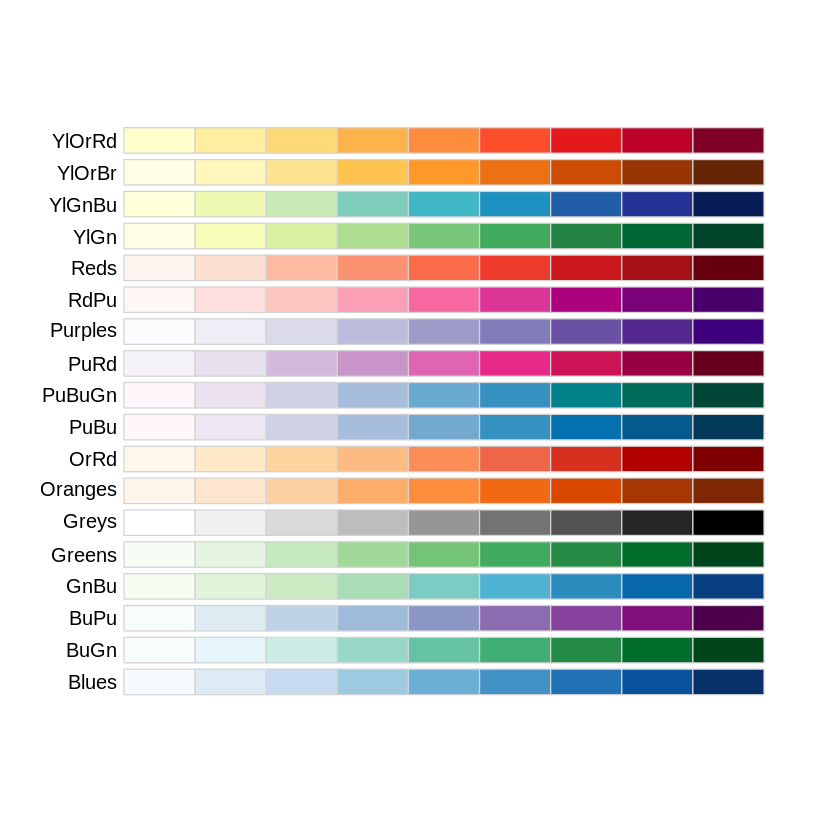

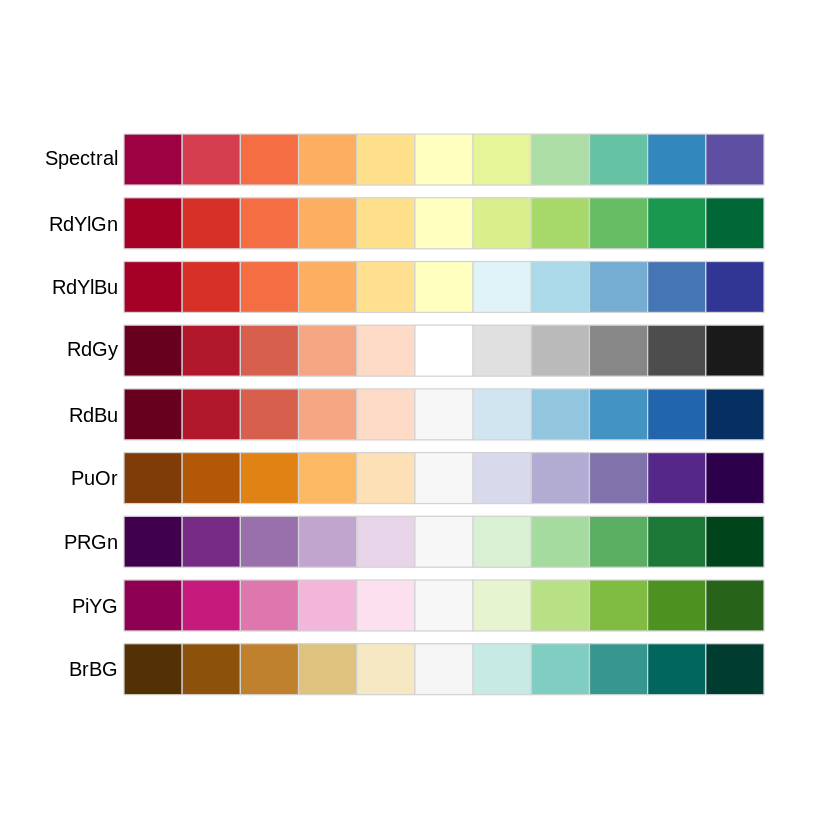

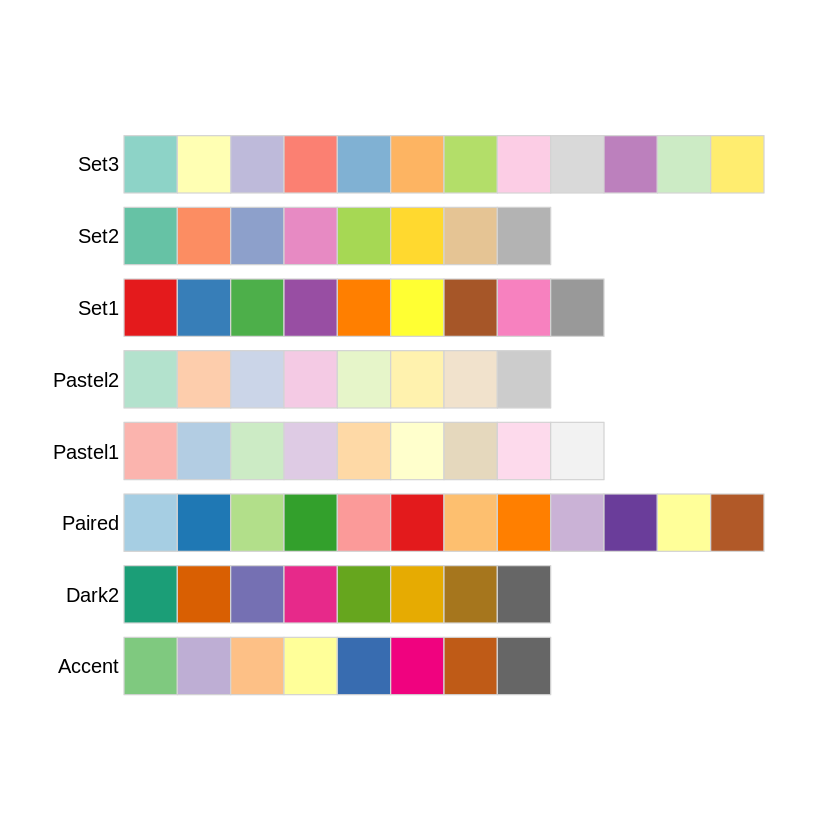

In [ ]:
#cargamos colores:

library(RColorBrewer)
display.brewer.all(type = "seq")  # Secuenciales
display.brewer.all(type = "div")  # Divergentes
display.brewer.all(type = "qual") # Cualitativas


Loading required package: ggplot2



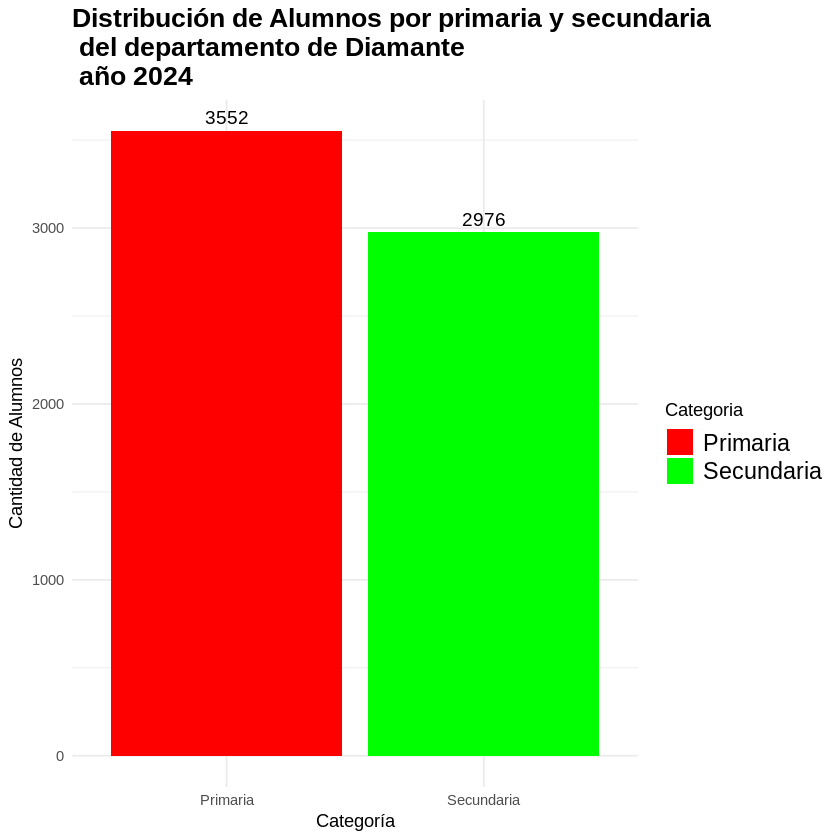

In [ ]:
# Pregunta 1 Como es la distribucion entre primaria y secundaria comun?:

if (!require(ggplot2)) install.packages("ggplot2")

library(ggplot2)
alumnos <- data.frame(
  Categoria = c("Primaria", "Secundaria"),
  Cantidad = c(3552, 2976)
)

alumnos$Porcentaje <- round(alumnos$Cantidad, 1)

mi_paleta <- c("#FF0000", "#00FF00", "#0000FF", "#FFFF00", "#FF00FF") # Rojo, verde, azul, amarillo, magenta

# Gráfico de barras con ggplot2
ggplot(alumnos, aes(x = Categoria, y = Cantidad, fill = Categoria)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label =(Porcentaje)),
            vjust = -0.5, size = 4, color = "black") + # Etiquetas de porcentaje
  scale_fill_manual(values = mi_paleta) + # Usar paleta de colores Pastel1
  labs(
    title = "Distribución de Alumnos por primaria y secundaria \n del departamento de Diamante \n año 2024",
    x = "Categoría",
    y = "Cantidad de Alumnos"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold"),
    legend.text = element_text(size = 14)
  )

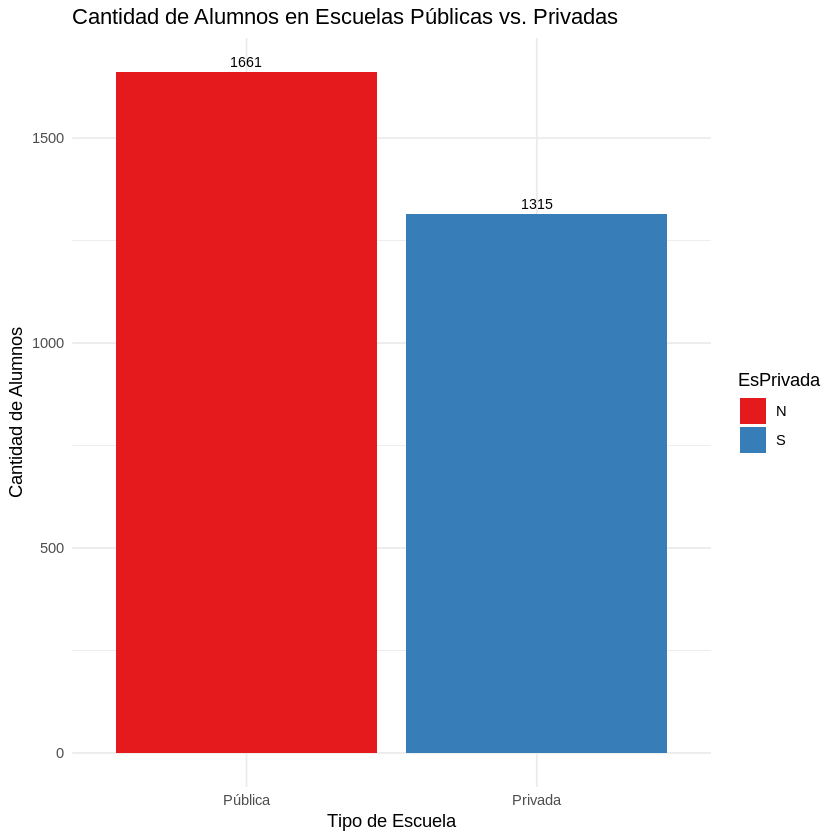

In [ ]:
# Saber cuantos alumnos va a la Escuela Privda y cuantos a la Publica:

library(dplyr)

# Filtrar por Documentos únicos y conservar EsPrivada
datos_filtrados <- datos_secundaria_comun %>%
  distinct(Documento, .keep_all = TRUE)

# Cargar librerías (si aún no lo has hecho)
library(ggplot2)

# Preparar los datos para el gráfico de barras
df_barras <- datos_filtrados %>%
  group_by(EsPrivada) %>%
  summarise(Cantidad = n())

# Crear el gráfico de barras
ggplot(df_barras, aes(x = EsPrivada, y = Cantidad, fill = EsPrivada)) +
  geom_col() +
  geom_text(aes(label = Cantidad), vjust = -0.5, size = 3) +  # Etiquetas con la cantidad
  labs(
    title = "Cantidad de Alumnos en Escuelas Públicas vs. Privadas",
    x = "Tipo de Escuela",
    y = "Cantidad de Alumnos"
  ) +
  theme_minimal() +
  scale_fill_brewer(palette = "Set1") + # Paleta de colores (opcional)
  scale_x_discrete(labels = c("N" = "Pública", "S" = "Privada"))

Loading required package: ggsci

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



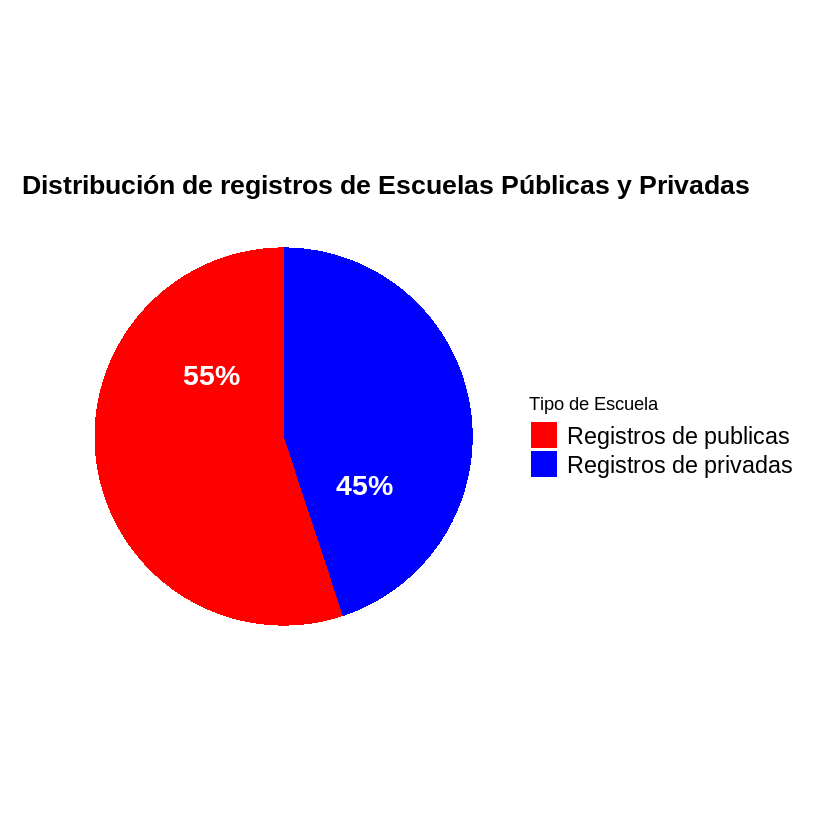

In [ ]:
# Pregunta: Cual es el porcentaje de registros en Sec. Privadas y Sec. Publicas? :

if(!require(ggplot2)){
  install.packages("ggplot2")
}
library(ggplot2)
if(!require(ggsci)){
  install.packages("ggsci")
}
library(ggsci)

# Calculamos el porcentage
df_pie <- datos_secundaria_comun %>%
  group_by(EsPrivada) %>%
  summarise(count = n()) %>%
  mutate(percentage = count / sum(count) * 100)

# Creamos el grafico
A2 <- ggplot(df_pie, aes(x = "", y = percentage, fill = EsPrivada)) +
  geom_bar(width = 1, stat = "identity") +
  coord_polar("y", start = 0) +
  geom_text(aes(label = paste0(round(percentage), "%")),
            position = position_stack(vjust = 0.75), size = 6, fontface = "bold", color = "white") +
   scale_fill_manual(values = c("red", "blue"),  # Use scale_fill_manual
                    labels = c("Registros de publicas", "Registros de privadas")) + # Custom labels
  labs(
    title = "Distribución de registros de Escuelas Públicas y Privadas",
    fill = "Tipo de Escuela",
    x = NULL, y = NULL
  ) +
  theme_void() +
  theme(
    plot.margin = unit(c(2,1,2,1), "cm"), # Comma added here
    plot.title = element_text(size = 16, face = "bold",hjust = 0.1),
    plot.subtitle = element_text(size = 14),
    legend.text = element_text(size = 14) # Aumenta el tamaño de los labels en la leyenda
  )

print(A2)

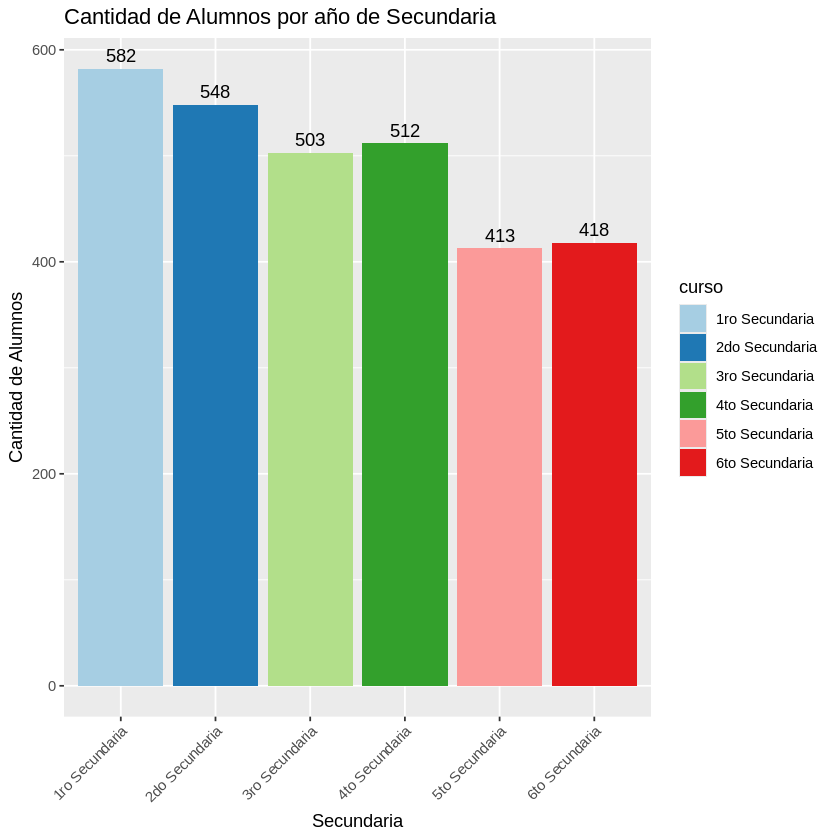

In [ ]:
# Pregunta 3 ¿Cómo se distribuye en su departamento la cantidad de estudiantes por año de cursado? ¿Cuál es el año con mayor matrícula? ¿Cuál es el año con menor matrícula?:

if(!require(ggplot2)){
  install.packages("ggplot2")
}
library(ggplot2)

# Agrupar por escuela y contar alumnos únicos (sin repeticiones de DNI)
df_grafico <- datos_secundaria_comun %>%
  group_by(curso) %>%
  summarise(cantidad_alumnos = n_distinct(Documento)) # Contar alumnos únicos por DNI

# Crear el gráfico de barras
ggplot(df_grafico, aes(x = curso, y = cantidad_alumnos, fill = curso)) + # Fill by curso
  geom_col() +
  geom_text(aes(label = cantidad_alumnos), vjust = -0.5) + # Add text labels
  labs(title = "Cantidad de Alumnos por año de Secundaria",
       x = "Secundaria",
       y = "Cantidad de Alumnos") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_fill_brewer(palette = "Paired") # Apply color palette

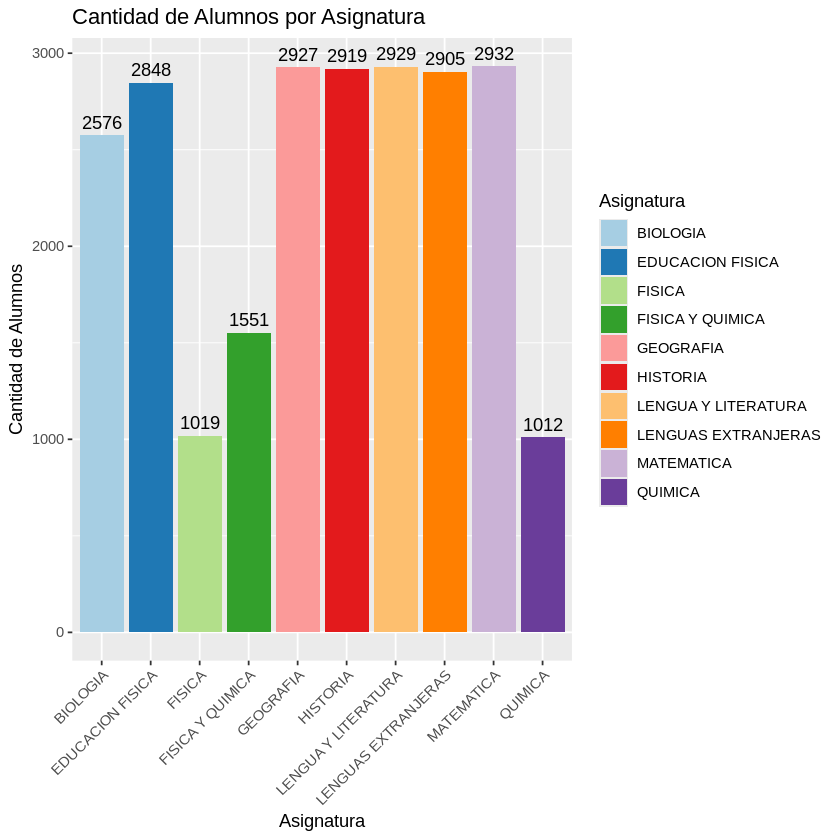

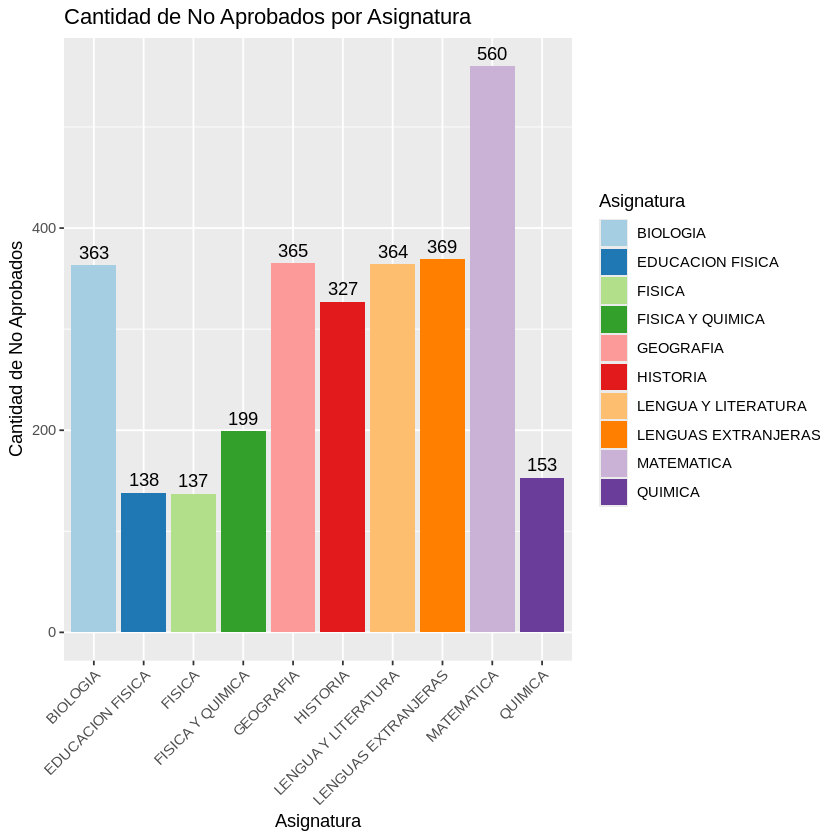

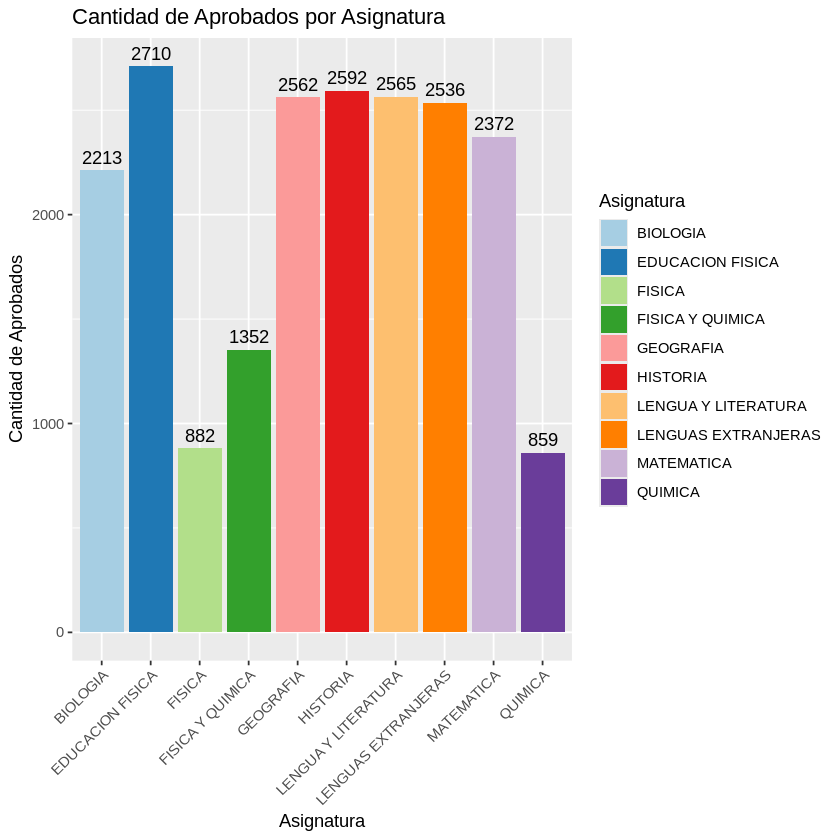

In [ ]:
# Pregunta 4 de la Actividad 1:
# ¿Cuál es la distribución del Resultado (Aprobado vs No Aprobado)? : Grafico de barras
#

if(!require(ggplot2)){
  install.packages("ggplot2")
}
library(ggplot2)

# Agrupar por escuela y contar alumnos únicos (sin repeticiones de DNI)
df_grafico <- datos_secundaria_comun %>%
  group_by(Asignatura) %>%
  summarise(cantidad_alumnos = n_distinct(Documento)) # Contar alumnos únicos por DNI

# Crear el gráfico de barras
ggplot(df_grafico, aes(x = Asignatura, y = cantidad_alumnos, fill = Asignatura)) + # Fill by division
  geom_col() +
  geom_text(aes(label = cantidad_alumnos), vjust = -0.5) + # Add text labels
  labs(title = "Cantidad de Alumnos por Asignatura",
       x = "Asignatura",
       y = "Cantidad de Alumnos") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_fill_brewer(palette = "Paired") # Apply color palette

# Grafico de alumnos por materia que No Aprobaron

no_aprobados_por_asignatura <- datos_secundaria_comun %>%
     filter(Resultado == "No aprobo") %>%  # Filtrar por no aprobados
     group_by(Asignatura) %>%
     summarise(cantidad = n())  # Contar no aprobados por asignatura

ggplot(no_aprobados_por_asignatura, aes(x = Asignatura, y = cantidad, fill = Asignatura)) +
     geom_col() +
     geom_text(aes(label = cantidad), vjust = -0.5) +
     labs(title = "Cantidad de No Aprobados por Asignatura",
         x = "Asignatura",
         y = "Cantidad de No Aprobados") +
     theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
     scale_fill_brewer(palette = "Paired")

# Grafico de alumnos que Aprobaron

aprobados_por_asignatura <- datos_secundaria_comun %>%
     filter(Resultado == "Aprobo") %>%  # Filtrar por aprobados
     group_by(Asignatura) %>%
     summarise(cantidad = n())  # Contar aprobados por asignatura

ggplot(aprobados_por_asignatura, aes(x = Asignatura, y = cantidad, fill = Asignatura)) +
     geom_col() +
     geom_text(aes(label = cantidad), vjust = -0.5) +
     labs(title = "Cantidad de Aprobados por Asignatura",
         x = "Asignatura",
         y = "Cantidad de Aprobados") +
     theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
     scale_fill_brewer(palette = "Paired")

# Ahora pasamos a la Actividad 2 de la Guia 3

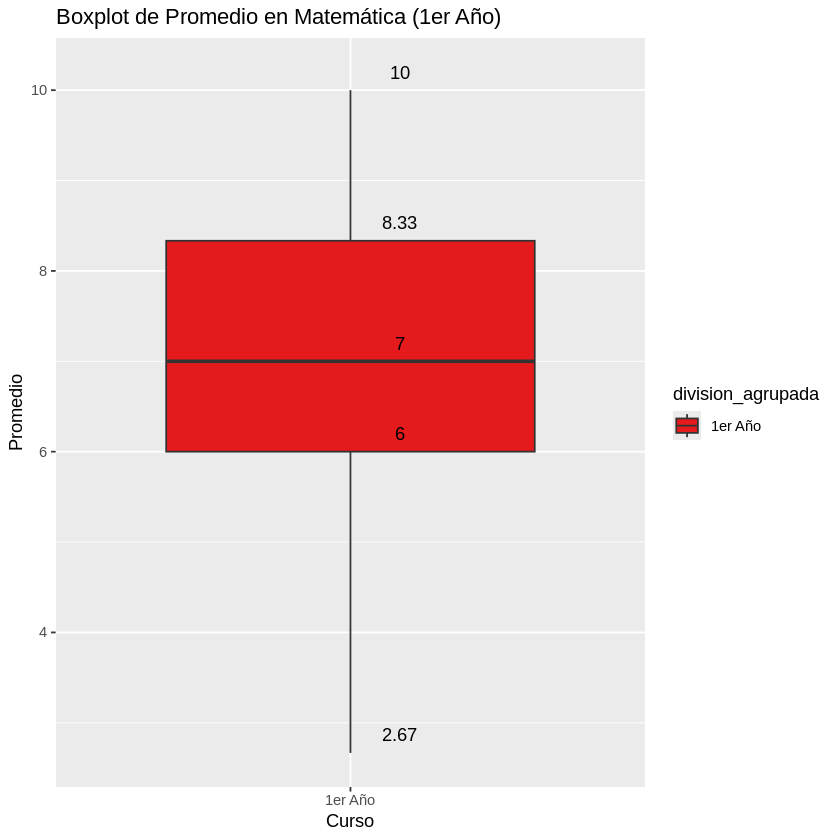

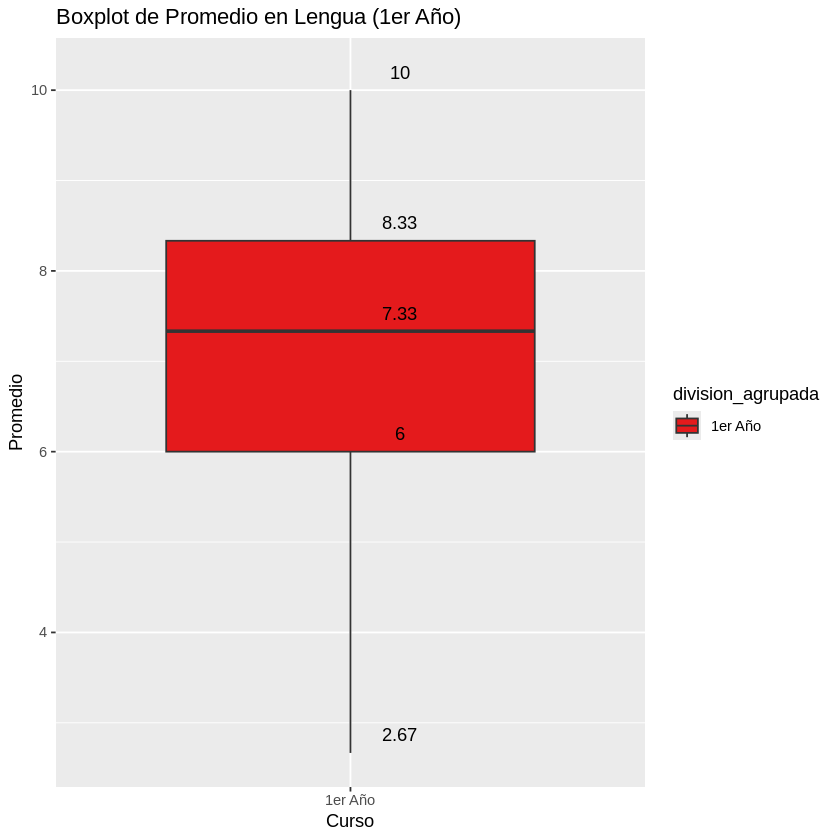

In [ ]:
# Respondemos la pregunta 1 de la Actividad 2 de la Guia 3:

# primero segmentamos las materias Matematicas y Lengua en 1er año:

library(dplyr)
library(ggplot2)

# Combinar divisiones en una nueva columna
datos_matematicas_1o <- datos_matematicas %>%
  filter(curso == "1ro Secundaria") %>%
  mutate(division_agrupada = "1er Año")

datos_lengua_1o <- datos_lengua %>%
  filter(curso == "1ro Secundaria") %>%
  mutate(division_agrupada = "1er Año")

# Crear los boxplots con modificaciones
plot_matematica <- ggplot(datos_matematicas_1o, aes(x = division_agrupada, y = Promedio, fill = division_agrupada)) +
  geom_boxplot() +  # Quitamos notch = TRUE para eliminar las muescas
  # Quitamos geom_jitter() para eliminar los puntos
  scale_fill_brewer(palette = "Set1") +  # Usar paleta de colores "Set1"
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),  # Agregar etiquetas con dos decimales
               position = position_nudge(x = 0.1, y = 0.2)) +  # Ajustar posición de etiquetas
  labs(title = "Boxplot de Promedio en Matemática (1er Año)",
       x = "Curso",
       y = "Promedio")

plot_lengua <- ggplot(datos_lengua_1o, aes(x = division_agrupada, y = Promedio, fill = division_agrupada)) +
  geom_boxplot() +  # Quitamos notch = TRUE para eliminar las muescas
  # Quitamos geom_jitter() para eliminar los puntos
  scale_fill_brewer(palette = "Set1") +  # Usar paleta de colores "Set1"
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),  # Agregar etiquetas con dos decimales
               position = position_nudge(x = 0.1, y = 0.2)) +  # Ajustar posición de etiquetas
  labs(title = "Boxplot de Promedio en Lengua (1er Año)",
       x = "Curso",
       y = "Promedio")

print(plot_matematica)
print(plot_lengua)

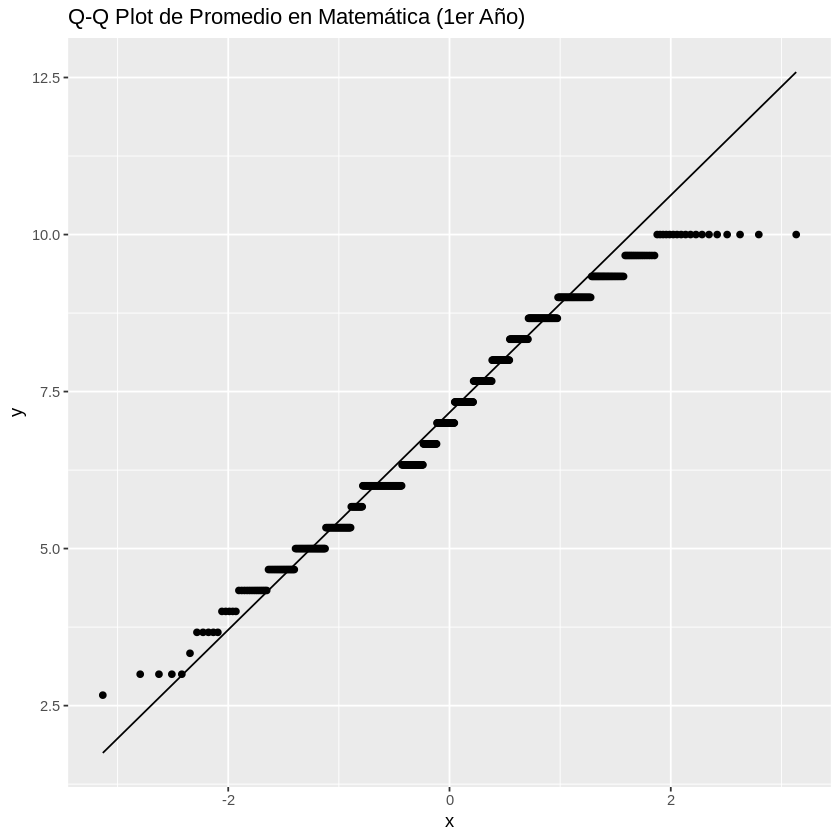

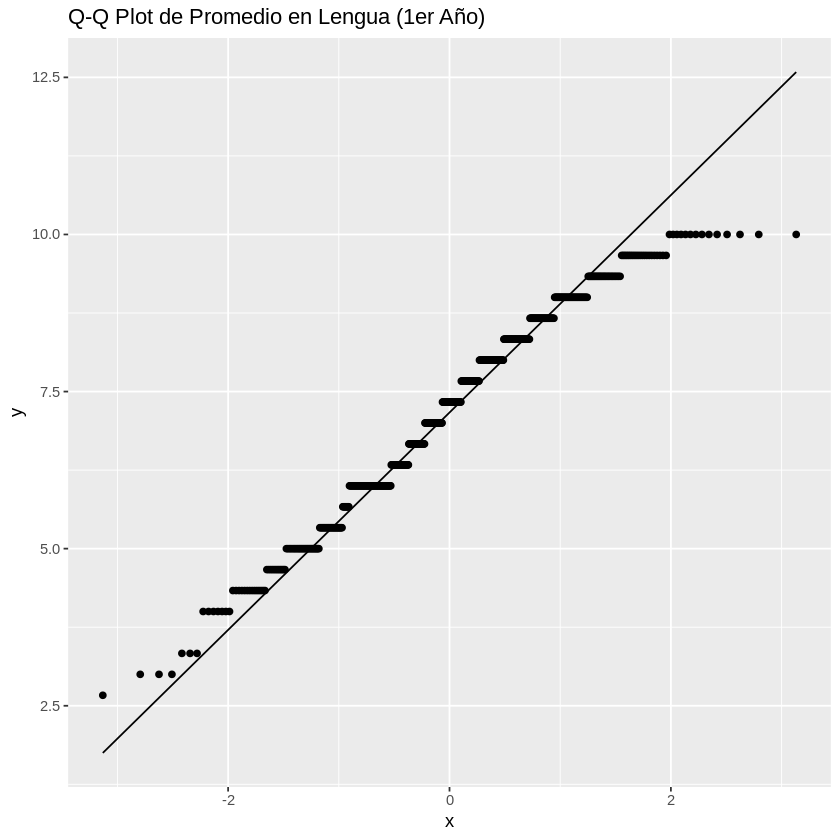

In [ ]:
# Respondemos la Actividad 2 de la Guia 3:¿La distribución es simétrica? Si es asimétrica, ¿la asimetría es a derecha o a izquierda? ¿Qué quiere decir eso?

if(!require(ggplot2)){
  install.packages("ggplot2")
}
library(ggplot2)

# Combinar divisiones en una nueva columna
datos_matematicas_1er <- datos_matematicas %>%
  filter(curso == "1ro Secundaria") %>%
  mutate(division_agrupada = "1er Año")

# Crear el gráfico Q-Q plot Matematica
ggplot(datos_matematicas_1er, aes(sample = Promedio)) +
  stat_qq() +
  stat_qq_line() +
  labs(title = "Q-Q Plot de Promedio en Matemática (1er Año)")

# Combinar divisiones en una nueva columna
datos_lengua_1er <- datos_lengua %>%
  filter(curso == "1ro Secundaria") %>%
  mutate(division_agrupada = "1er Año")

# Crear el gráfico Q-Q plot Lengua
ggplot(datos_lengua_1er, aes(sample = Promedio)) +
  stat_qq() +
  stat_qq_line() +
  labs(title = "Q-Q Plot de Promedio en Lengua (1er Año)")

In [ ]:
# Respondemos la Actividad 2 de la Guia 3 (Continuacion):

# Filtrar los datos de Matemática de 1er año
datos_matematicas_1ero <- datos_matematicas %>%
  filter(curso == "1ro Secundaria" )

# Realizar el test de Shapiro-Wilk
shapiro.test(datos_matematicas_1ero$Promedio)

# Filtrar los datos de Matemática de 1er año
datos_lengua_1ero <- datos_lengua %>%
  filter(curso == "1ro Secundaria")

# Realizar el test de Shapiro-Wilk
shapiro.test(datos_lengua_1ero$Promedio)


	Shapiro-Wilk normality test

data:  datos_matematicas_1ero$Promedio
W = 0.97763, p-value = 9.769e-08



	Shapiro-Wilk normality test

data:  datos_lengua_1ero$Promedio
W = 0.9761, p-value = 4.374e-08


In [ ]:
install.packages("nortest")
library(nortest)


# Estandarizar la variable "Promedio" en Matemática de 1er año
datos_matematicas_1ero$Promedio_Estandarizado <- scale(datos_matematicas_1ero$Promedio)

# Estandarizar la variable "Promedio" en Lengua de 1er año
datos_lengua_1ero$Promedio_Estandarizado <- scale(datos_lengua_1ero$Promedio)

# Test de Lilliefors para Promedio Estandarizado en Matemática
lillie.test(datos_matematicas_1ero$Promedio_Estandarizado)

# Test de Lilliefors para Promedio Estandarizado en Lengua
lillie.test(datos_lengua_1ero$Promedio_Estandarizado)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




	Lilliefors (Kolmogorov-Smirnov) normality test

data:  datos_matematicas_1ero$Promedio_Estandarizado
D = 0.082231, p-value = 5.357e-10



	Lilliefors (Kolmogorov-Smirnov) normality test

data:  datos_lengua_1ero$Promedio_Estandarizado
D = 0.090213, p-value = 4.31e-12


# Pasamos a la Actividad 3 de la Guia 3: 1er año Matematica y Lengua

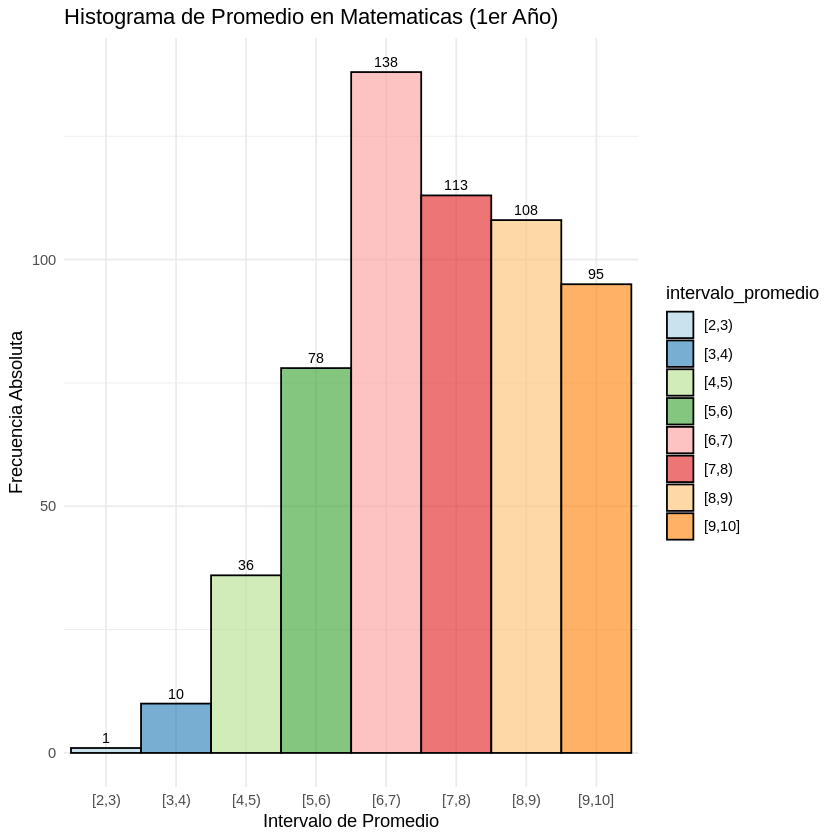

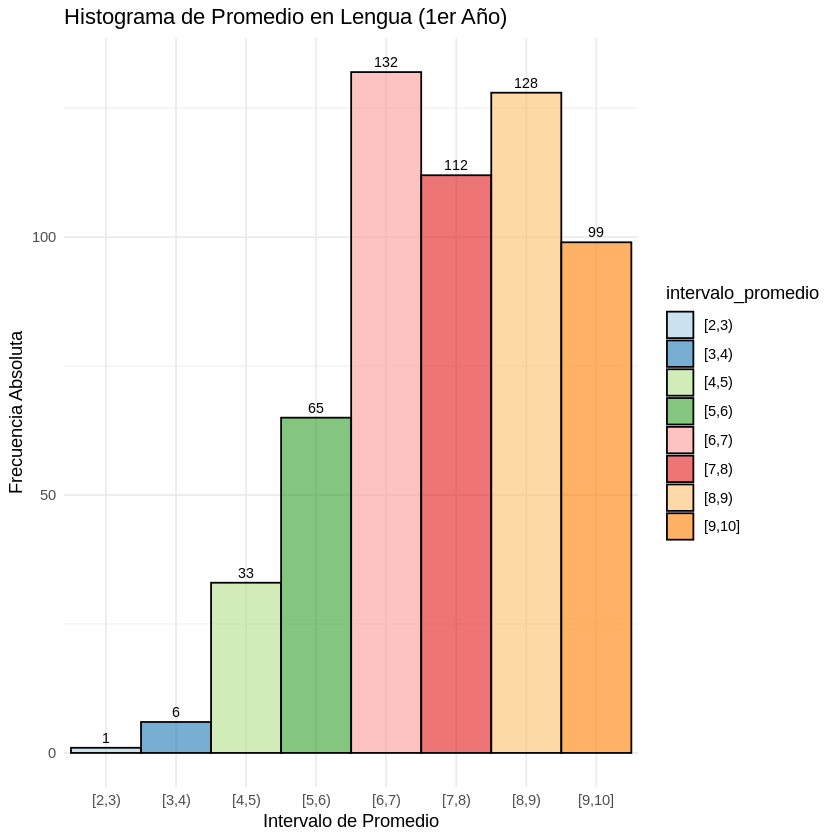

In [ ]:
# Respondemos la pregunta 1 de la Actividad 3 de la Guia 3: ¿Cuáles son las notas más frecuentes? ¿Y las menos frecuentes?

# primero segmentamos las materias Matematicas y Lengua en 1er año:

library(dplyr)
library(ggplot2)

# Combinar divisiones en una nueva columna
datos_matematicas_1o <- datos_matematicas %>%
  filter(curso == "1ro Secundaria") %>%
  mutate(division_agrupada = "1er Año")

datos_lengua_1o <- datos_lengua %>%
  filter(curso == "1ro Secundaria") %>%
  mutate(division_agrupada = "1er Año")

# Creamos la tabla de frecuencia con sus intervalos

# Definir los intervalos (bins)
breaks <- seq(1, 10, by = 1) # Intervalos de 1 en 1 desde 1 hasta 10

# Crear una nueva columna con los intervalos
datos_matematicas33 <- datos_matematicas_1o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

datos_lengua33 <- datos_lengua_1o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

# Crear tabla de frecuencias por intervalos (sin agrupar por division)
tabla_frecuencias_mates <- datos_matematicas33 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

tabla_frecuencias_lengua <- datos_lengua33 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

# Creamos los Histogramas

ggplot(tabla_frecuencias_mates, aes(x = intervalo_promedio, y = Frecuencia_Absoluta, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Matematicas (1er Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

ggplot(tabla_frecuencias_lengua, aes(x = intervalo_promedio, y = Frecuencia_Absoluta, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Lengua (1er Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

In [ ]:
table(datos_matematicas_1o$suborganizacion)


                      ESCUELA SECUNDARIA N 11 
                                           16 
      ESCUELA SECUNDARIA N 12 LOS INMIGRANTES 
                                            8 
ESCUELA SECUNDARIA N 8 PTE NICOLAS AVELLANEDA 
                                           23 
    ESCUELA SECUNDARIA N° 1 CARLOS PELLEGRINI 
                                            6 
                     ESCUELA SECUNDARIA N° 10 
                                           37 
                     ESCUELA SECUNDARIA N° 13 
                                           10 
                     ESCUELA SECUNDARIA N° 15 
                                           53 
                      ESCUELA SECUNDARIA N° 3 
                                           14 
                      ESCUELA SECUNDARIA N° 4 
                                           62 
    ESCUELA SECUNDARIA N° 7 CARLOS L. VERGARA 
                                           92 
                      ESCUELA SECUNDARIA N° 9 
            

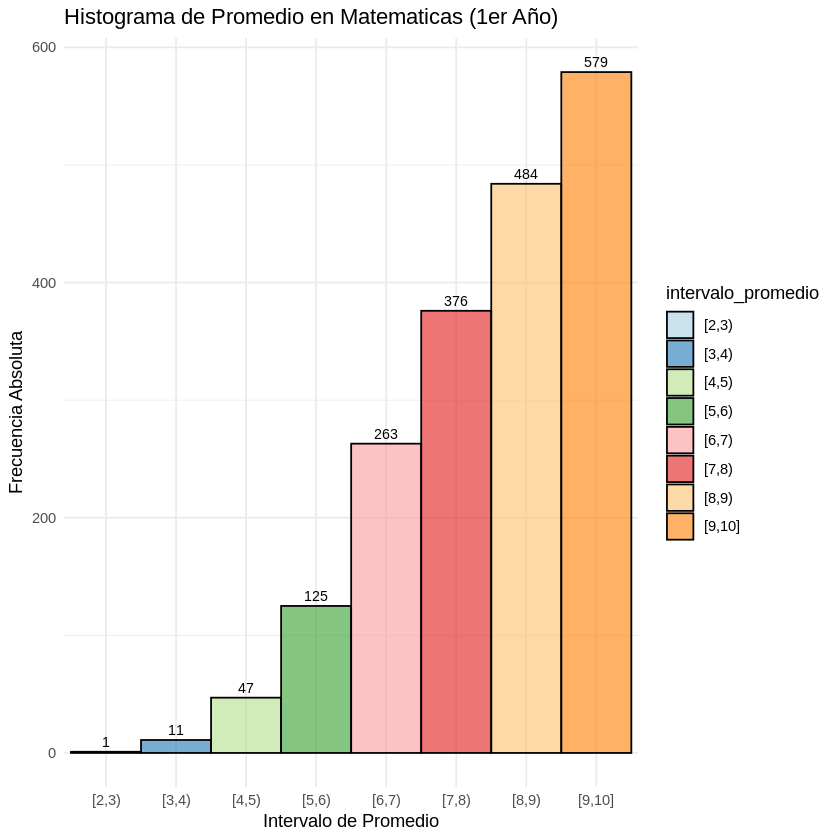

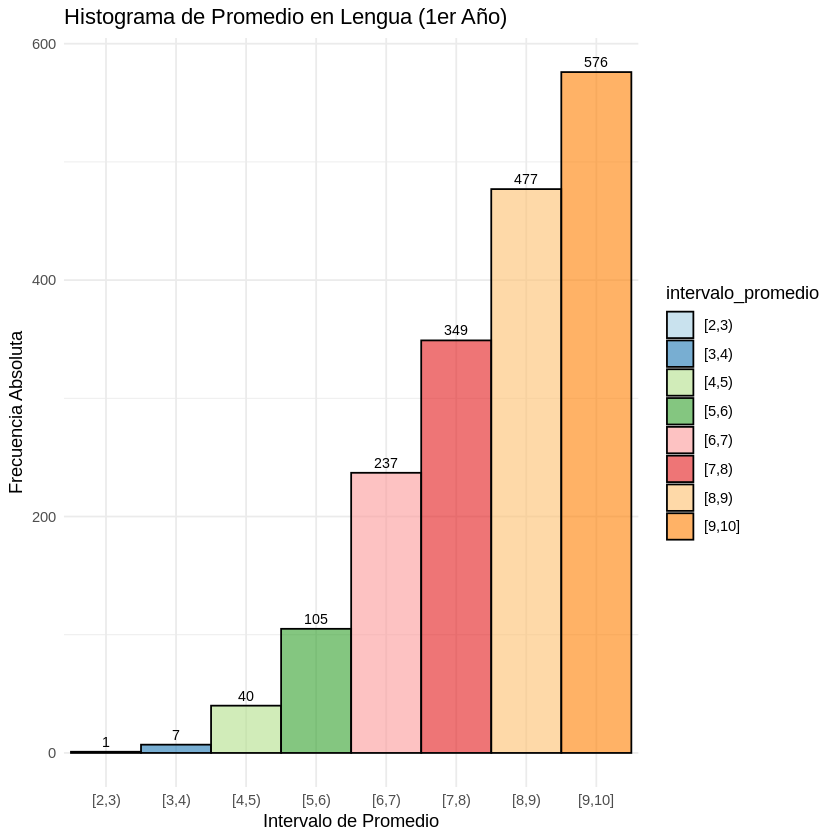

In [ ]:
# Histograma de frecuencia Acumuladas

# primero segmentamos las materias Matematicas y Lengua en 1er año:

library(dplyr)
library(ggplot2)

# Combinar divisiones en una nueva columna
datos_matematicas_1o <- datos_matematicas %>%
  filter(curso == "1ro Secundaria") %>%
  mutate(division_agrupada = "1er Año")

datos_lengua_1o <- datos_lengua %>%
  filter(curso == "1ro Secundaria") %>%
  mutate(division_agrupada = "1er Año")

# Creamos la tabla de frecuencia con sus intervalos

# Definir los intervalos (bins)
breaks <- seq(1, 10, by = 1) # Intervalos de 1 en 1 desde 1 hasta 10

# Crear una nueva columna con los intervalos
datos_matematicas33 <- datos_matematicas_1o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

datos_lengua33 <- datos_lengua_1o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

# Crear tabla de frecuencias por intervalos (sin agrupar por division)
tabla_frecuencias_mates <- datos_matematicas33 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

tabla_frecuencias_lengua <- datos_lengua33 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

# Creamos los Histogramas

ggplot(tabla_frecuencias_mates, aes(x = intervalo_promedio, y = Frecuencia_Absoluta_Acumulada, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta_Acumulada), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Matematicas (1er Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

ggplot(tabla_frecuencias_lengua, aes(x = intervalo_promedio, y = Frecuencia_Absoluta_Acumulada, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta_Acumulada), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Lengua (1er Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

# Extendemos el analisis de estas variables en los demas años.

### 2do Año de Matematicas y Lengua:

In [ ]:
# primero segmentamos las materias Matematicas y Lengua en 2do año:

library(dplyr)
library(ggplot2)

# Combinar divisiones en una nueva columna
datos_matematicas_2o <- datos_matematicas %>%
  filter(curso == "2do Secundaria") %>%
  mutate(division_agrupada = "2do Año")

datos_lengua_2o <- datos_lengua %>%
  filter(curso == "2do Secundaria") %>%
  mutate(division_agrupada = "2do Año")

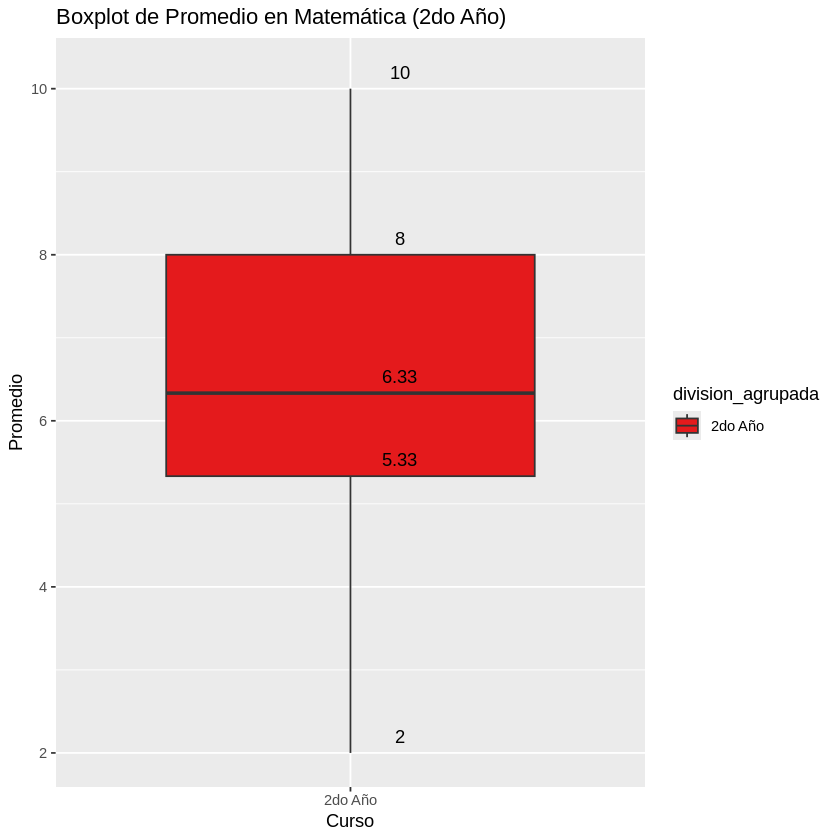

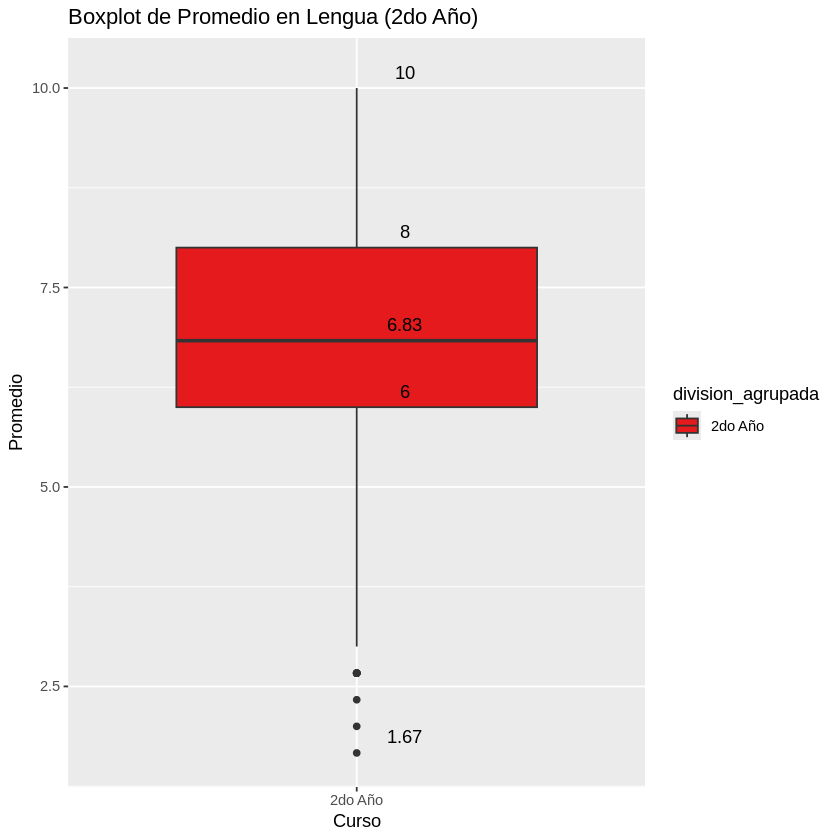

In [ ]:
# Crear los boxplots con modificaciones
plot_matematica2 <- ggplot(datos_matematicas_2o, aes(x = division_agrupada, y = Promedio, fill = division_agrupada)) +
  geom_boxplot() +  # Quitamos notch = TRUE para eliminar las muescas
  # Quitamos geom_jitter() para eliminar los puntos
  scale_fill_brewer(palette = "Set1") +  # Usar paleta de colores "Set1"
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),  # Agregar etiquetas con dos decimales
               position = position_nudge(x = 0.1, y = 0.2)) +  # Ajustar posición de etiquetas
  labs(title = "Boxplot de Promedio en Matemática (2do Año)",
       x = "Curso",
       y = "Promedio")

plot_lengua2 <- ggplot(datos_lengua_2o, aes(x = division_agrupada, y = Promedio, fill = division_agrupada)) +
  geom_boxplot() +  # Quitamos notch = TRUE para eliminar las muescas
  # Quitamos geom_jitter() para eliminar los puntos
  scale_fill_brewer(palette = "Set1") +  # Usar paleta de colores "Set1"
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),  # Agregar etiquetas con dos decimales
               position = position_nudge(x = 0.1, y = 0.2)) +  # Ajustar posición de etiquetas
  labs(title = "Boxplot de Promedio en Lengua (2do Año)",
       x = "Curso",
       y = "Promedio")

print(plot_matematica2)
print(plot_lengua2)

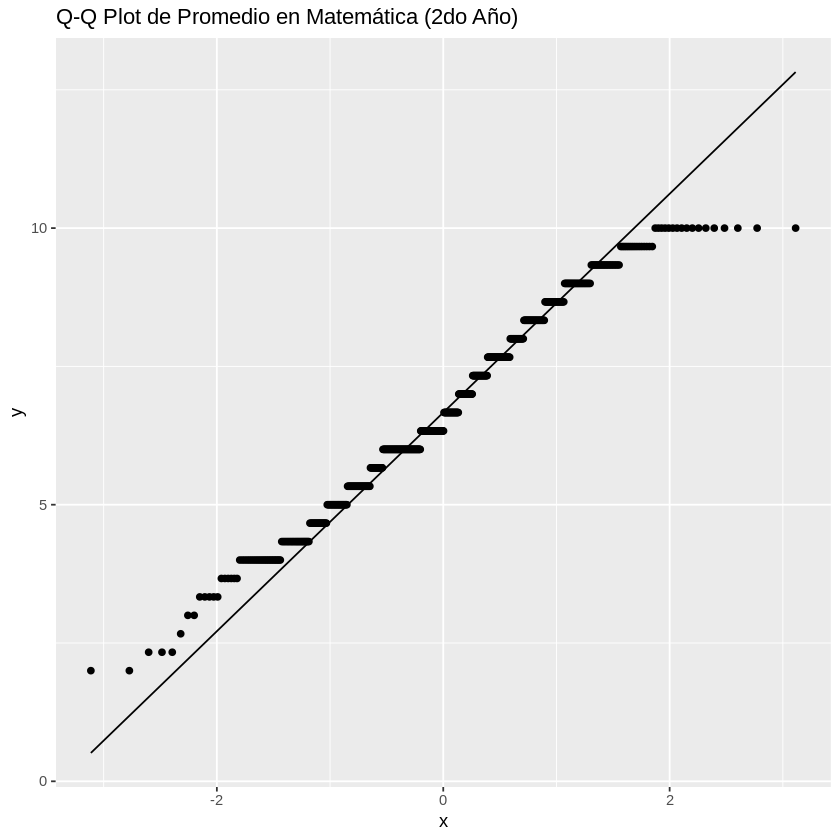

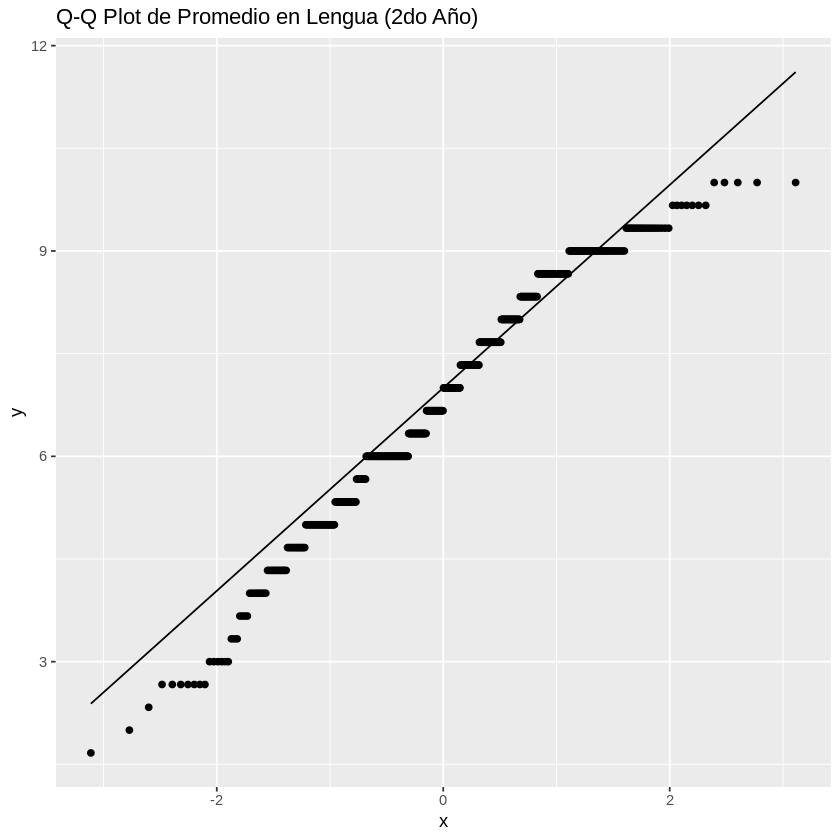

In [ ]:
# Respondemos la Actividad 2 de la Guia 3:¿La distribución es simétrica? Si es asimétrica, ¿la asimetría es a derecha o a izquierda? ¿Qué quiere decir eso?

if(!require(ggplot2)){
  install.packages("ggplot2")
}
library(ggplot2)

# Crear el gráfico Q-Q plot Matematica
ggplot(datos_matematicas_2o, aes(sample = Promedio)) +
  stat_qq() +
  stat_qq_line() +
  labs(title = "Q-Q Plot de Promedio en Matemática (2do Año)")

# Crear el gráfico Q-Q plot Lengua
ggplot(datos_lengua_2o, aes(sample = Promedio)) +
  stat_qq() +
  stat_qq_line() +
  labs(title = "Q-Q Plot de Promedio en Lengua (2do Año)")

In [ ]:
# Realizar la prueba de Kolmogorov-Smirnov
ks.test(datos_matematicas_2o$Promedio, "pnorm")

# Realizar la prueba de Kolmogorov-Smirnov
ks.test(datos_lengua_2o$Promedio, "pnorm")


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  datos_matematicas_2o$Promedio
D = 0.98754, p-value < 2.2e-16
alternative hypothesis: two-sided



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  datos_lengua_2o$Promedio
D = 0.99059, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
# Estandarizar la variable "Promedio" en Matemática de 2do año
datos_matematicas_2o$Promedio_Estandarizado <- scale(datos_matematicas_2o$Promedio)

# Estandarizar la variable "Promedio" en Lengua de 2do año
datos_lengua_2o$Promedio_Estandarizado <- scale(datos_lengua_2o$Promedio)

# Test de Lilliefors para Promedio Estandarizado en Matemática
lillie.test(datos_matematicas_2o$Promedio_Estandarizado)

# Test de Lilliefors para Promedio Estandarizado en Lengua
lillie.test(datos_lengua_2o$Promedio_Estandarizado)


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  datos_matematicas_2o$Promedio_Estandarizado
D = 0.085047, p-value = 5.488e-10



	Lilliefors (Kolmogorov-Smirnov) normality test

data:  datos_lengua_2o$Promedio_Estandarizado
D = 0.070642, p-value = 9.91e-07


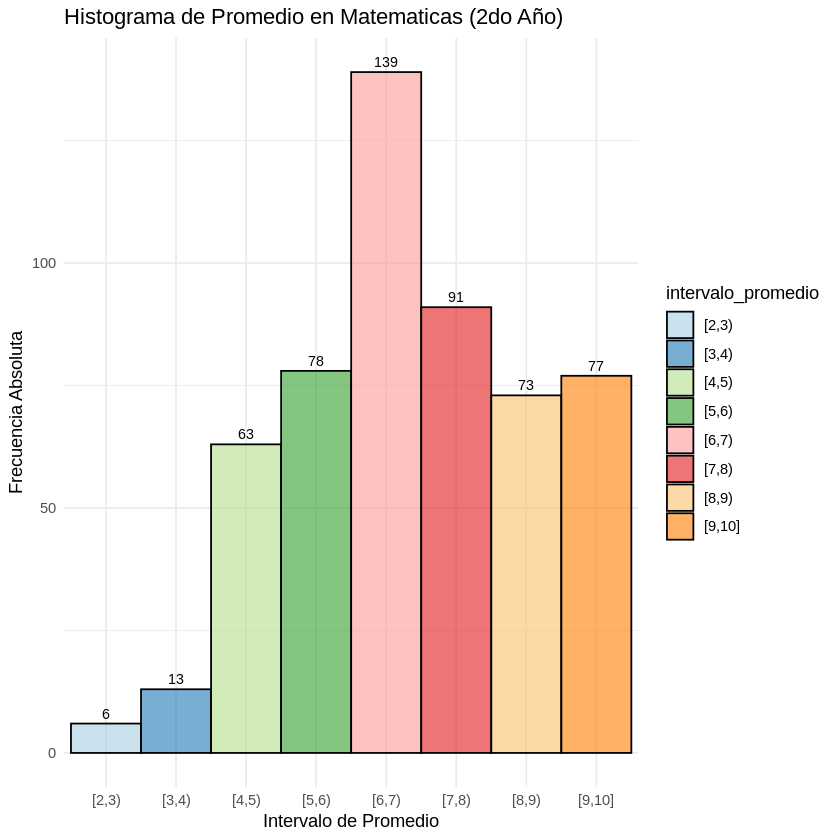

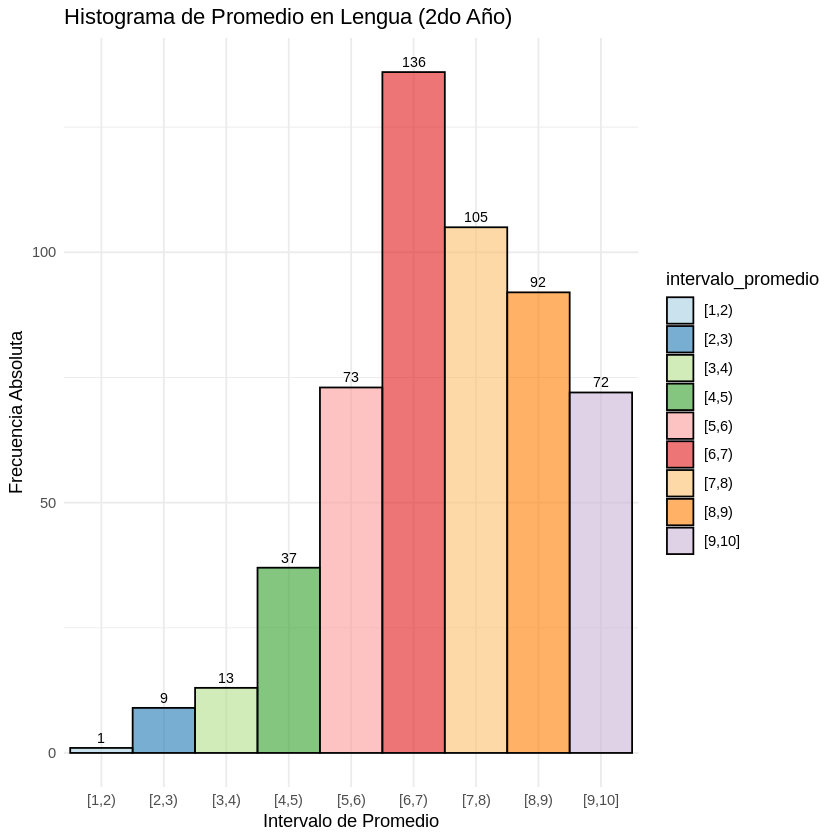

In [ ]:
# ¿Cuáles son las notas más frecuentes? ¿Y las menos frecuentes?

# Creamos la tabla de frecuencia con sus intervalos

# Definir los intervalos (bins)
breaks <- seq(1, 10, by = 1) # Intervalos de 1 en 1 desde 1 hasta 10

# Crear una nueva columna con los intervalos
datos_matematicas22 <- datos_matematicas_2o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

datos_lengua22 <- datos_lengua_2o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

# Crear tabla de frecuencias por intervalos (sin agrupar por division)
tabla_frecuencias_mates2 <- datos_matematicas22 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

tabla_frecuencias_lengua2 <- datos_lengua22 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

# Creamos los Histogramas

ggplot(tabla_frecuencias_mates2, aes(x = intervalo_promedio, y = Frecuencia_Absoluta, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Matematicas (2do Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

ggplot(tabla_frecuencias_lengua2, aes(x = intervalo_promedio, y = Frecuencia_Absoluta, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Lengua (2do Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

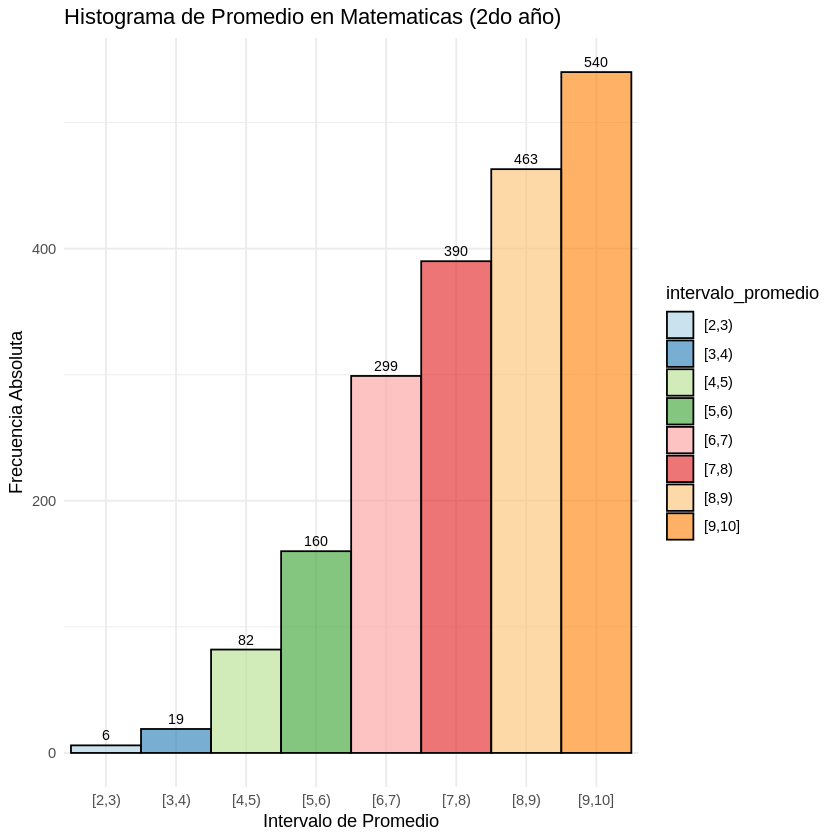

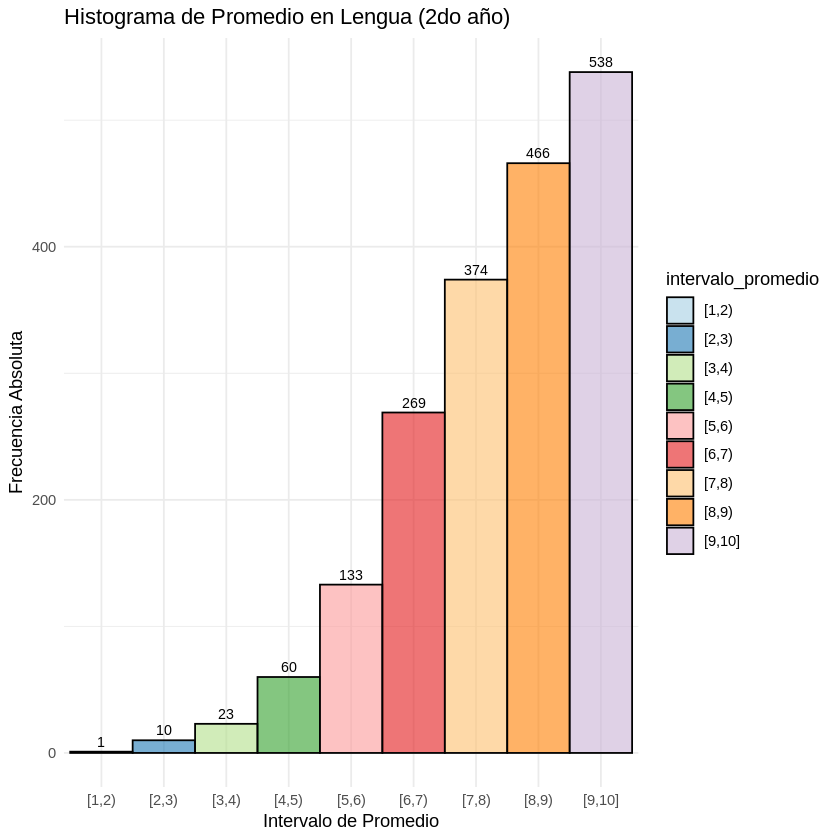

In [ ]:
# Creamos los Histogramas de Frecuencias Acumuladas:

ggplot(tabla_frecuencias_mates2, aes(x = intervalo_promedio, y = Frecuencia_Absoluta_Acumulada, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta_Acumulada), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Matematicas (2do año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

ggplot(tabla_frecuencias_lengua2, aes(x = intervalo_promedio, y = Frecuencia_Absoluta_Acumulada, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta_Acumulada), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Lengua (2do año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

### 3ro Año de Matematica y Lengua:

In [ ]:
# primero segmentamos las materias Matematicas y Lengua en 2do año:

library(dplyr)
library(ggplot2)

# Combinar divisiones en una nueva columna
datos_matematicas_3o <- datos_matematicas %>%
  filter(curso == "3ro Secundaria") %>%
  mutate(division_agrupada = "3ro Año")

datos_lengua_3o <- datos_lengua %>%
  filter(curso == "3ro Secundaria") %>%
  mutate(division_agrupada = "3ro Año")

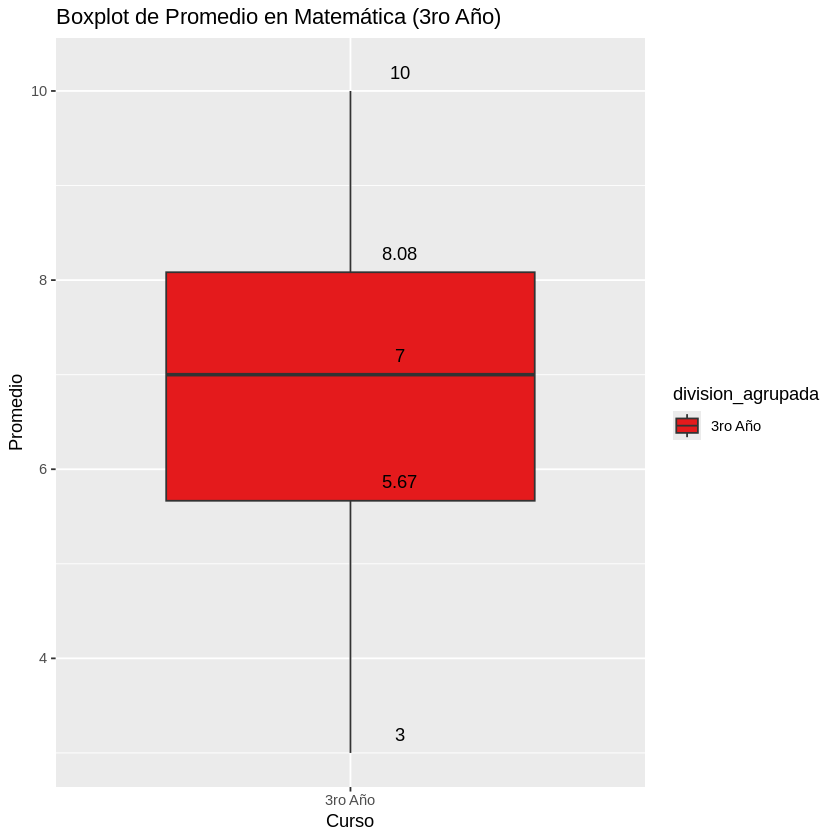

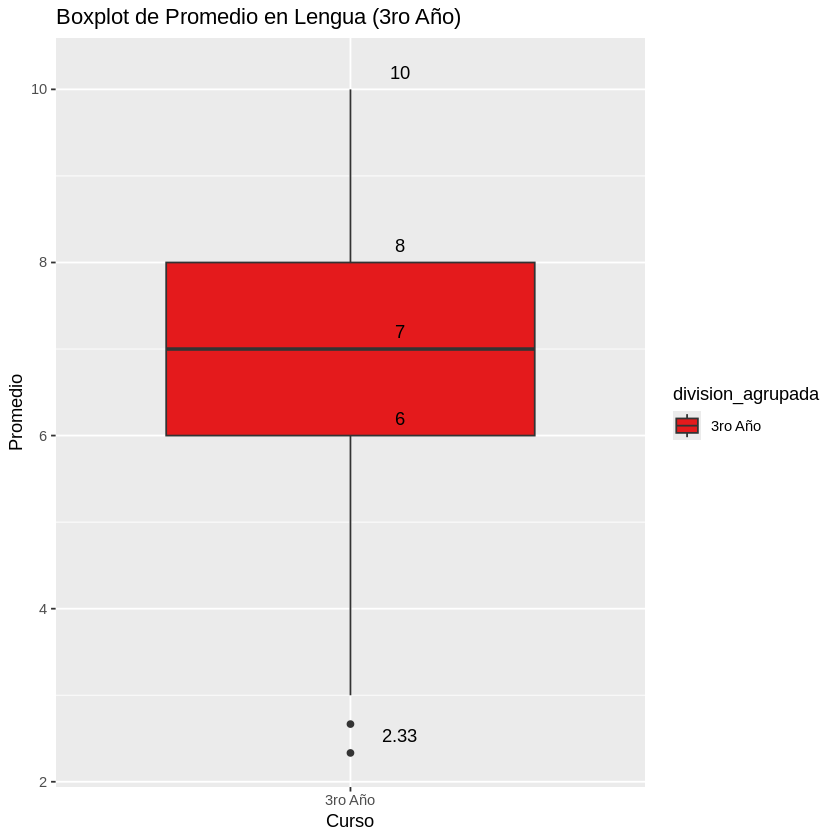

In [ ]:
# Crear los boxplots con modificaciones
plot_matematica3 <- ggplot(datos_matematicas_3o, aes(x = division_agrupada, y = Promedio, fill = division_agrupada)) +
  geom_boxplot() +  # Quitamos notch = TRUE para eliminar las muescas
  # Quitamos geom_jitter() para eliminar los puntos
  scale_fill_brewer(palette = "Set1") +  # Usar paleta de colores "Set1"
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),  # Agregar etiquetas con dos decimales
               position = position_nudge(x = 0.1, y = 0.2)) +  # Ajustar posición de etiquetas
  labs(title = "Boxplot de Promedio en Matemática (3ro Año)",
       x = "Curso",
       y = "Promedio")

plot_lengua3 <- ggplot(datos_lengua_3o, aes(x = division_agrupada, y = Promedio, fill = division_agrupada)) +
  geom_boxplot() +  # Quitamos notch = TRUE para eliminar las muescas
  # Quitamos geom_jitter() para eliminar los puntos
  scale_fill_brewer(palette = "Set1") +  # Usar paleta de colores "Set1"
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),  # Agregar etiquetas con dos decimales
               position = position_nudge(x = 0.1, y = 0.2)) +  # Ajustar posición de etiquetas
  labs(title = "Boxplot de Promedio en Lengua (3ro Año)",
       x = "Curso",
       y = "Promedio")

print(plot_matematica3)
print(plot_lengua3)

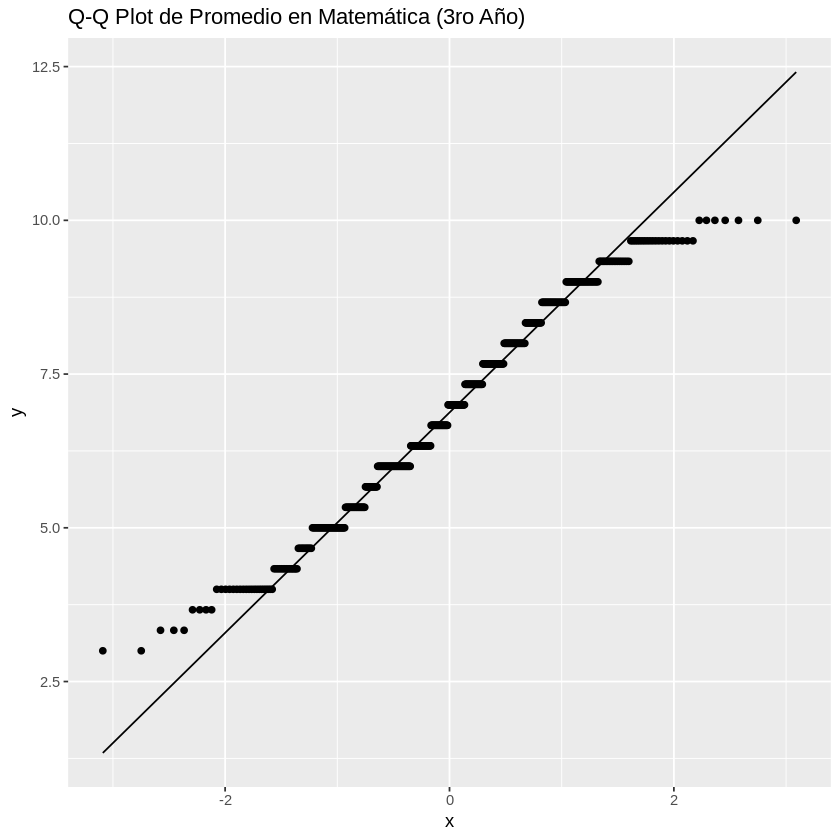

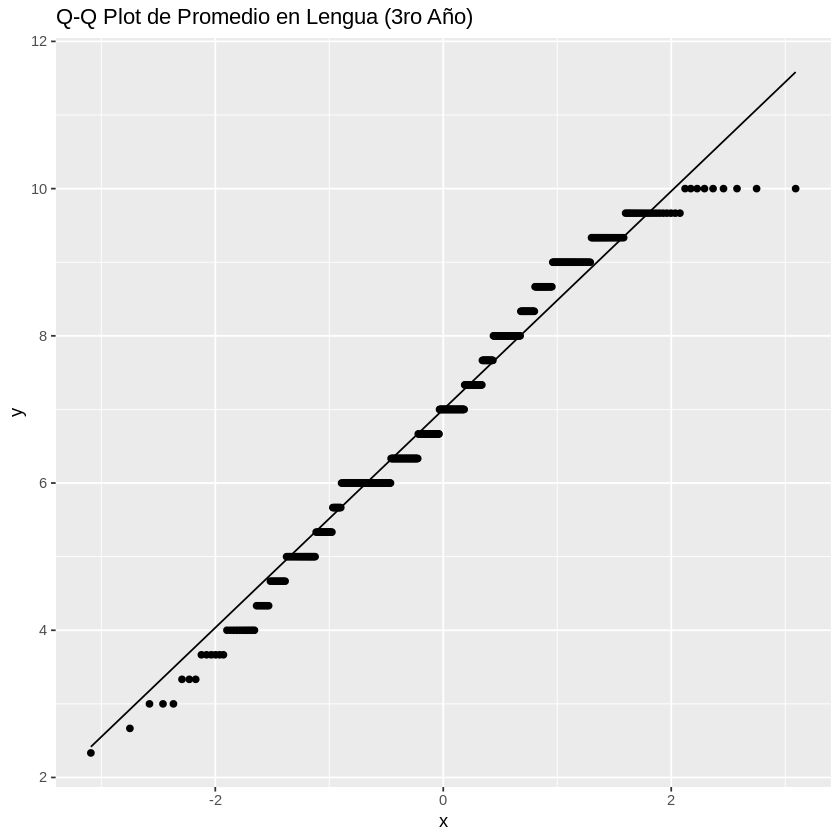

In [ ]:
# Respondemos la Actividad 2 de la Guia 3:¿La distribución es simétrica? Si es asimétrica, ¿la asimetría es a derecha o a izquierda? ¿Qué quiere decir eso?

if(!require(ggplot2)){
  install.packages("ggplot2")
}
library(ggplot2)

# Crear el gráfico Q-Q plot Matematica
ggplot(datos_matematicas_3o, aes(sample = Promedio)) +
  stat_qq() +
  stat_qq_line() +
  labs(title = "Q-Q Plot de Promedio en Matemática (3ro Año)")

# Crear el gráfico Q-Q plot Lengua
ggplot(datos_lengua_3o, aes(sample = Promedio)) +
  stat_qq() +
  stat_qq_line() +
  labs(title = "Q-Q Plot de Promedio en Lengua (3ro Año)")

In [ ]:
# Realizar la prueba de Kolmogorov-Smirnov
ks.test(datos_matematicas_3o$Promedio, "pnorm")

# Realizar la prueba de Kolmogorov-Smirnov
ks.test(datos_lengua_3o$Promedio, "pnorm")


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  datos_matematicas_3o$Promedio
D = 0.99865, p-value < 2.2e-16
alternative hypothesis: two-sided



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  datos_lengua_3o$Promedio
D = 0.99467, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
# Estandarizar la variable "Promedio" en Matemática de 3ro año
datos_matematicas_3o$Promedio_Estandarizado <- scale(datos_matematicas_3o$Promedio)

# Estandarizar la variable "Promedio" en Lengua de 3ro año
datos_lengua_3o$Promedio_Estandarizado <- scale(datos_lengua_3o$Promedio)

# Test de Lilliefors para Promedio Estandarizado en Matemática
lillie.test(datos_matematicas_3o$Promedio_Estandarizado)

# Test de Lilliefors para Promedio Estandarizado en Lengua
lillie.test(datos_lengua_3o$Promedio_Estandarizado)


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  datos_matematicas_3o$Promedio_Estandarizado
D = 0.069479, p-value = 4.98e-06



	Lilliefors (Kolmogorov-Smirnov) normality test

data:  datos_lengua_3o$Promedio_Estandarizado
D = 0.082317, p-value = 1.205e-08


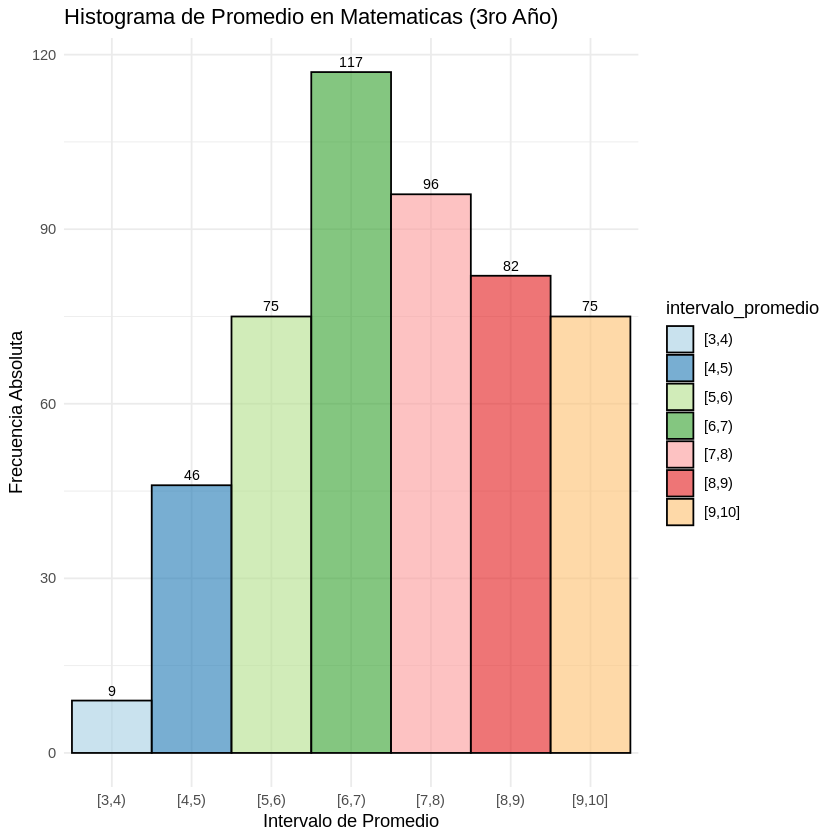

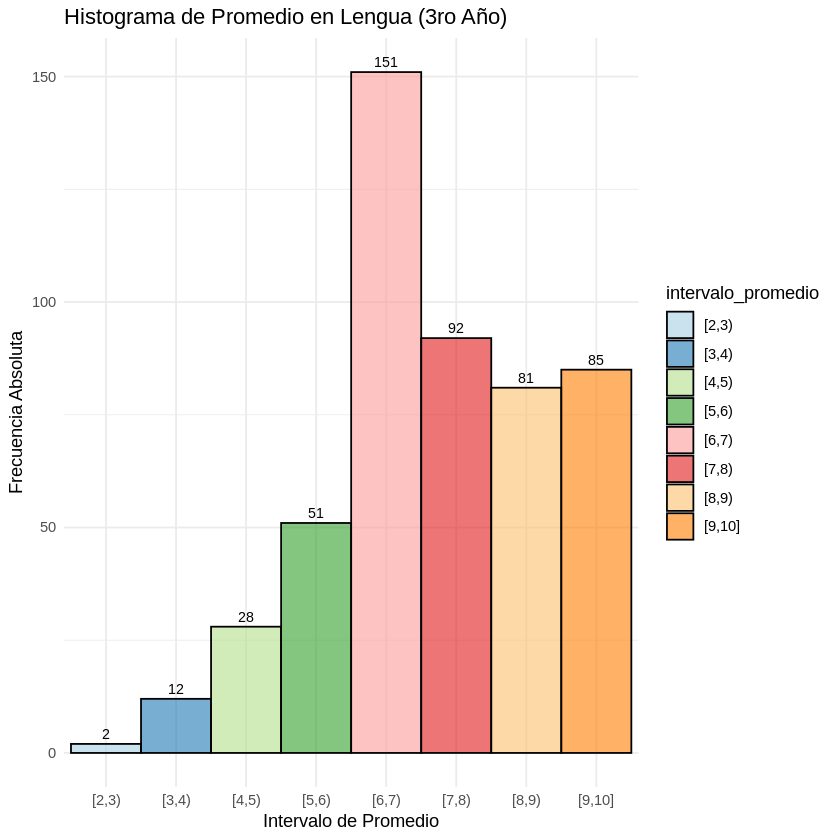

In [ ]:
# ¿Cuáles son las notas más frecuentes? ¿Y las menos frecuentes?

# Creamos la tabla de frecuencia con sus intervalos

# Definir los intervalos (bins)
breaks <- seq(1, 10, by = 1) # Intervalos de 1 en 1 desde 1 hasta 10

# Crear una nueva columna con los intervalos
datos_matematicas3 <- datos_matematicas_3o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

datos_lengua3 <- datos_lengua_3o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

# Crear tabla de frecuencias por intervalos (sin agrupar por division)
tabla_frecuencias_mates3 <- datos_matematicas3 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

tabla_frecuencias_lengua3 <- datos_lengua3 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

# Creamos los Histogramas

ggplot(tabla_frecuencias_mates3, aes(x = intervalo_promedio, y = Frecuencia_Absoluta, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Matematicas (3ro Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

ggplot(tabla_frecuencias_lengua3, aes(x = intervalo_promedio, y = Frecuencia_Absoluta, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Lengua (3ro Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

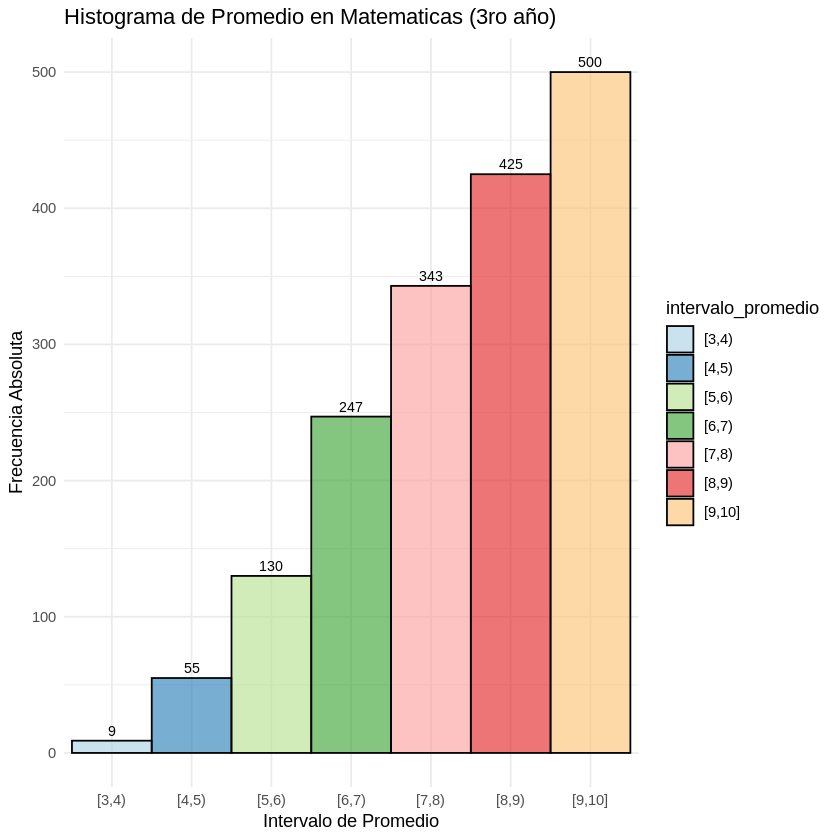

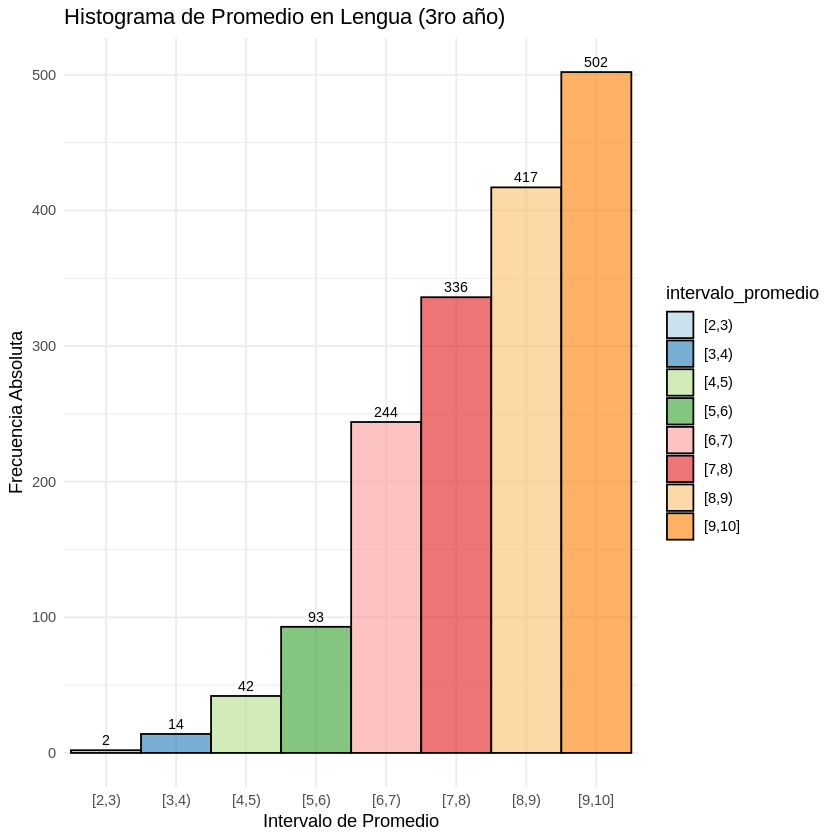

In [ ]:
# Creamos los Histogramas de Frecuencias Acumuladas:

ggplot(tabla_frecuencias_mates3, aes(x = intervalo_promedio, y = Frecuencia_Absoluta_Acumulada, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta_Acumulada), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Matematicas (3ro año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

ggplot(tabla_frecuencias_lengua3, aes(x = intervalo_promedio, y = Frecuencia_Absoluta_Acumulada, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta_Acumulada), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Lengua (3ro año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

### 4to Año Matematica y Lengua:

In [ ]:
# primero segmentamos las materias Matematicas y Lengua en 2do año:

library(dplyr)
library(ggplot2)

# Combinar divisiones en una nueva columna
datos_matematicas_4o <- datos_matematicas %>%
  filter(curso == "4to Secundaria") %>%
  mutate(division_agrupada = "4to Año")

datos_lengua_4o <- datos_lengua %>%
  filter(curso == "4to Secundaria") %>%
  mutate(division_agrupada = "4to Año")

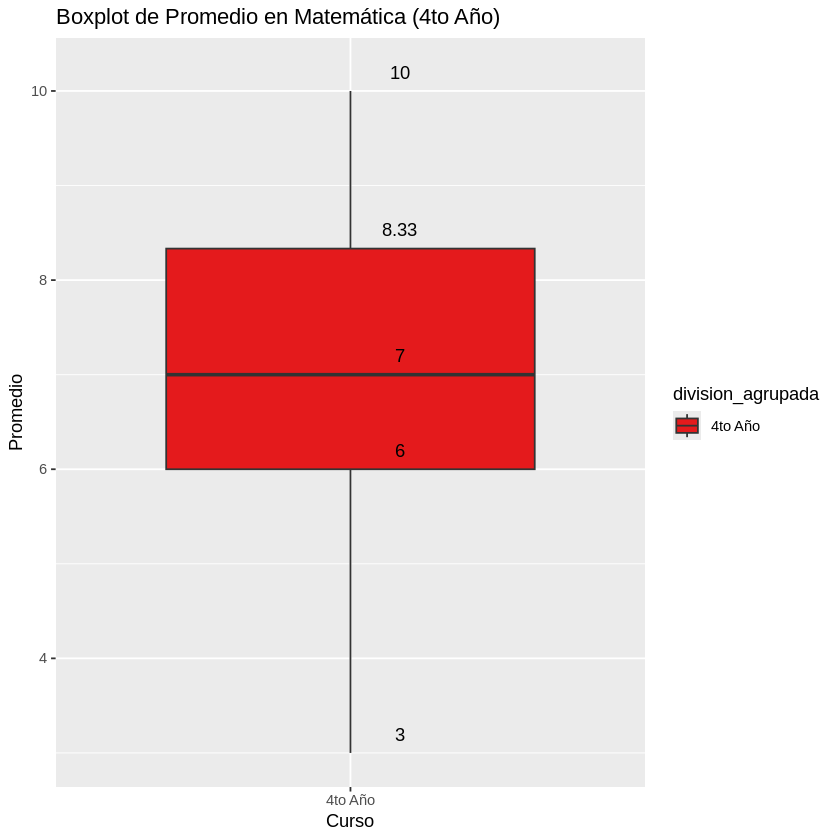

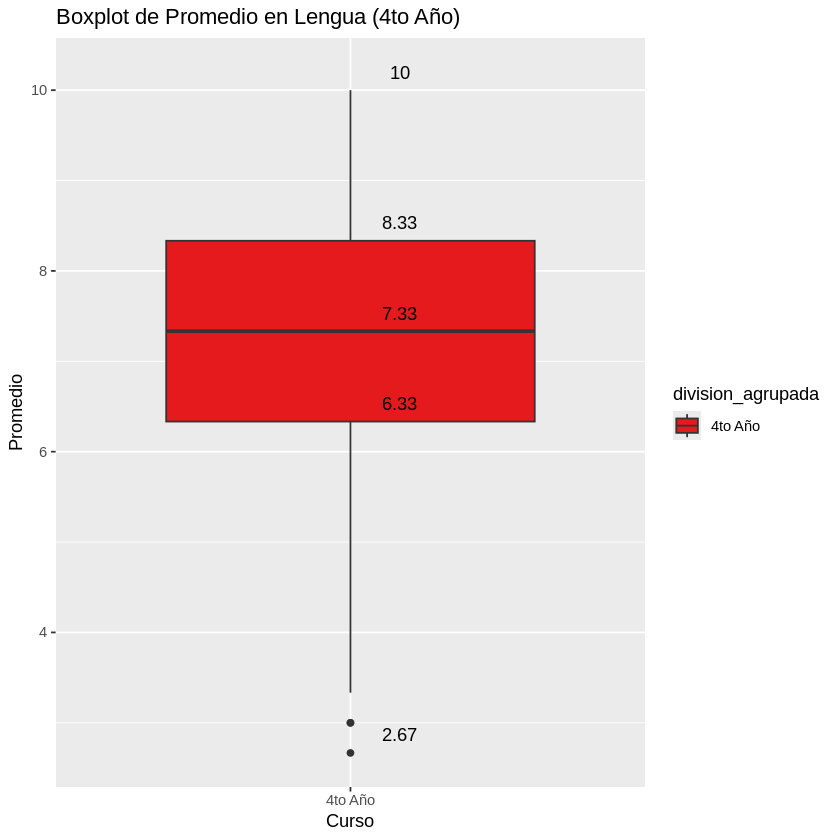

In [ ]:
# Crear los boxplots con modificaciones
plot_matematica4 <- ggplot(datos_matematicas_4o, aes(x = division_agrupada, y = Promedio, fill = division_agrupada)) +
  geom_boxplot() +  # Quitamos notch = TRUE para eliminar las muescas
  # Quitamos geom_jitter() para eliminar los puntos
  scale_fill_brewer(palette = "Set1") +  # Usar paleta de colores "Set1"
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),  # Agregar etiquetas con dos decimales
               position = position_nudge(x = 0.1, y = 0.2)) +  # Ajustar posición de etiquetas
  labs(title = "Boxplot de Promedio en Matemática (4to Año)",
       x = "Curso",
       y = "Promedio")

plot_lengua4 <- ggplot(datos_lengua_4o, aes(x = division_agrupada, y = Promedio, fill = division_agrupada)) +
  geom_boxplot() +  # Quitamos notch = TRUE para eliminar las muescas
  # Quitamos geom_jitter() para eliminar los puntos
  scale_fill_brewer(palette = "Set1") +  # Usar paleta de colores "Set1"
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),  # Agregar etiquetas con dos decimales
               position = position_nudge(x = 0.1, y = 0.2)) +  # Ajustar posición de etiquetas
  labs(title = "Boxplot de Promedio en Lengua (4to Año)",
       x = "Curso",
       y = "Promedio")

print(plot_matematica4)
print(plot_lengua4)

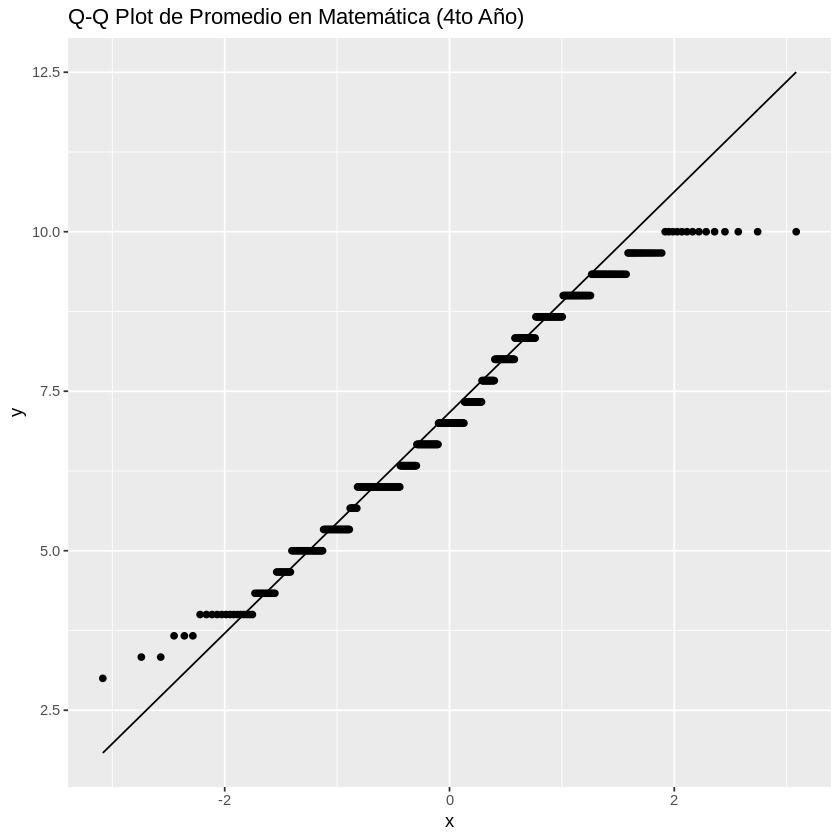

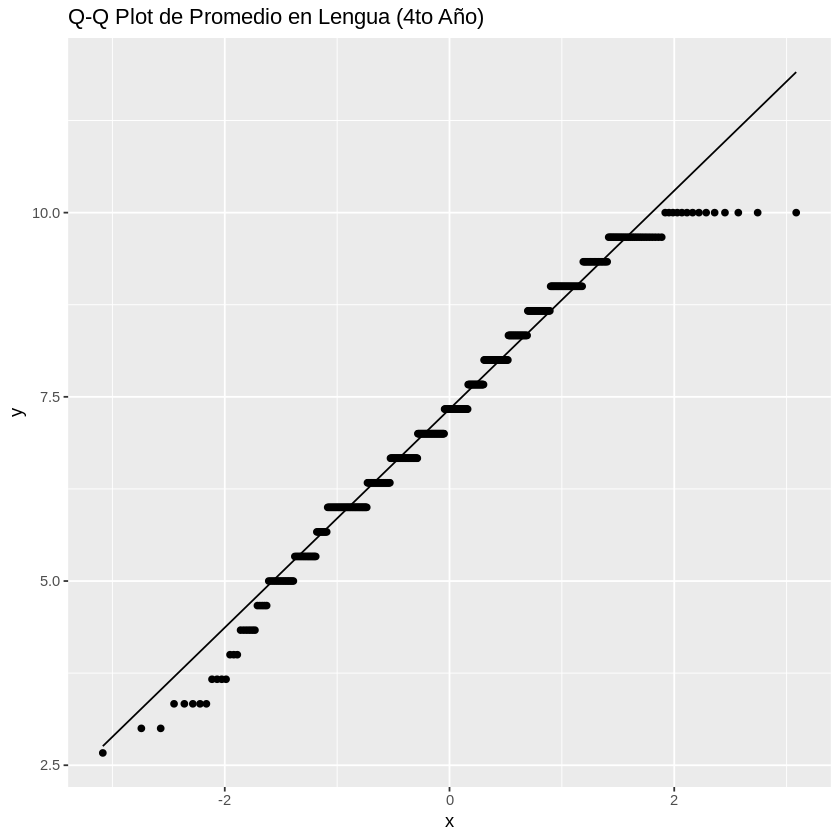

In [ ]:
# Respondemos la Actividad 2 de la Guia 3:¿La distribución es simétrica? Si es asimétrica, ¿la asimetría es a derecha o a izquierda? ¿Qué quiere decir eso?

if(!require(ggplot2)){
  install.packages("ggplot2")
}
library(ggplot2)

# Crear el gráfico Q-Q plot Matematica
ggplot(datos_matematicas_4o, aes(sample = Promedio)) +
  stat_qq() +
  stat_qq_line() +
  labs(title = "Q-Q Plot de Promedio en Matemática (4to Año)")

# Crear el gráfico Q-Q plot Lengua
ggplot(datos_lengua_4o, aes(sample = Promedio)) +
  stat_qq() +
  stat_qq_line() +
  labs(title = "Q-Q Plot de Promedio en Lengua (4to Año)")

In [ ]:
# Realizar la prueba de Kolmogorov-Smirnov
ks.test(datos_matematicas_4o$Promedio, "pnorm")

# Realizar la prueba de Kolmogorov-Smirnov
ks.test(datos_lengua_4o$Promedio, "pnorm")


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  datos_matematicas_4o$Promedio
D = 0.99865, p-value < 2.2e-16
alternative hypothesis: two-sided



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  datos_lengua_4o$Promedio
D = 0.99662, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
# Estandarizar la variable "Promedio" en Matemática de 4to año
datos_matematicas_4o$Promedio_Estandarizado <- scale(datos_matematicas_4o$Promedio)

# Estandarizar la variable "Promedio" en Lengua de 4to año
datos_lengua_4o$Promedio_Estandarizado <- scale(datos_lengua_4o$Promedio)

# Test de Lilliefors para Promedio Estandarizado en Matemática
lillie.test(datos_matematicas_4o$Promedio_Estandarizado)

# Test de Lilliefors para Promedio Estandarizado en Lengua
lillie.test(datos_lengua_4o$Promedio_Estandarizado)


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  datos_matematicas_4o$Promedio_Estandarizado
D = 0.074618, p-value = 7.141e-07



	Lilliefors (Kolmogorov-Smirnov) normality test

data:  datos_lengua_4o$Promedio_Estandarizado
D = 0.062125, p-value = 0.0001067


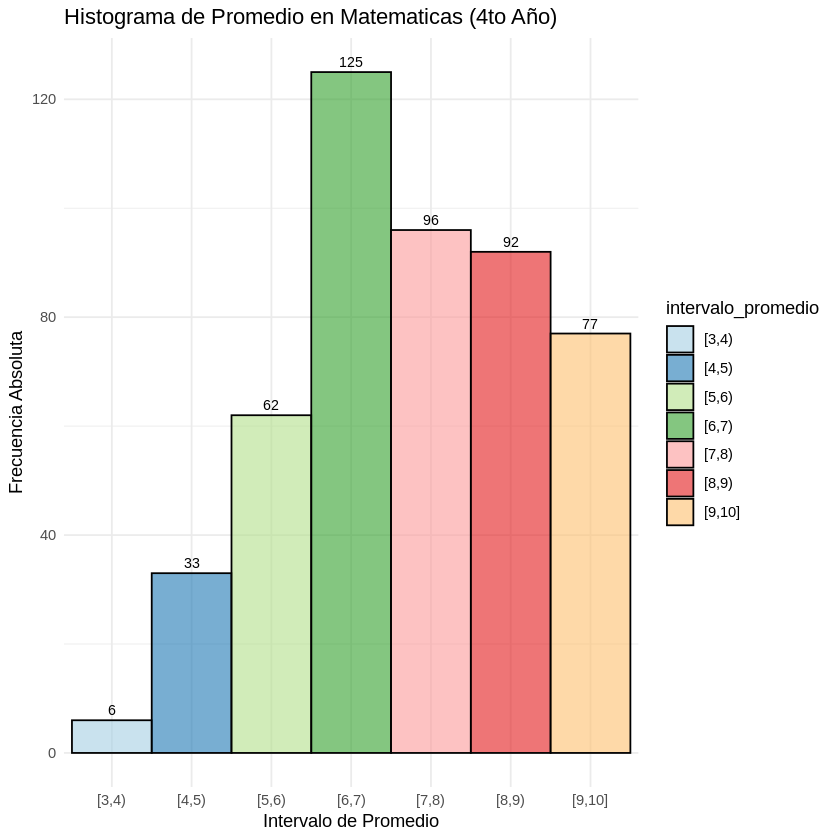

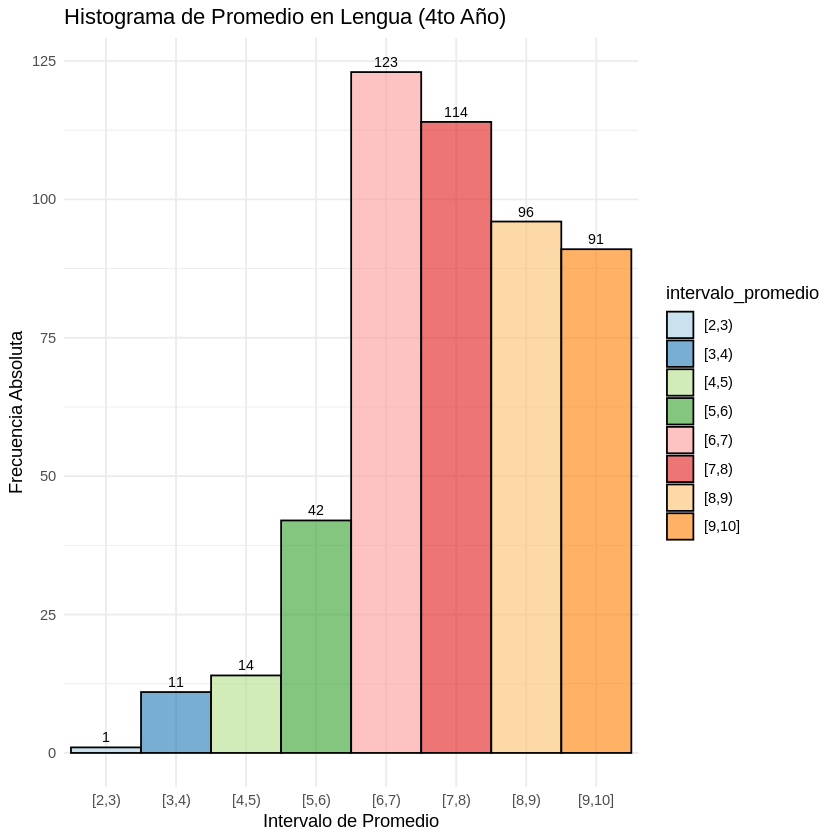

In [ ]:
# ¿Cuáles son las notas más frecuentes? ¿Y las menos frecuentes?

# Creamos la tabla de frecuencia con sus intervalos

# Definir los intervalos (bins)
breaks <- seq(1, 10, by = 1) # Intervalos de 1 en 1 desde 1 hasta 10

# Crear una nueva columna con los intervalos
datos_matematicas4 <- datos_matematicas_4o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

datos_lengua4 <- datos_lengua_4o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

# Crear tabla de frecuencias por intervalos (sin agrupar por division)
tabla_frecuencias_mates4 <- datos_matematicas4 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

tabla_frecuencias_lengua4 <- datos_lengua4 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

# Creamos los Histogramas

ggplot(tabla_frecuencias_mates4, aes(x = intervalo_promedio, y = Frecuencia_Absoluta, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Matematicas (4to Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

ggplot(tabla_frecuencias_lengua4, aes(x = intervalo_promedio, y = Frecuencia_Absoluta, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Lengua (4to Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

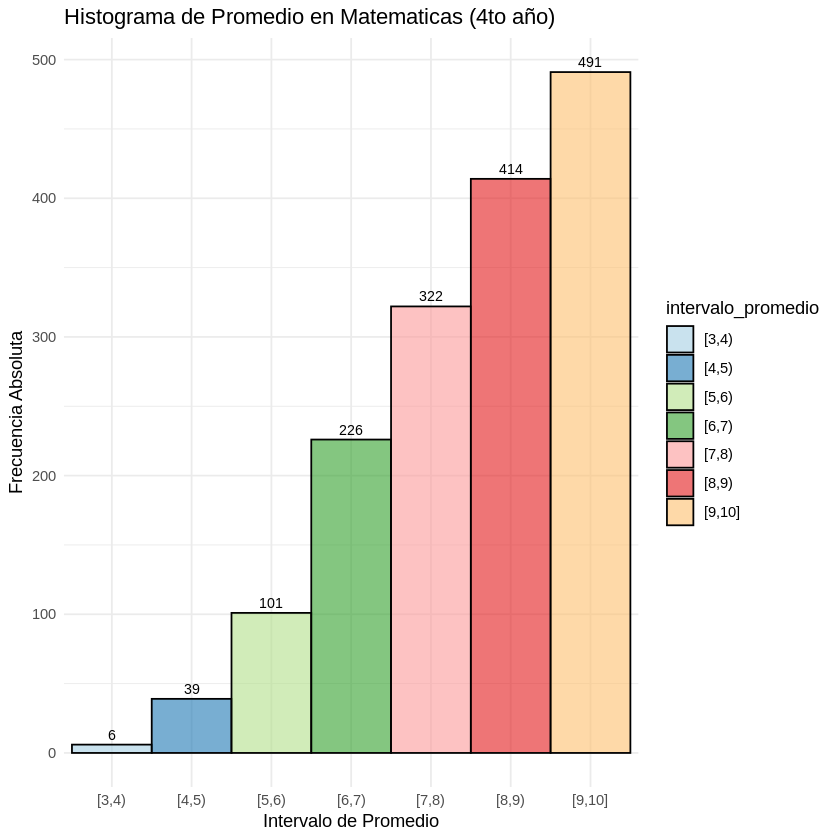

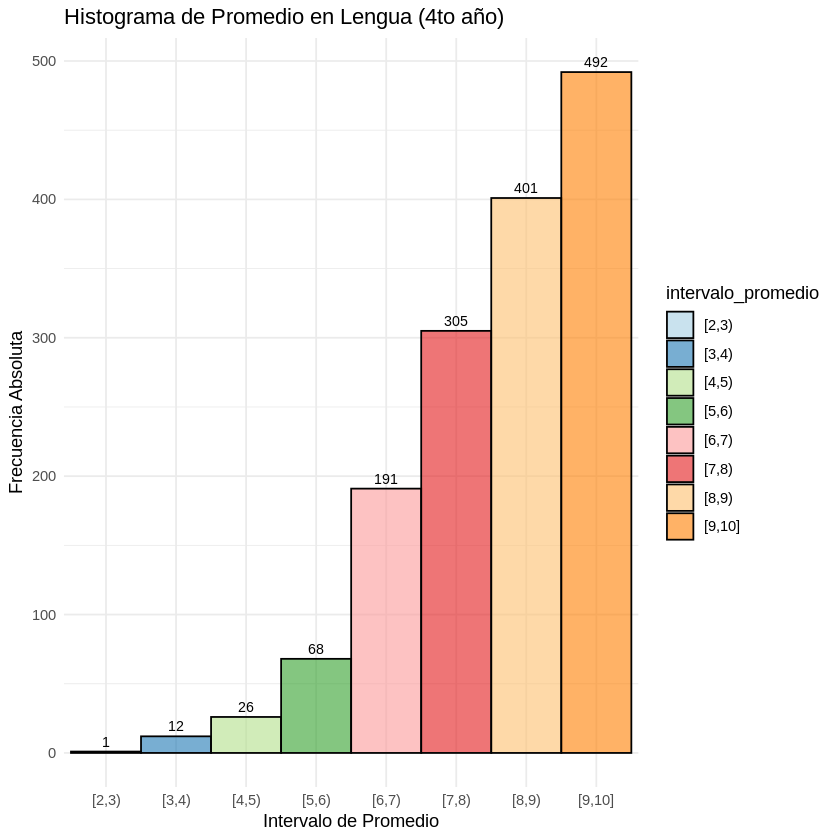

In [ ]:
# Creamos los Histogramas de Frecuencias Acumuladas:

ggplot(tabla_frecuencias_mates4, aes(x = intervalo_promedio, y = Frecuencia_Absoluta_Acumulada, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta_Acumulada), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Matematicas (4to año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

ggplot(tabla_frecuencias_lengua4, aes(x = intervalo_promedio, y = Frecuencia_Absoluta_Acumulada, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta_Acumulada), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Lengua (4to año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

### 5to Año Matematica y Lengua:

In [ ]:
# primero segmentamos las materias Matematicas y Lengua en 2do año:

library(dplyr)
library(ggplot2)

# Combinar divisiones en una nueva columna
datos_matematicas_5o <- datos_matematicas %>%
  filter(curso == "5to Secundaria") %>%
  mutate(division_agrupada = "5to Año")

datos_lengua_5o <- datos_lengua %>%
  filter(curso == "5to Secundaria") %>%
  mutate(division_agrupada = "5to Año")

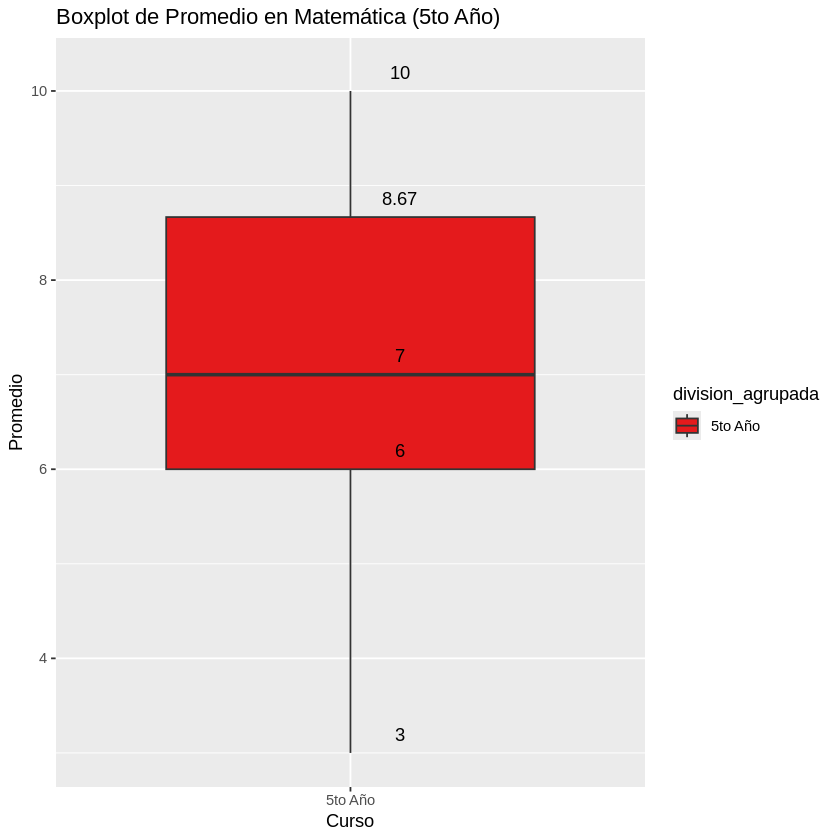

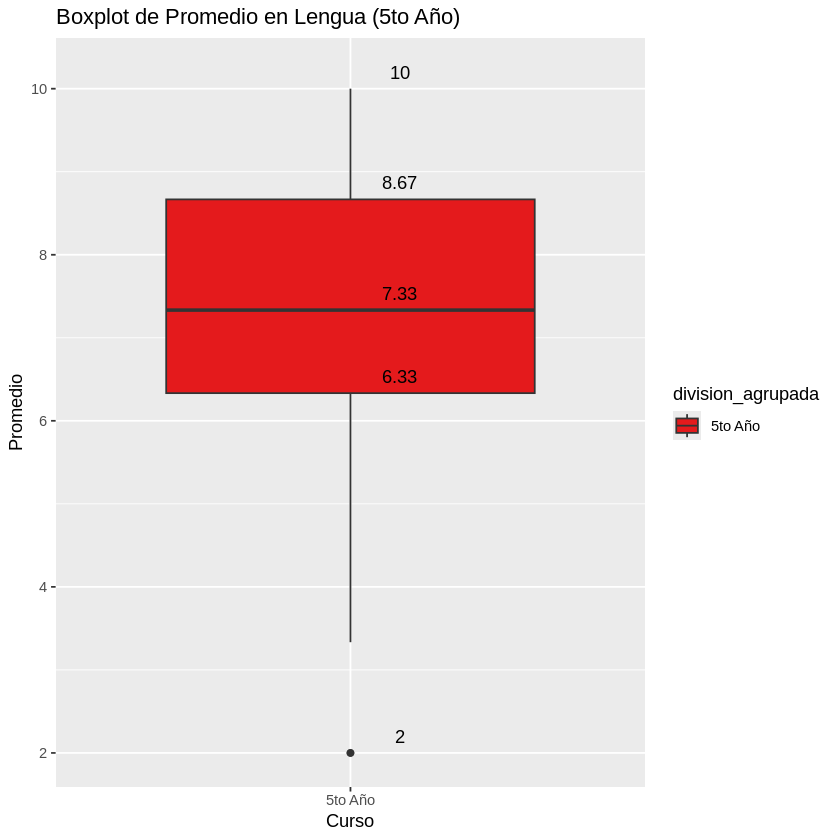

In [ ]:
# Crear los boxplots con modificaciones
plot_matematica5 <- ggplot(datos_matematicas_5o, aes(x = division_agrupada, y = Promedio, fill = division_agrupada)) +
  geom_boxplot() +  # Quitamos notch = TRUE para eliminar las muescas
  # Quitamos geom_jitter() para eliminar los puntos
  scale_fill_brewer(palette = "Set1") +  # Usar paleta de colores "Set1"
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),  # Agregar etiquetas con dos decimales
               position = position_nudge(x = 0.1, y = 0.2)) +  # Ajustar posición de etiquetas
  labs(title = "Boxplot de Promedio en Matemática (5to Año)",
       x = "Curso",
       y = "Promedio")

plot_lengua5 <- ggplot(datos_lengua_5o, aes(x = division_agrupada, y = Promedio, fill = division_agrupada)) +
  geom_boxplot() +  # Quitamos notch = TRUE para eliminar las muescas
  # Quitamos geom_jitter() para eliminar los puntos
  scale_fill_brewer(palette = "Set1") +  # Usar paleta de colores "Set1"
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),  # Agregar etiquetas con dos decimales
               position = position_nudge(x = 0.1, y = 0.2)) +  # Ajustar posición de etiquetas
  labs(title = "Boxplot de Promedio en Lengua (5to Año)",
       x = "Curso",
       y = "Promedio")

print(plot_matematica5)
print(plot_lengua5)

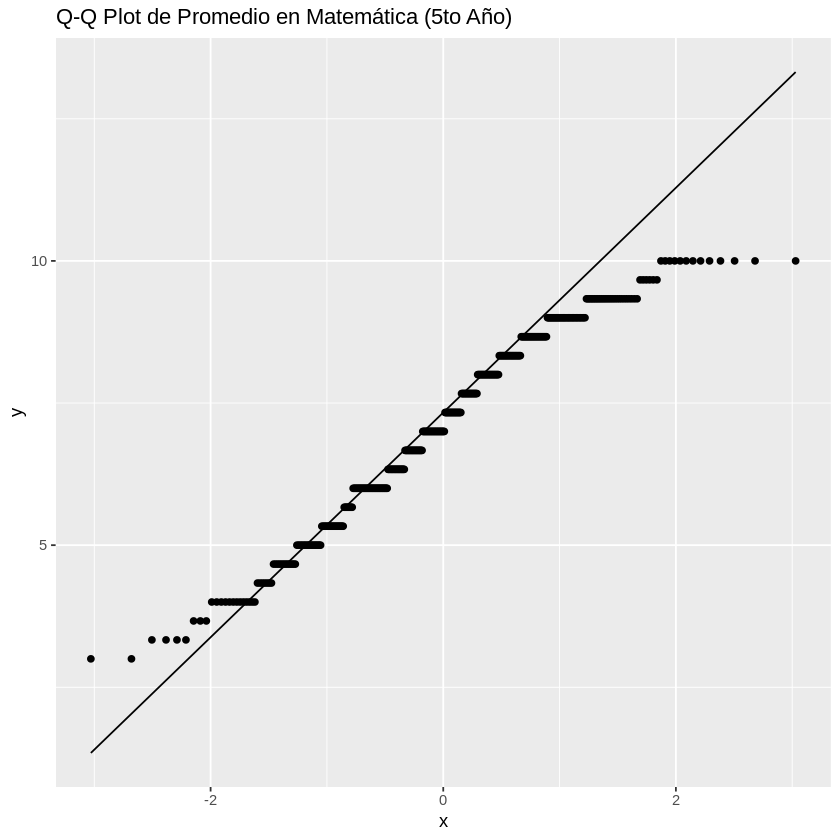

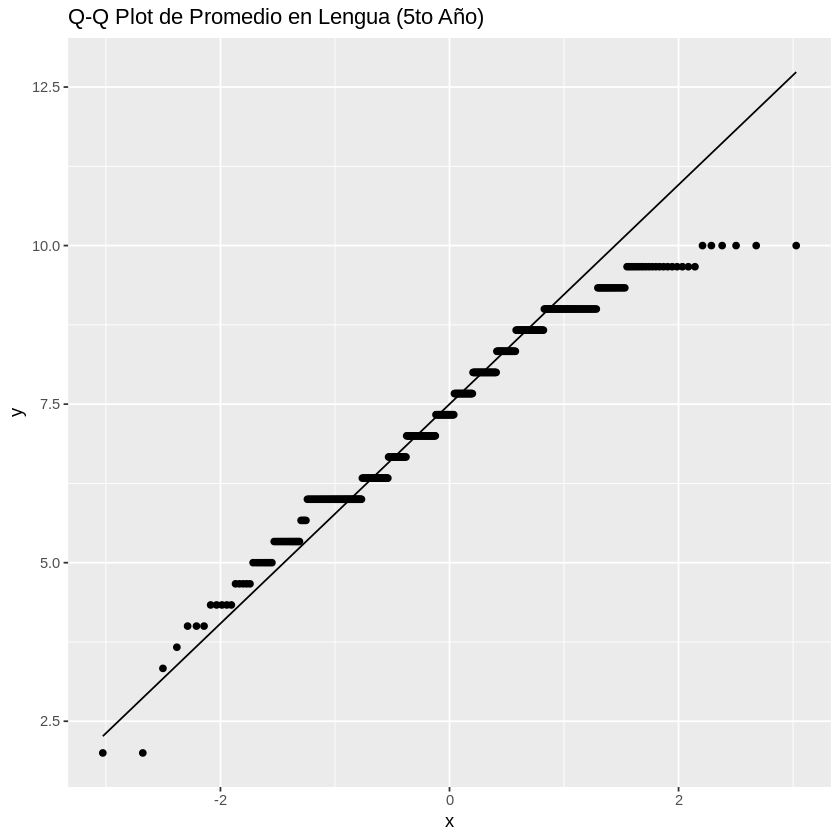

In [ ]:
# Respondemos la Actividad 2 de la Guia 3:¿La distribución es simétrica? Si es asimétrica, ¿la asimetría es a derecha o a izquierda? ¿Qué quiere decir eso?

if(!require(ggplot2)){
  install.packages("ggplot2")
}
library(ggplot2)

# Crear el gráfico Q-Q plot Matematica
ggplot(datos_matematicas_5o, aes(sample = Promedio)) +
  stat_qq() +
  stat_qq_line() +
  labs(title = "Q-Q Plot de Promedio en Matemática (5to Año)")

# Crear el gráfico Q-Q plot Lengua
ggplot(datos_lengua_5o, aes(sample = Promedio)) +
  stat_qq() +
  stat_qq_line() +
  labs(title = "Q-Q Plot de Promedio en Lengua (5to Año)")

In [ ]:
# Realizar la prueba de Kolmogorov-Smirnov
ks.test(datos_matematicas_5o$Promedio, "pnorm")

# Realizar la prueba de Kolmogorov-Smirnov
ks.test(datos_lengua_5o$Promedio, "pnorm")


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  datos_matematicas_5o$Promedio
D = 0.99865, p-value < 2.2e-16
alternative hypothesis: two-sided



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  datos_lengua_5o$Promedio
D = 0.99463, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
# Estandarizar la variable "Promedio" en Matemática de 5to año
datos_matematicas_5o$Promedio_Estandarizado <- scale(datos_matematicas_5o$Promedio)

# Estandarizar la variable "Promedio" en Lengua de 5to año
datos_lengua_5o$Promedio_Estandarizado <- scale(datos_lengua_5o$Promedio)

# Test de Lilliefors para Promedio Estandarizado en Matemática
lillie.test(datos_matematicas_5o$Promedio_Estandarizado)

# Test de Lilliefors para Promedio Estandarizado en Lengua
lillie.test(datos_lengua_5o$Promedio_Estandarizado)


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  datos_matematicas_5o$Promedio_Estandarizado
D = 0.088733, p-value = 3.558e-08



	Lilliefors (Kolmogorov-Smirnov) normality test

data:  datos_lengua_5o$Promedio_Estandarizado
D = 0.089401, p-value = 3.048e-08


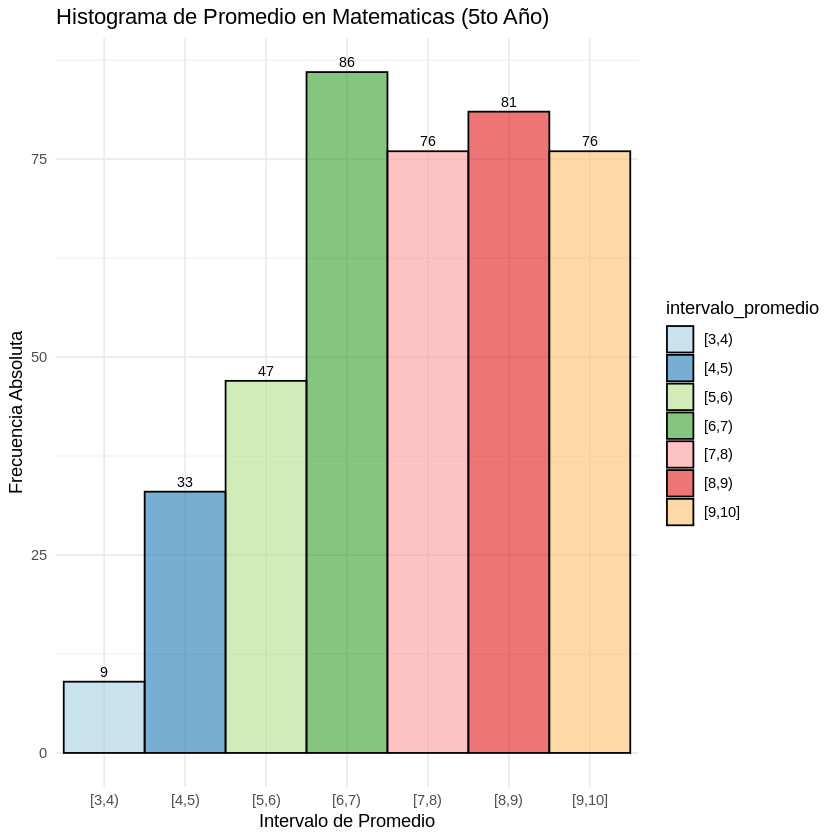

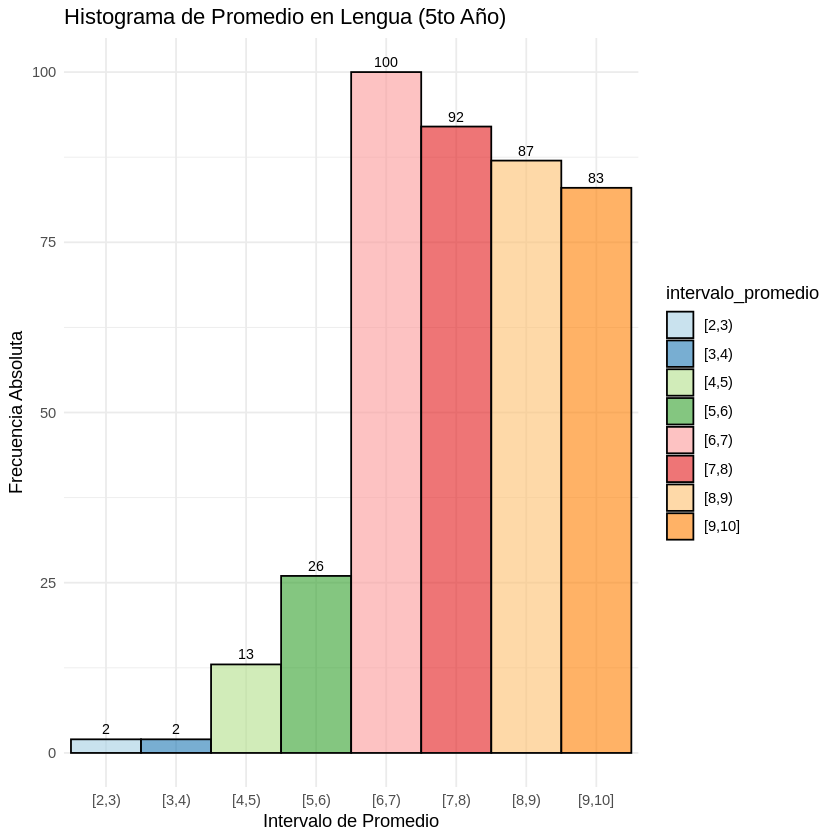

In [ ]:
# ¿Cuáles son las notas más frecuentes? ¿Y las menos frecuentes?

# Creamos la tabla de frecuencia con sus intervalos

# Definir los intervalos (bins)
breaks <- seq(1, 10, by = 1) # Intervalos de 1 en 1 desde 1 hasta 10

# Crear una nueva columna con los intervalos
datos_matematicas5 <- datos_matematicas_5o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

datos_lengua5 <- datos_lengua_5o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

# Crear tabla de frecuencias por intervalos (sin agrupar por division)
tabla_frecuencias_mates5 <- datos_matematicas5 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

tabla_frecuencias_lengua5 <- datos_lengua5 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

# Creamos los Histogramas

ggplot(tabla_frecuencias_mates5, aes(x = intervalo_promedio, y = Frecuencia_Absoluta, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Matematicas (5to Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

ggplot(tabla_frecuencias_lengua5, aes(x = intervalo_promedio, y = Frecuencia_Absoluta, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Lengua (5to Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

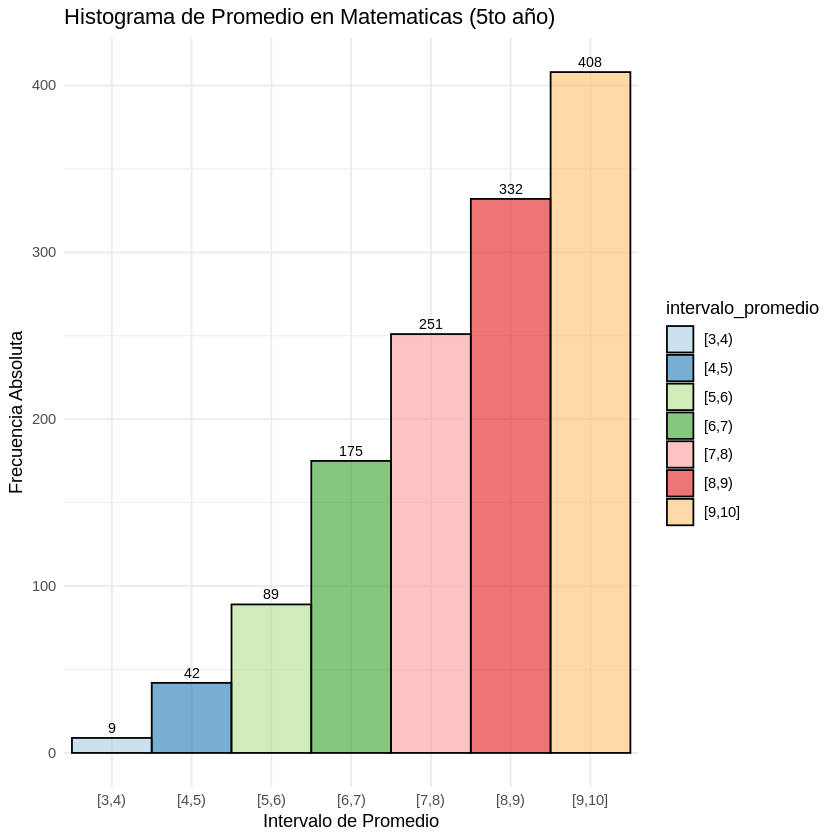

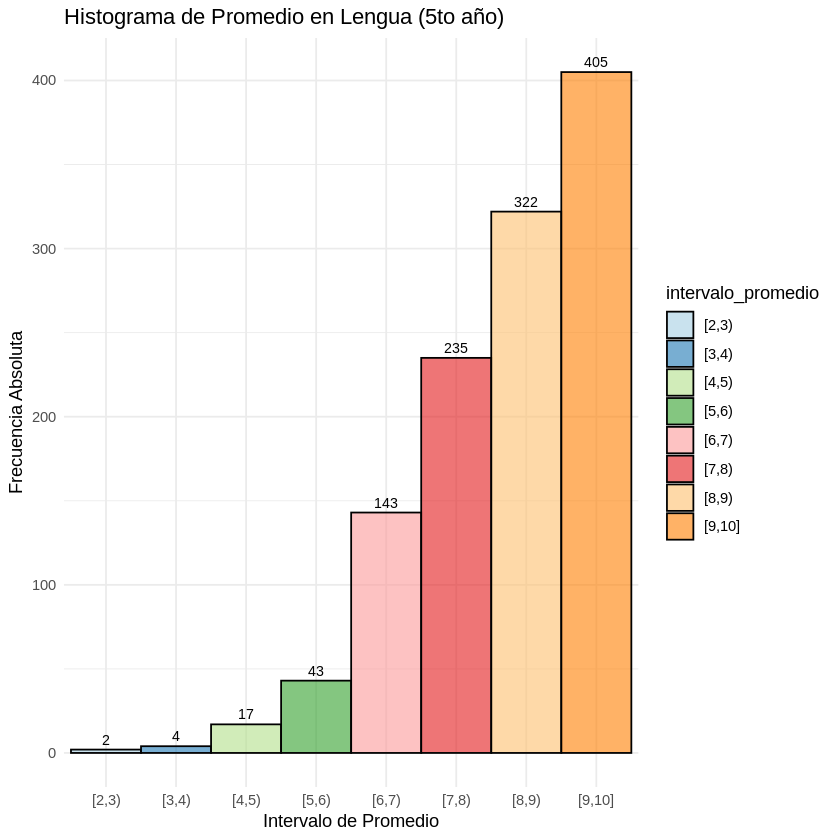

In [ ]:
# Creamos los Histogramas de Frecuencias Acumuladas:

ggplot(tabla_frecuencias_mates5, aes(x = intervalo_promedio, y = Frecuencia_Absoluta_Acumulada, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta_Acumulada), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Matematicas (5to año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

ggplot(tabla_frecuencias_lengua5, aes(x = intervalo_promedio, y = Frecuencia_Absoluta_Acumulada, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta_Acumulada), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Lengua (5to año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

### 6to Año Matematica y Lengua:

In [ ]:
# primero segmentamos las materias Matematicas y Lengua en 2do año:

library(dplyr)
library(ggplot2)

# Combinar divisiones en una nueva columna
datos_matematicas_6o <- datos_matematicas %>%
  filter(curso == "6to Secundaria") %>%
  mutate(division_agrupada = "6to Año")

datos_lengua_6o <- datos_lengua %>%
  filter(curso == "6to Secundaria") %>%
  mutate(division_agrupada = "6to Año")

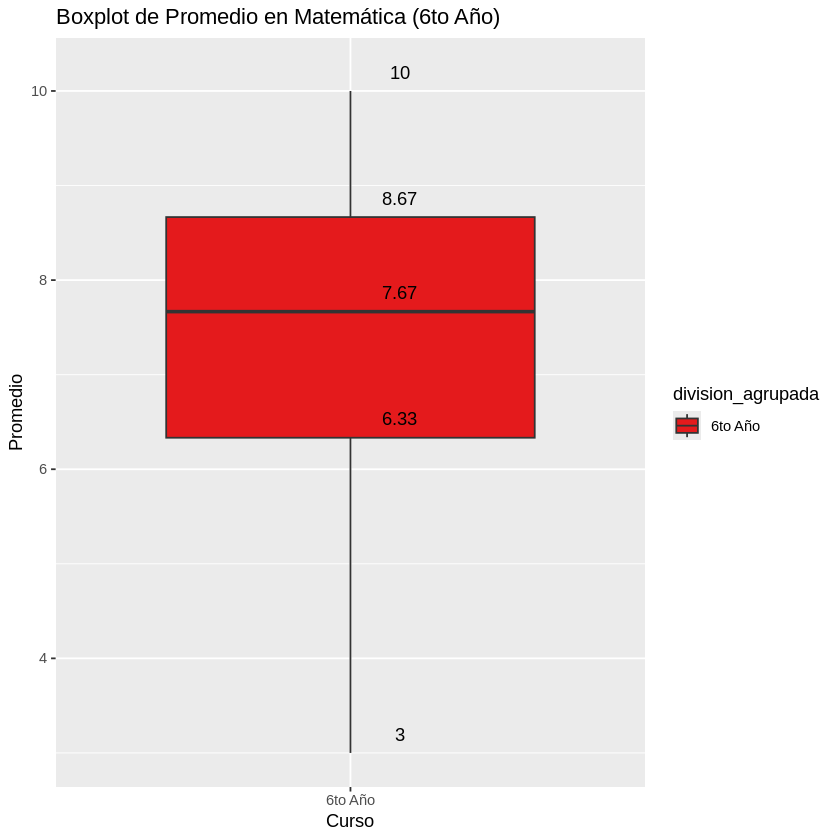

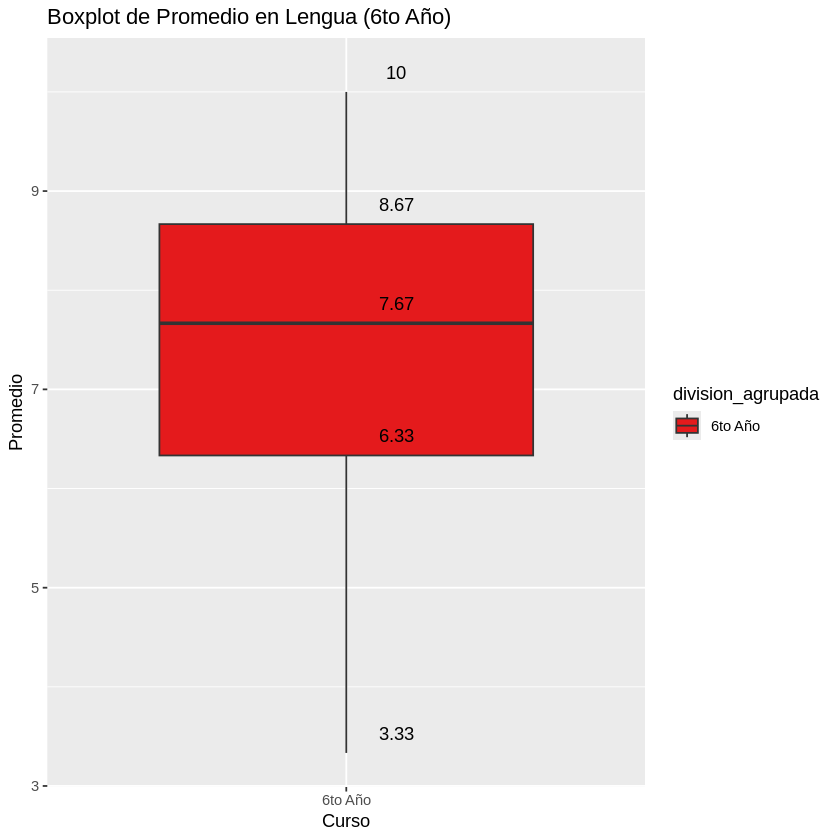

In [ ]:
# Crear los boxplots con modificaciones
plot_matematica6 <- ggplot(datos_matematicas_6o, aes(x = division_agrupada, y = Promedio, fill = division_agrupada)) +
  geom_boxplot() +  # Quitamos notch = TRUE para eliminar las muescas
  # Quitamos geom_jitter() para eliminar los puntos
  scale_fill_brewer(palette = "Set1") +  # Usar paleta de colores "Set1"
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),  # Agregar etiquetas con dos decimales
               position = position_nudge(x = 0.1, y = 0.2)) +  # Ajustar posición de etiquetas
  labs(title = "Boxplot de Promedio en Matemática (6to Año)",
       x = "Curso",
       y = "Promedio")

plot_lengua6 <- ggplot(datos_lengua_6o, aes(x = division_agrupada, y = Promedio, fill = division_agrupada)) +
  geom_boxplot() +  # Quitamos notch = TRUE para eliminar las muescas
  # Quitamos geom_jitter() para eliminar los puntos
  scale_fill_brewer(palette = "Set1") +  # Usar paleta de colores "Set1"
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),  # Agregar etiquetas con dos decimales
               position = position_nudge(x = 0.1, y = 0.2)) +  # Ajustar posición de etiquetas
  labs(title = "Boxplot de Promedio en Lengua (6to Año)",
       x = "Curso",
       y = "Promedio")

print(plot_matematica6)
print(plot_lengua6)

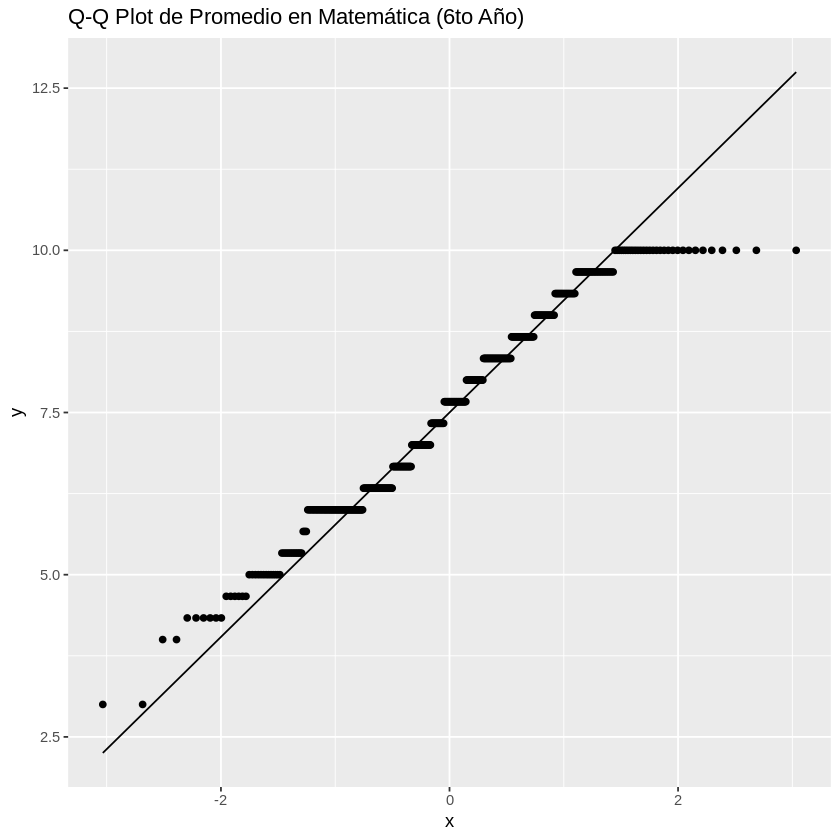

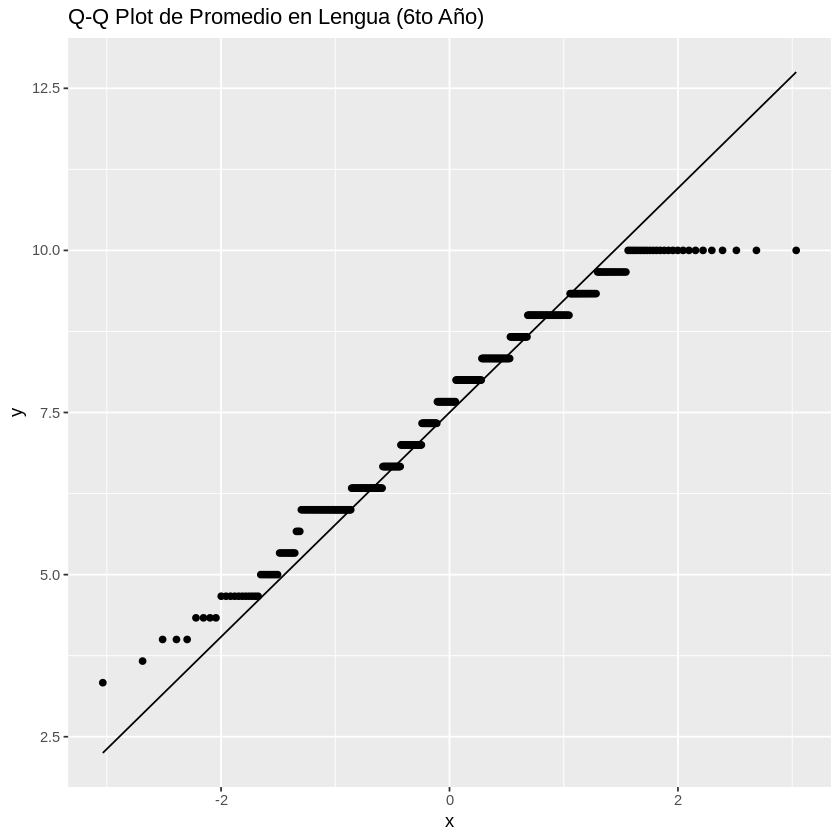

In [ ]:
# Respondemos la Actividad 2 de la Guia 3:¿La distribución es simétrica? Si es asimétrica, ¿la asimetría es a derecha o a izquierda? ¿Qué quiere decir eso?

if(!require(ggplot2)){
  install.packages("ggplot2")
}
library(ggplot2)

# Crear el gráfico Q-Q plot Matematica
ggplot(datos_matematicas_6o, aes(sample = Promedio)) +
  stat_qq() +
  stat_qq_line() +
  labs(title = "Q-Q Plot de Promedio en Matemática (6to Año)")

# Crear el gráfico Q-Q plot Lengua
ggplot(datos_lengua_6o, aes(sample = Promedio)) +
  stat_qq() +
  stat_qq_line() +
  labs(title = "Q-Q Plot de Promedio en Lengua (6to Año)")

In [ ]:
# Realizar la prueba de Kolmogorov-Smirnov
ks.test(datos_matematicas_6o$Promedio, "pnorm")

# Realizar la prueba de Kolmogorov-Smirnov
ks.test(datos_lengua_6o$Promedio, "pnorm")


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  datos_matematicas_6o$Promedio
D = 0.99865, p-value < 2.2e-16
alternative hypothesis: two-sided



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  datos_lengua_6o$Promedio
D = 0.99957, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
# Estandarizar la variable "Promedio" en Matemática de 6to año
datos_matematicas_6o$Promedio_Estandarizado <- scale(datos_matematicas_6o$Promedio)

# Estandarizar la variable "Promedio" en Lengua de 6to año
datos_lengua_6o$Promedio_Estandarizado <- scale(datos_lengua_6o$Promedio)

# Test de Lilliefors para Promedio Estandarizado en Matemática
lillie.test(datos_matematicas_6o$Promedio_Estandarizado)

# Test de Lilliefors para Promedio Estandarizado en Lengua
lillie.test(datos_lengua_6o$Promedio_Estandarizado)


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  datos_matematicas_6o$Promedio_Estandarizado
D = 0.087165, p-value = 5.405e-08



	Lilliefors (Kolmogorov-Smirnov) normality test

data:  datos_lengua_6o$Promedio_Estandarizado
D = 0.092114, p-value = 5.029e-09


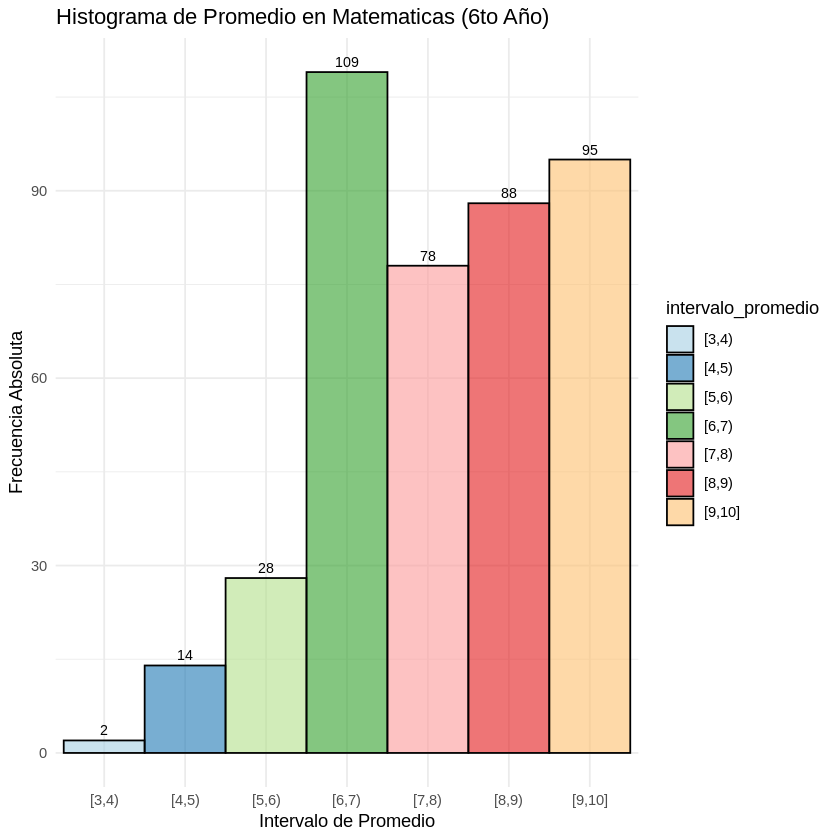

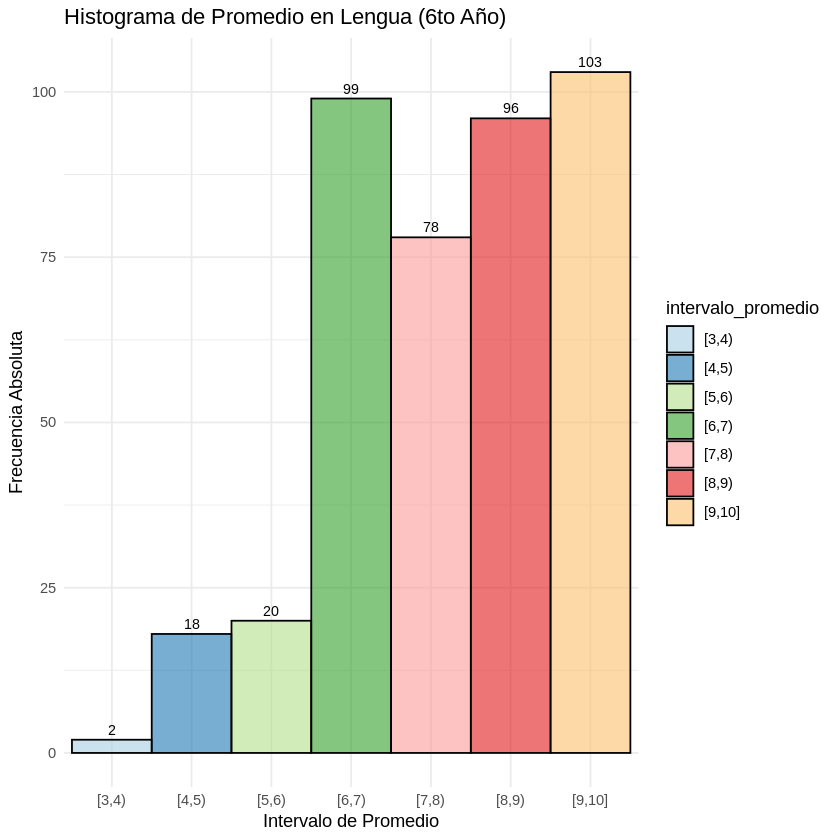

In [ ]:
# ¿Cuáles son las notas más frecuentes? ¿Y las menos frecuentes?

# Creamos la tabla de frecuencia con sus intervalos

# Definir los intervalos (bins)
breaks <- seq(1, 10, by = 1) # Intervalos de 1 en 1 desde 1 hasta 10

# Crear una nueva columna con los intervalos
datos_matematicas6 <- datos_matematicas_6o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

datos_lengua6 <- datos_lengua_6o %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE,right = FALSE))

# Crear tabla de frecuencias por intervalos (sin agrupar por division)
tabla_frecuencias_mates6 <- datos_matematicas6 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

tabla_frecuencias_lengua6 <- datos_lengua6 %>%
  group_by(intervalo_promedio) %>%  # Agrupar solo por intervalo
  summarise(Frecuencia_Absoluta = n()) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

# Creamos los Histogramas

ggplot(tabla_frecuencias_mates6, aes(x = intervalo_promedio, y = Frecuencia_Absoluta, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Matematicas (6to Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

ggplot(tabla_frecuencias_lengua6, aes(x = intervalo_promedio, y = Frecuencia_Absoluta, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Lengua (6to Año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

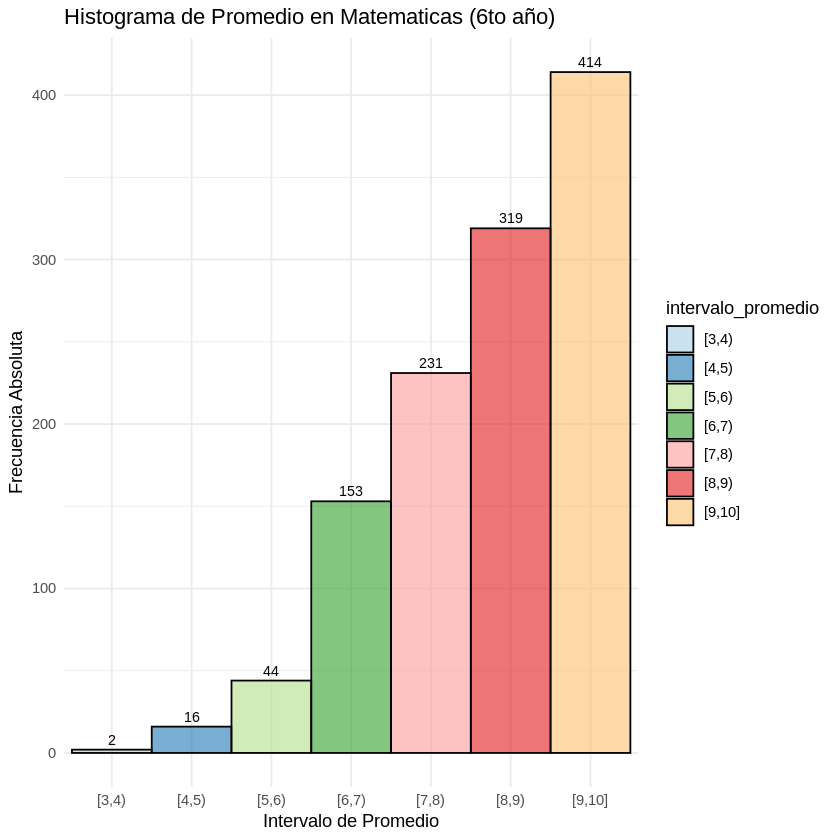

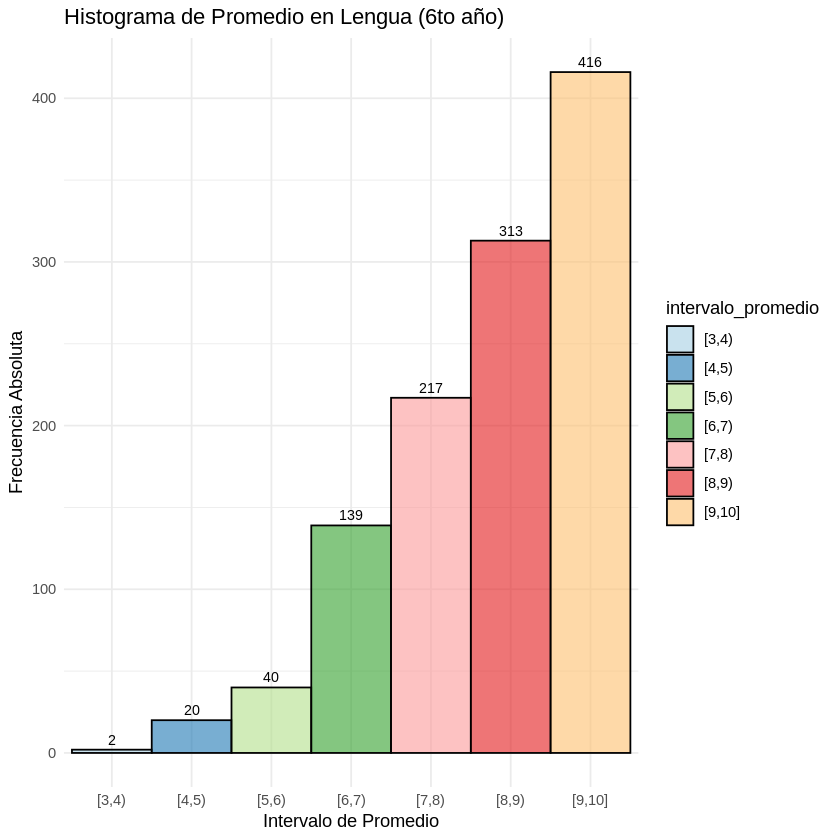

In [ ]:
# Creamos los Histogramas de Frecuencias Acumuladas:

ggplot(tabla_frecuencias_mates6, aes(x = intervalo_promedio, y = Frecuencia_Absoluta_Acumulada, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta_Acumulada), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Matematicas (6to año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

ggplot(tabla_frecuencias_lengua6, aes(x = intervalo_promedio, y = Frecuencia_Absoluta_Acumulada, fill = intervalo_promedio)) +
  geom_bar(stat = "identity", alpha = 0.6, width = 1, color = "black") +
  geom_text(aes(label = Frecuencia_Absoluta_Acumulada), vjust = -0.5, size = 3) + # Etiquetas con frecuencia absoluta
  labs(title = "Histograma de Promedio en Lengua (6to año)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")

# Contestamos otras preguntas (Guia 4):

Loading required package: tidyr



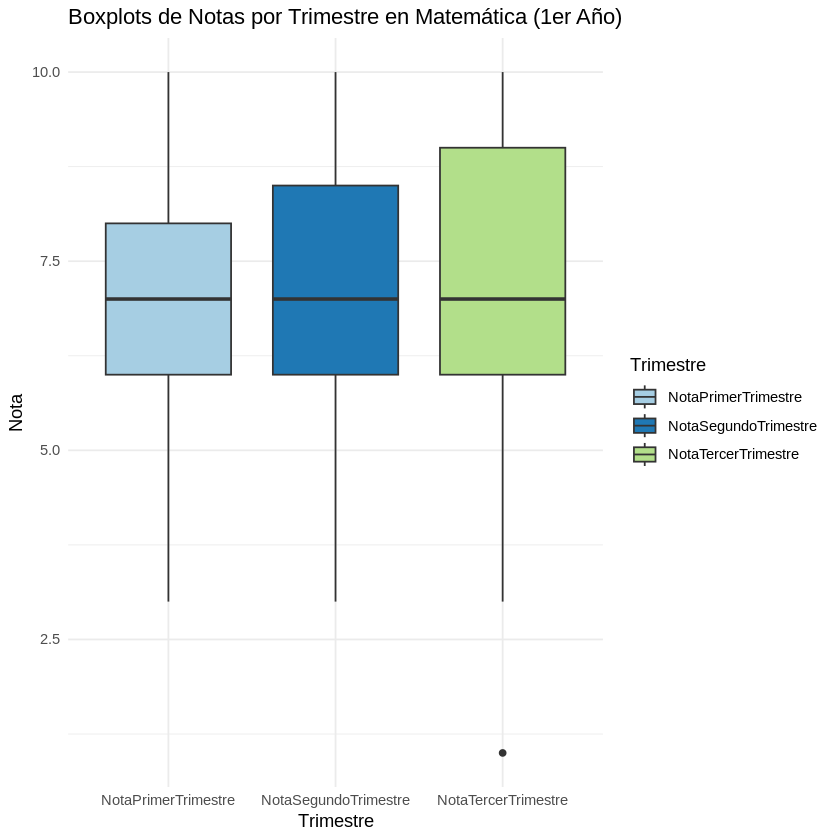

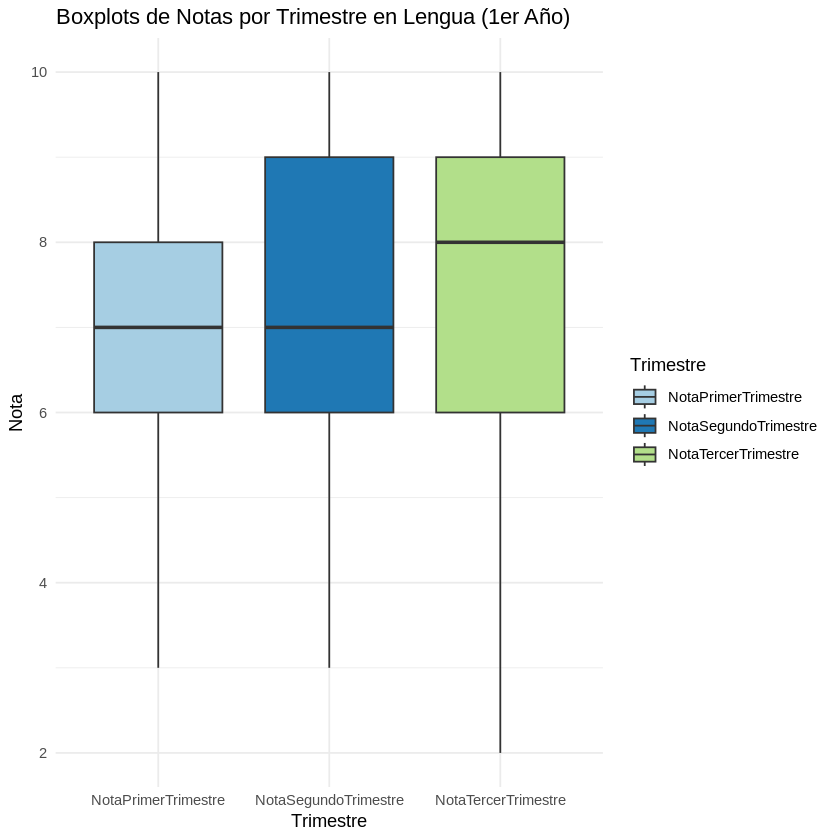

In [ ]:
# ¿Cuál es la nota por trimestre?

# Instalar tidyr si es necesario
if (!require(tidyr)) install.packages("tidyr", version = "1.3.0")
library(tidyr)

if (!require(ggplot2)) install.packages("ggplot2", version = "3.4.2")
library(ggplot2)

# Convertir datos a formato largo
datos_matematicas_1o_largo <- datos_matematicas_1o %>%
  pivot_longer(
    cols = c(NotaPrimerTrimestre, NotaSegundoTrimestre, NotaTercerTrimestre),
    names_to = "Trimestre",
    values_to = "Nota"
  )

# Crear el boxplot
ggplot(datos_matematicas_1o_largo, aes(x = Trimestre, y = Nota, fill = Trimestre)) +
  geom_boxplot() +
  labs(title = "Boxplots de Notas por Trimestre en Matemática (1er Año)",
       x = "Trimestre",
       y = "Nota") +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")  # Usar paleta de colores "Paired"

# Convertir datos a formato largo
datos_lengua_1o_largo <- datos_lengua_1o %>%
  pivot_longer(
    cols = c(NotaPrimerTrimestre, NotaSegundoTrimestre, NotaTercerTrimestre),
    names_to = "Trimestre",
    values_to = "Nota"
  )

# Crear el boxplot
ggplot(datos_lengua_1o_largo, aes(x = Trimestre, y = Nota, fill = Trimestre)) +
  geom_boxplot() +
  labs(title = "Boxplots de Notas por Trimestre en Lengua (1er Año)",
       x = "Trimestre",
       y = "Nota") +
  theme_minimal() +
  scale_fill_brewer(palette = "Paired")  # Usar paleta de colores "Paired"

In [ ]:
#Si un estudiante de tercer año en una escuela de tu departamento tiene un promedio de 4 en Matemáticas, ¿cómo se compara su desempeño con los puntajes obtenidos en su curso si...
# a) asiste a una escuela secundaria pública común?
# b) asiste a una escuela secundaria privada común?
# c) asiste a una escuela secundaria técnica? (en informe comparamos con el estudio de la tecnica)


# Filtrar datos para estudiantes de tercer año en Matemáticas
datos_matematicas_3o <- datos_matematicas %>%
  filter(curso == "3ro Secundaria") %>%
  mutate(division_agrupada = "3ro Año")

# Filtrar por tipo de escuela
publica <- datos_matematicas_3o %>% filter(EsPrivada == "N")
privada <- datos_matematicas_3o %>% filter(EsPrivada == "S")
# No hay datos para escuela secundaria técnica, por lo que usaremos solo de una escuela pública o privada.

# Calcular la puntuación z para el promedio de 4 en cada tipo de escuela
z_publica <- (4 - mean(publica$Promedio)) / sd(publica$Promedio)
z_privada <- (4 - mean(privada$Promedio)) / sd(privada$Promedio)

# Mostrar los resultados
cat("Puntuación z para escuela pública:", z_publica, "\n")
cat("Puntuación z para escuela privada:", z_privada, "\n")

# Interpretar los resultados
if (z_publica < 0) {
  cat("El estudiante está por debajo de la media en escuelas públicas.\n")
} else if (z_publica > 0) {
  cat("El estudiante está por encima de la media en escuelas públicas.\n")
} else {
  cat("El estudiante está cerca de la media en escuelas públicas.\n")
}
if (z_privada < 0) {
  cat("El estudiante está por debajo de la media en escuelas privadas.\n")
} else if (z_privada > 0) {
  cat("El estudiante está por encima de la media en escuelas privadas.\n")
} else {
  cat("El estudiante está cerca de la media en escuelas privadas.\n")
}


Puntuación z para escuela pública: -1.549573 
Puntuación z para escuela privada: -2.081543 
El estudiante está por debajo de la media en escuelas públicas.
El estudiante está por debajo de la media en escuelas privadas.


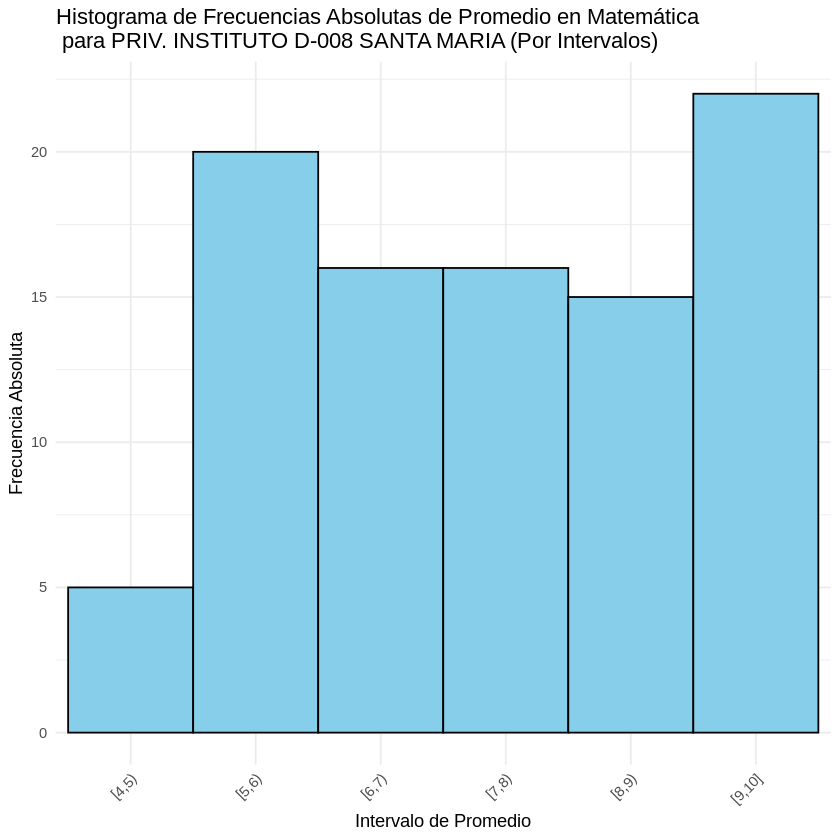

[1] -1.686774
[1] -2.065884


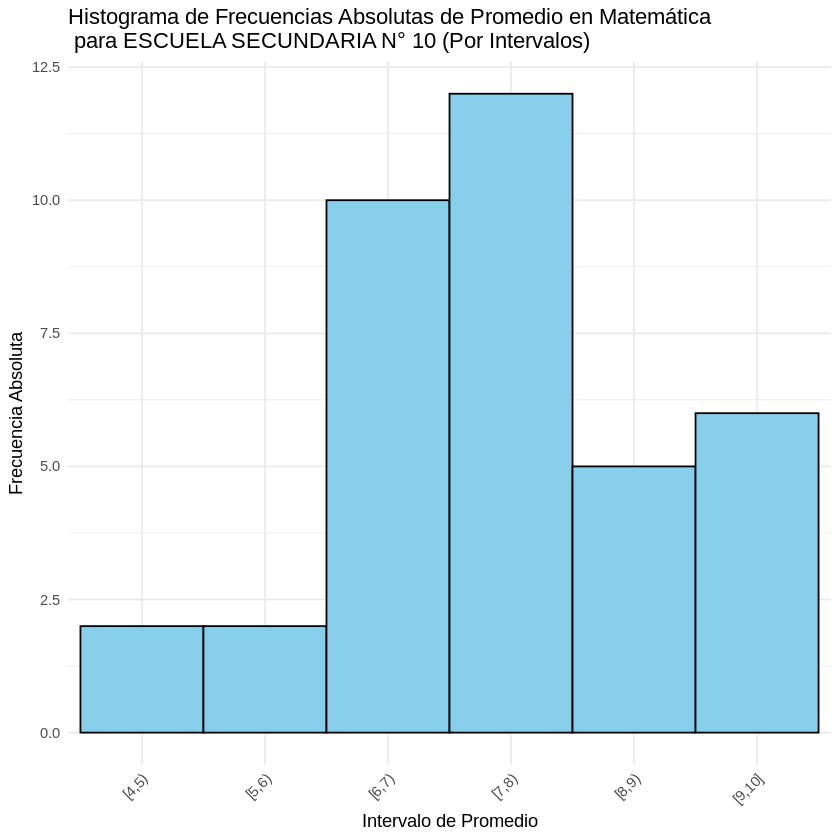

In [ ]:
# Seleccione las notas de Matemática de primer año de dos escuelas que difieran notoriamente en cantidad de estudiantes:
#  a. Construya un histograma de frecuencias absolutas para cada grupo.
#  b. Tipifique las notas de ambas escuelas.
#  c. ¿Es lo mismo obtener calificación 4 en ambas escuelas?


# Escuela con mayor cantidad de estudiantes
escuela1 <- datos_matematicas_1o %>%
  filter(suborganizacion == "PRIV. INSTITUTO D-008 SANTA MARIA")

# Escuela con menor cantidad de estudiantes
escuela2 <- datos_matematicas_1o %>%
  filter(suborganizacion == "ESCUELA SECUNDARIA N° 10")

# Definir los intervalos (bins) ################## ESCUELA 1 #######################
breaks <- seq(1, 10, by = 1) # Intervalos de 1 en 1 desde 1 hasta 10

# Crear una nueva columna con los intervalos
escuela1 <- escuela1 %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE, right = FALSE))

# Crear tabla de frecuencias por intervalos
tabla_frecuencias_escuela1 <- escuela1 %>%
  group_by(intervalo_promedio) %>%  # Agrupar por intervalo
  summarise(Frecuencia_Absoluta = n())

# Crear histograma
ggplot(tabla_frecuencias_escuela1, aes(x = intervalo_promedio, y = Frecuencia_Absoluta)) +
  geom_bar(stat = "identity", fill = "skyblue", color = "black", width=1) +
  labs(title = "Histograma de Frecuencias Absolutas de Promedio en Matemática \n para PRIV. INSTITUTO D-008 SANTA MARIA (Por Intervalos)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) # Rotar etiquetas del eje x

# Definir los intervalos (bins) ################## ESCUELA 2 #######################
breaks <- seq(1, 10, by = 1) # Intervalos de 1 en 1 desde 1 hasta 10

# Crear una nueva columna con los intervalos
escuela2 <- escuela2 %>%
  mutate(intervalo_promedio = cut(Promedio, breaks = breaks, include.lowest = TRUE, right = FALSE))

# Crear tabla de frecuencias por intervalos
tabla_frecuencias_escuela2 <- escuela2 %>%
  group_by(intervalo_promedio) %>%  # Agrupar por intervalo
  summarise(Frecuencia_Absoluta = n())

# Crear histograma
ggplot(tabla_frecuencias_escuela2, aes(x = intervalo_promedio, y = Frecuencia_Absoluta)) +
  geom_bar(stat = "identity", fill = "skyblue", color = "black",width = 1) +
  labs(title = "Histograma de Frecuencias Absolutas de Promedio en Matemática \n para ESCUELA SECUNDARIA N° 10 (Por Intervalos)",
       x = "Intervalo de Promedio",
       y = "Frecuencia Absoluta") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) # Rotar etiquetas del eje x

# Tipificar notas de la escuela 1
escuela1$notas_z <- scale(escuela1$Promedio)

# Tipificar notas de la escuela 2
escuela2$notas_z <- scale(escuela2$Promedio)

# Puntuación z para promedios entre 3.8 y 4.2 en la escuela 1
puntuacion_z_escuela1 <- escuela1$notas_z[escuela1$Promedio >= 3.8 & escuela1$Promedio <= 4.4]

# Puntuación z para promedios entre 3.8 y 4.2 en la escuela 2
puntuacion_z_escuela2 <- escuela2$notas_z[escuela2$Promedio >= 3.8 & escuela2$Promedio <= 4.4]

# Comparar las puntuaciones z (por ejemplo, usando la media)
print(mean(puntuacion_z_escuela1))
print(mean(puntuacion_z_escuela2))

# Obtener una calificación de 4 no es lo mismo en ambas escuelas. Aunque en ambas escuelas la calificación de 4 está por debajo de la media, en la escuela con 37 registros la calificación está aún más alejada de la media que en la escuela con 96 registros. Esto significa que, en términos relativos a sus compañeros, un estudiante que obtiene un 4 en la escuela con 37 registros ha tenido un desempeño inferior en comparación con un estudiante que obtiene un 4 en la escuela con 96 registros.

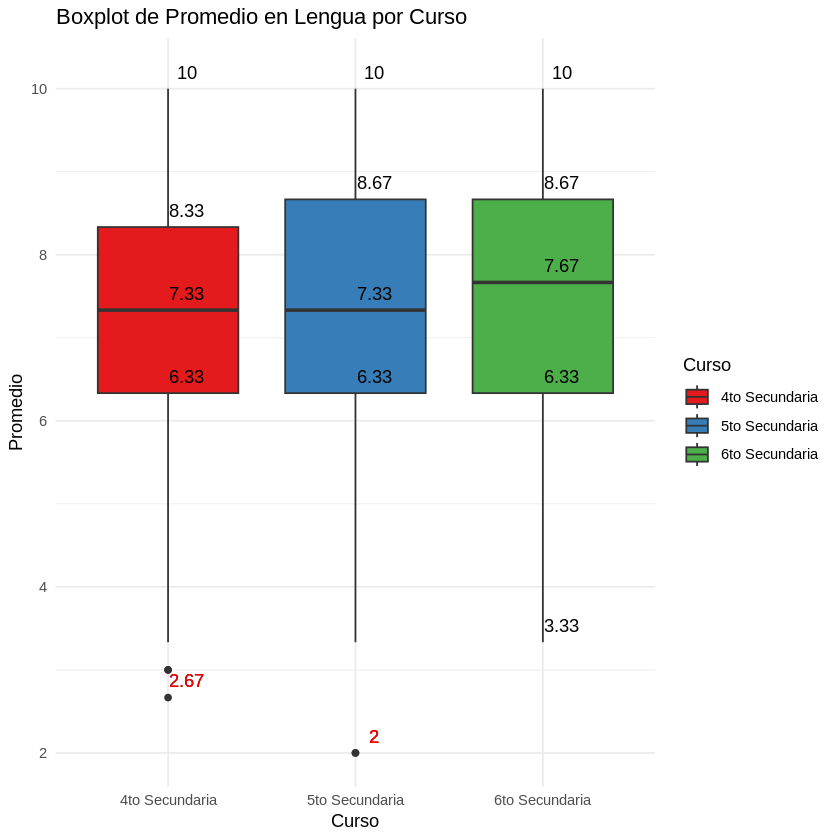

In [ ]:
# Instalar ggplot2 si es necesario
if (!require(ggplot2)) install.packages("ggplot2")

# Cargar la librería ggplot2
library(ggplot2)

# Combinar los dataframes en uno solo
datos_combinados <- rbind(
  data.frame(Curso = "4to Secundaria", Promedio = datos_lengua_4o$Promedio),
  data.frame(Curso = "5to Secundaria", Promedio = datos_lengua_5o$Promedio),
  data.frame(Curso = "6to Secundaria", Promedio = datos_lengua_6o$Promedio)
)

# Crear el gráfico de boxplot
ggplot(datos_combinados, aes(x = Curso, y = Promedio, fill = Curso)) +
  geom_boxplot() +
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),  # Agregar etiquetas con dos decimales
               position = position_nudge(x = 0.1, y = 0.2)) +  # Ajustar posición de etiquetas
  geom_text(data = subset(datos_combinados, Promedio %in% boxplot.stats(Promedio)$out),
            aes(label = round(Promedio, digits = 2)),  # Mostrar valores de outliers
            position = position_nudge(x = 0.1, y = 0.2),
            color = "red") +  # Color rojo para outliers
  labs(title = "Boxplot de Promedio en Lengua por Curso",
       x = "Curso",
       y = "Promedio") +
  theme_minimal() +
  scale_fill_brewer(palette = "Set1")  # Paleta de colores (opcional)

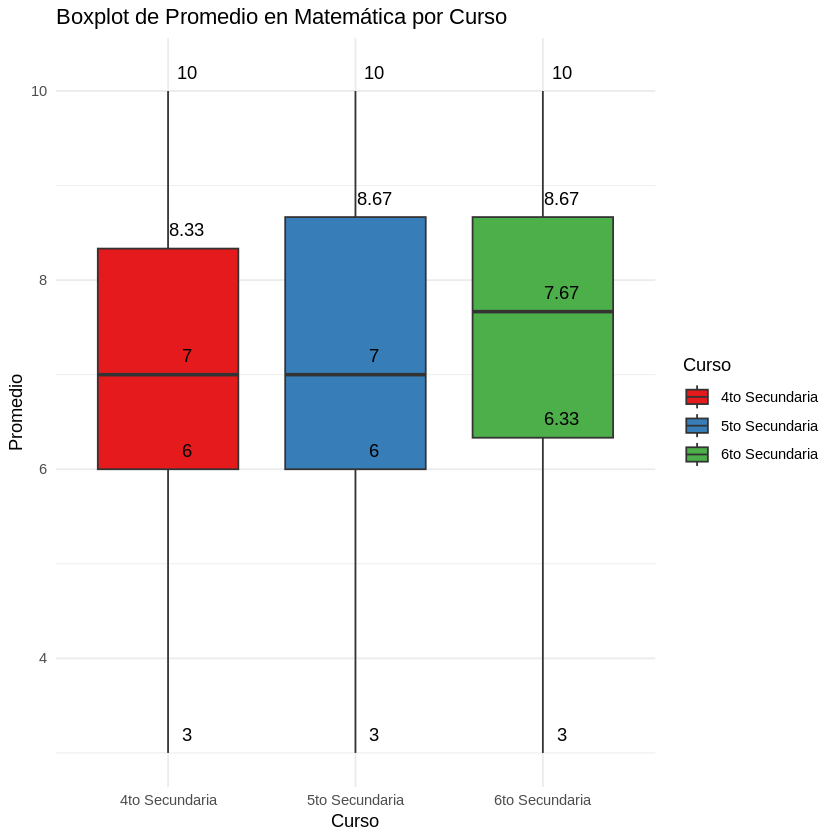

In [ ]:
# Instalar ggplot2 si es necesario
if (!require(ggplot2)) install.packages("ggplot2")

# Cargar la librería ggplot2
library(ggplot2)

# Combinar los dataframes en uno solo
datos_combinados_matematica <- rbind(
  data.frame(Curso = "4to Secundaria", Promedio = datos_matematicas_4o$Promedio),
  data.frame(Curso = "5to Secundaria", Promedio = datos_matematicas_5o$Promedio),
  data.frame(Curso = "6to Secundaria", Promedio = datos_matematicas_6o$Promedio)
)

# Crear el gráfico de boxplot para Matemática
ggplot(datos_combinados_matematica, aes(x = Curso, y = Promedio, fill = Curso)) +
  geom_boxplot() +
  stat_summary(fun = "quantile",
               geom = "text",
               aes(label = round(..y.., digits = 2)),
               position = position_nudge(x = 0.1, y = 0.2)) +
  geom_text(data = subset(datos_combinados_matematica, Promedio %in% boxplot.stats(Promedio)$out),
            aes(label = round(Promedio, digits = 2)),
            position = position_nudge(x = 0.1, y = 0.2),
            color = "red") +
  labs(title = "Boxplot de Promedio en Matemática por Curso",
       x = "Curso",
       y = "Promedio") +
  theme_minimal() +
  scale_fill_brewer(palette = "Set1")

# Preguntas sobre Correlacion (Guia 5):

### Una vez que verificamos la normalidad ya podemos seguir investigando si existe correlacion entre variables. En este caso continuaremos analizando Lengua y Matematica:

`geom_smooth()` using formula = 'y ~ x'


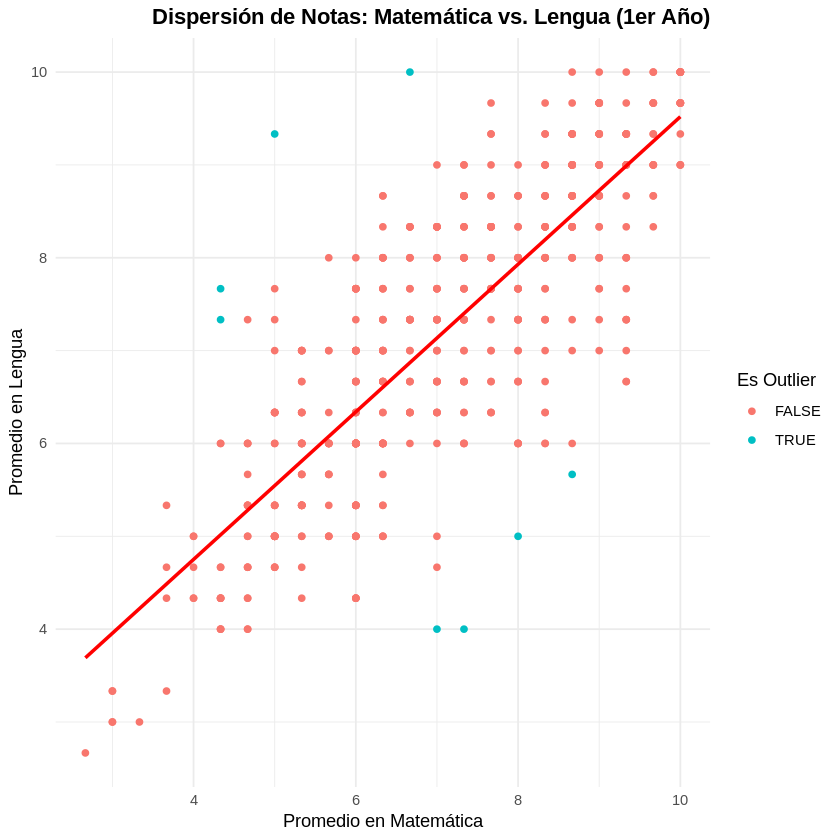

In [ ]:
# Empezamos comparando 1er año de Lengua y Matematicas:

library(dplyr)
library(ggplot2)

datos_combinados_1o <- inner_join(datos_matematicas_1o, datos_lengua_1o, by = "Documento", suffix = c("_mat", "_len"))

# Calcular distancia de Mahalanobis *antes* del mutate
mahalanobis_distance <- mahalanobis(datos_combinados_1o[, c("Promedio_mat", "Promedio_len")],
                                    colMeans(datos_combinados_1o[, c("Promedio_mat", "Promedio_len")]),
                                    cov(datos_combinados_1o[, c("Promedio_mat", "Promedio_len")]))

# Umbral para outliers
threshold <- qchisq(0.99, df = 2)

# Ahora sí, usar mahalanobis_distance en el mutate
datos_combinados_1o <- datos_combinados_1o %>%
  mutate(es_outlier = ifelse(mahalanobis_distance > threshold, TRUE, FALSE))

# Gráfico
ggplot(datos_combinados_1o, aes(x = Promedio_mat, y = Promedio_len, color = es_outlier)) +
  geom_point() +
  labs(title = "Dispersión de Notas: Matemática vs. Lengua (1er Año)",
       x = "Promedio en Matemática",
       y = "Promedio en Lengua",
       color = "Es Outlier") +
  theme_minimal()+
  theme(
    plot.title = element_text(hjust = 1, face = "bold")  # Ajustes del título
  ) +
  geom_smooth(method = "lm", se = FALSE, color = "red")

`geom_smooth()` using formula = 'y ~ x'


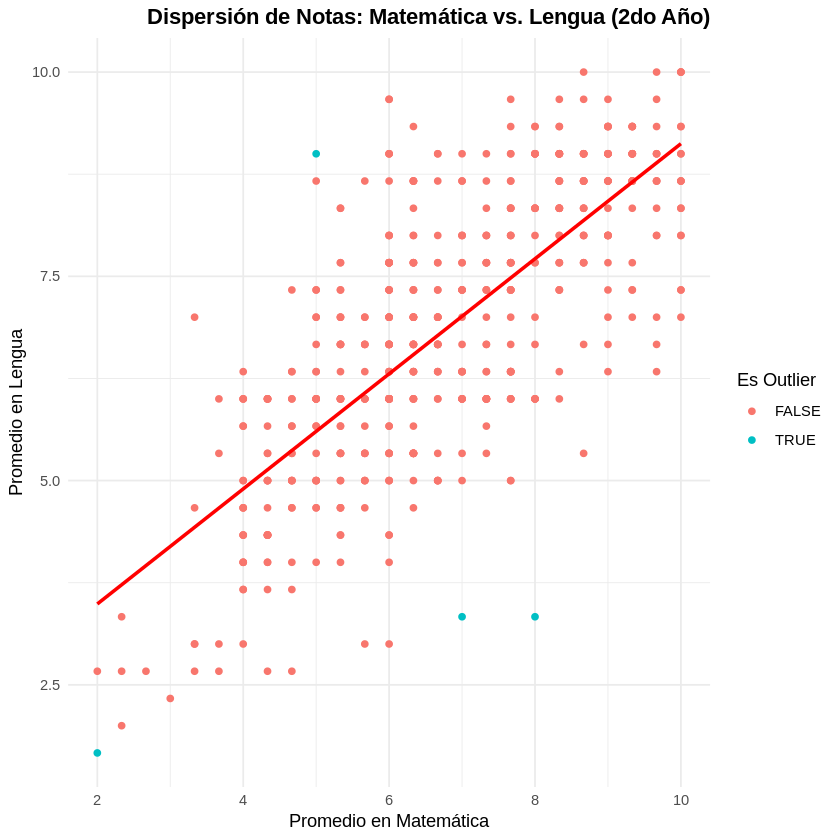

In [ ]:
# Avanzamos con Segundo año:

library(dplyr)
library(ggplot2)

datos_combinados_2o <- inner_join(datos_matematicas_2o, datos_lengua_2o, by = "Documento", suffix = c("_mat", "_len"))

# Calcular distancia de Mahalanobis *antes* del mutate
mahalanobis_distance2 <- mahalanobis(datos_combinados_2o[, c("Promedio_mat", "Promedio_len")],
                                    colMeans(datos_combinados_2o[, c("Promedio_mat", "Promedio_len")]),
                                    cov(datos_combinados_2o[, c("Promedio_mat", "Promedio_len")]))

# Umbral para outliers
threshold <- qchisq(0.99, df = 2)

# Ahora sí, usar mahalanobis_distance en el mutate
datos_combinados_2o <- datos_combinados_2o %>%
  mutate(es_outlier = ifelse(mahalanobis_distance2 > threshold, TRUE, FALSE))

# Gráfico
ggplot(datos_combinados_2o, aes(x = Promedio_mat, y = Promedio_len, color = es_outlier)) +
  geom_point() +
  labs(title = "Dispersión de Notas: Matemática vs. Lengua (2do Año)",
       x = "Promedio en Matemática",
       y = "Promedio en Lengua",
       color = "Es Outlier") +
  theme_minimal()+
  theme(
    plot.title = element_text(hjust = 1, face = "bold")  # Ajustes del título
  ) +
  geom_smooth(method = "lm", se = FALSE, color = "red")

`geom_smooth()` using formula = 'y ~ x'


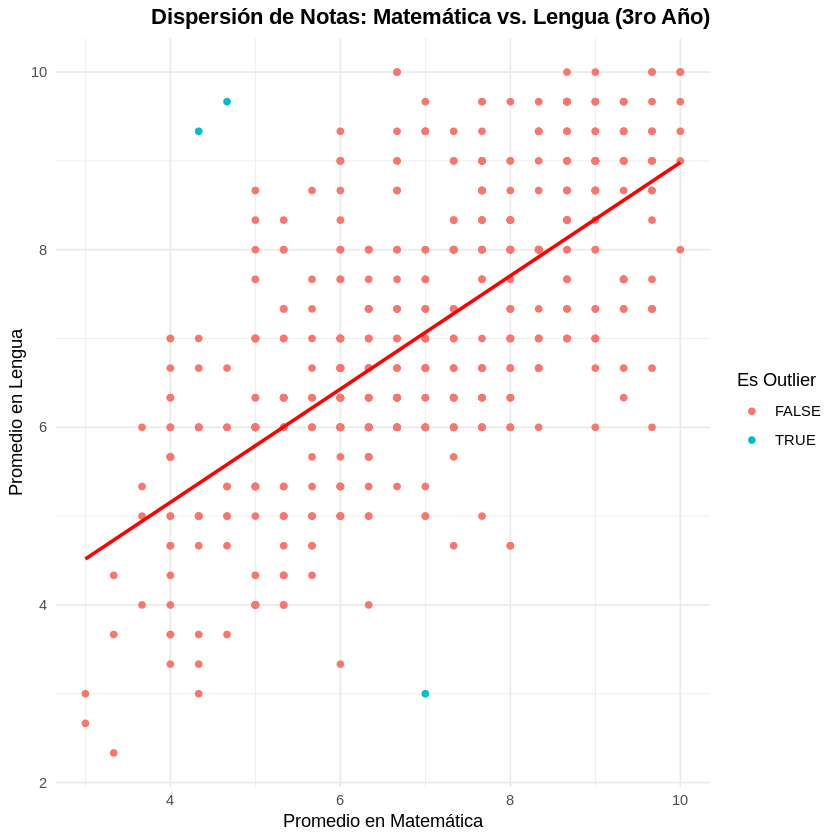

In [ ]:
# Avanzamos con Tercer año:

library(dplyr)
library(ggplot2)

datos_combinados_3o <- inner_join(datos_matematicas_3o, datos_lengua_3o, by = "Documento", suffix = c("_mat", "_len"))

# Calcular distancia de Mahalanobis *antes* del mutate
mahalanobis_distance3 <- mahalanobis(datos_combinados_3o[, c("Promedio_mat", "Promedio_len")],
                                    colMeans(datos_combinados_3o[, c("Promedio_mat", "Promedio_len")]),
                                    cov(datos_combinados_3o[, c("Promedio_mat", "Promedio_len")]))

# Umbral para outliers
threshold <- qchisq(0.99, df = 2)

# Ahora sí, usar mahalanobis_distance en el mutate
datos_combinados_3o <- datos_combinados_3o %>%
  mutate(es_outlier = ifelse(mahalanobis_distance3 > threshold, TRUE, FALSE))

# Gráfico
ggplot(datos_combinados_3o, aes(x = Promedio_mat, y = Promedio_len, color = es_outlier)) +
  geom_point() +
  labs(title = "Dispersión de Notas: Matemática vs. Lengua (3ro Año)",
       x = "Promedio en Matemática",
       y = "Promedio en Lengua",
       color = "Es Outlier") +
  theme_minimal()+
  theme(
    plot.title = element_text(hjust = 1, face = "bold")  # Ajustes del título
  ) +
  geom_smooth(method = "lm", se = FALSE, color = "red")

`geom_smooth()` using formula = 'y ~ x'


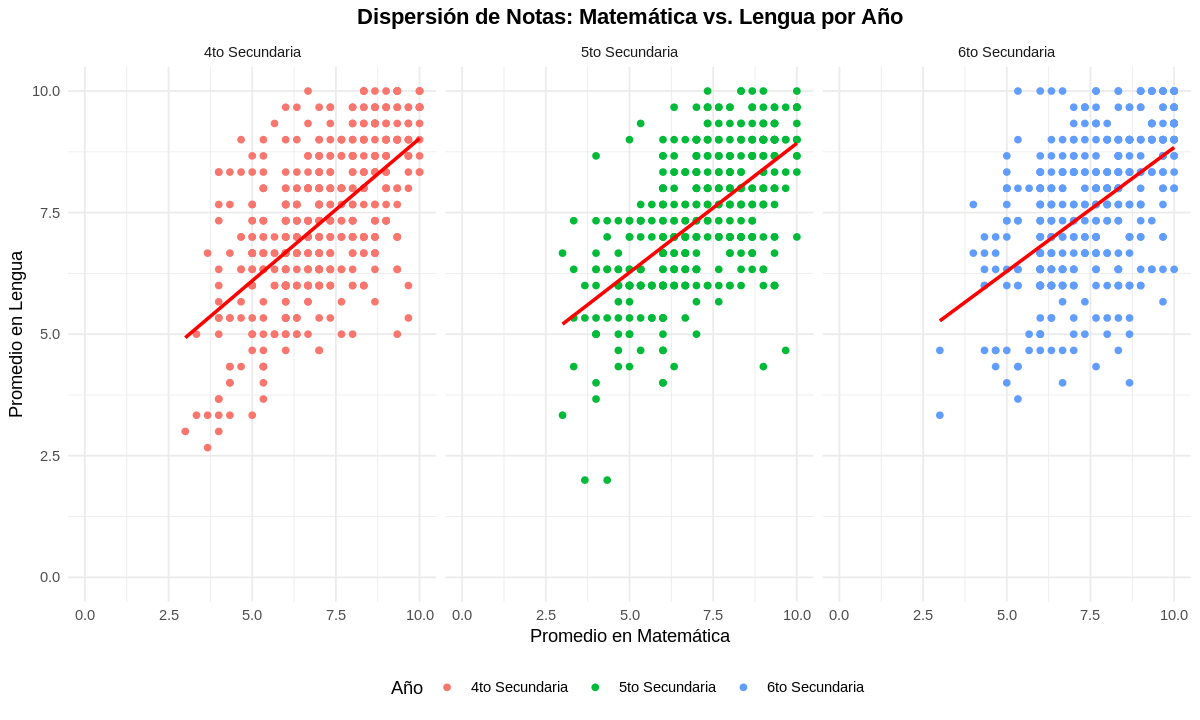

In [ ]:
# Avanzamos ahora con los años que nos quedan pendientes:

library(dplyr)
library(ggplot2)

# Establecer las dimensiones del dispositivo gráfico
options(repr.plot.width = 10, repr.plot.height = 6)  # Ajusta las dimensiones según tu preferencia (en pulgadas)

# Función para procesar los datos de un año específico
procesar_datos_anio <- function(anio) {
  datos_matematicas_anio <- datos_matematicas %>%
    filter(curso == anio) %>%
    mutate(division_agrupada = anio)

  datos_lengua_anio <- datos_lengua %>%
    filter(curso == anio) %>%
    mutate(division_agrupada = anio)

  datos_combinados_anio <- inner_join(datos_matematicas_anio, datos_lengua_anio, by = "Documento", suffix = c("_mat", "_len")) %>%
    mutate(curso = anio)  # Agregar columna con el año

  return(datos_combinados_anio)
}

# Procesar datos para cada año
datos_4o <- procesar_datos_anio("4to Secundaria")
datos_5o <- procesar_datos_anio("5to Secundaria")
datos_6o <- procesar_datos_anio("6to Secundaria")


# Combinar todos los datos
todos_los_anios <- bind_rows( datos_4o, datos_5o, datos_6o)

# Crear el gráfico con facets
ggplot(todos_los_anios, aes(x = Promedio_mat, y = Promedio_len, color = curso)) +  # Agregar color por año
  geom_point(size = 1.5) +  # Ajustar tamaño de los puntos
  labs(title = "Dispersión de Notas: Matemática vs. Lengua por Año",
       x = "Promedio en Matemática",
       y = "Promedio en Lengua",
       color = "Año") +  # Agregar leyenda para el color
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),  # Ajustes del título
    legend.position = "bottom"  # Mover la leyenda abajo
  ) +
  facet_wrap(~ curso) +  # Crear facets por año (curso)
  xlim(0, 10) + ylim(0, 10) +
  geom_smooth(method = "lm", se = FALSE, color = "red")   # Ajustar límites de los ejes (opcional)

### Ahora debemos hacer Correlaciones parciales para ver como se correlacionan las variables entre años

In [ ]:
# Hacemos correlaciones entre las variables y los promedios

# Combinar los dataframes por la columna "Documento"
datos_combinados1 <- merge(datos_matematicas_1o, datos_lengua_1o, by = "Documento")
datos_combinados2 <- merge(datos_matematicas_2o, datos_lengua_2o, by = "Documento")
datos_combinados3 <- merge(datos_matematicas_3o, datos_lengua_3o, by = "Documento")
datos_combinados4 <- merge(datos_matematicas_4o, datos_lengua_4o, by = "Documento")
datos_combinados5 <- merge(datos_matematicas_5o, datos_lengua_5o, by = "Documento")
datos_combinados6 <- merge(datos_matematicas_6o, datos_lengua_6o, by = "Documento")

# Calcular la correlación entre Promedio de Matemáticas y Lengua
correlacion1 <- cor(datos_combinados1$Promedio.x, datos_combinados1$Promedio.y, method = "spearman")
correlacion2 <- cor(datos_combinados2$Promedio.x, datos_combinados2$Promedio.y, method = "spearman")
correlacion3 <- cor(datos_combinados3$Promedio.x, datos_combinados3$Promedio.y, method = "spearman")
correlacion4 <- cor(datos_combinados4$Promedio.x, datos_combinados4$Promedio.y, method = "spearman")
correlacion5 <- cor(datos_combinados5$Promedio.x, datos_combinados5$Promedio.y, method = "spearman")
correlacion6 <- cor(datos_combinados6$Promedio.x, datos_combinados6$Promedio.y, method = "spearman")

# Imprimir el resultado
print(correlacion1)
print(correlacion2)
print(correlacion3)
print(correlacion4)
print(correlacion5)
print(correlacion6)

[1] 0.8020889
[1] 0.7170412
[1] 0.6562355
[1] 0.5871905
[1] 0.5988323
[1] 0.5320653


In [ ]:
# Asegúrate de que tus dataframes combinados (datos_combinados1 a datos_combinados6)
# ya estén creados y disponibles en tu entorno de Colab.

# Lista de tus dataframes combinados
lista_dataframes_combinados <- list(
  datos_combinados1,
  datos_combinados2,
  datos_combinados3,
  datos_combinados4,
  datos_combinados5,
  datos_combinados6
)

# Obtener el número de filas de cada dataframe
num_filas <- sapply(lista_dataframes_combinados, nrow)

# Encontrar el número mínimo de filas
min_filas <- min(num_filas)

# Truncar cada dataframe para que tenga el número mínimo de filas
dataframes_truncados <- lapply(lista_dataframes_combinados, function(df) {
  # Seleccionar las primeras min_filas
  df_truncado <- df[1:min_filas, ]
  return(df_truncado)
})

# Asignar los dataframes truncados de nuevo a variables individuales si es necesario
datos_combinados1_truncado <- dataframes_truncados[[1]]
datos_combinados2_truncado <- dataframes_truncados[[2]]
datos_combinados3_truncado <- dataframes_truncados[[3]]
datos_combinados4_truncado <- dataframes_truncados[[4]]
datos_combinados5_truncado <- dataframes_truncados[[5]]
datos_combinados6_truncado <- dataframes_truncados[[6]]


# Ahora, extrae las columnas de promedio de los dataframes truncados
promedios1_truncado <- datos_combinados1_truncado[, c("Promedio.x", "Promedio.y")]
promedios2_truncado <- datos_combinados2_truncado[, c("Promedio.x", "Promedio.y")]
promedios3_truncado <- datos_combinados3_truncado[, c("Promedio.x", "Promedio.y")]
promedios4_truncado <- datos_combinados4_truncado[, c("Promedio.x", "Promedio.y")]
promedios5_truncado <- datos_combinados5_truncado[, c("Promedio.x", "Promedio.y")]
promedios6_truncado <- datos_combinados6_truncado[, c("Promedio.x", "Promedio.y")]

# Combinar todas las columnas de promedios truncados en un nuevo dataframe
datos_promedios_consolidados_truncado <- cbind(
  promedios1_truncado,
  promedios2_truncado,
  promedios3_truncado,
  promedios4_truncado,
  promedios5_truncado,
  promedios6_truncado
)

# Opcional: Cambiar los nombres de las columnas para que sean más descriptivos
colnames(datos_promedios_consolidados_truncado) <- c(
  "Promedio_Matematica_1ro", "Promedio_Lengua_1ro",
  "Promedio_Matematica_2do", "Promedio_Lengua_2do",
  "Promedio_Matematica_3ro", "Promedio_Lengua_3ro",
  "Promedio_Matematica_4to", "Promedio_Lengua_4to",
  "Promedio_Matematica_5to", "Promedio_Lengua_5to",
  "Promedio_Matematica_6to", "Promedio_Lengua_6to"
)


# Para ver las primeras filas del nuevo dataframe consolidado y truncado
head(datos_promedios_consolidados_truncado)

# Para ver el número de filas del resultado
nrow(datos_promedios_consolidados_truncado)

,Promedio_Matematica_1ro,Promedio_Lengua_1ro,Promedio_Matematica_2do,Promedio_Lengua_2do,Promedio_Matematica_3ro,Promedio_Lengua_3ro,Promedio_Matematica_4to,Promedio_Lengua_4to,Promedio_Matematica_5to,Promedio_Lengua_5to,Promedio_Matematica_6to,Promedio_Lengua_6to
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,8.333333,9.333333,9.333333,9.333333,6.000000,6.666667,6,7.666667,10.000000,9.666667,7.666667,8.333333
2,9.666667,9.333333,9.333333,9.333333,9.333333,9.666667,7,7.333333,3.666667,2.000000,6.333333,6.333333
3,10.000000,9.666667,8.000000,7.666667,9.333333,9.666667,6,6.666667,7.000000,8.666667,7.666667,7.333333
4,9.333333,9.000000,9.000000,9.666667,7.000000,7.000000,6,7.333333,9.000000,9.666667,9.666667,8.333333
5,10.000000,9.666667,9.000000,9.000000,6.333333,6.333333,6,6.000000,7.666667,8.666667,8.333333,7.666667
6,10.000000,9.666667,9.000000,8.666667,6.000000,6.000000,8,8.666667,5.000000,6.333333,8.333333,8.000000


[1] 405

In [ ]:
library(dplyr)

##VERFICAMOS QUE NO HAYAN VALORES NULL

# Verificar si hay valores nulos en 'mi_columna'
hay_nulos <- any(is.na(datos_combinados1$Promedio.y))

# Imprimir el resultado
if (hay_nulos) {
  print("Hay valores nulos en la columna 'mi_columna'")
} else {
  print("No hay valores nulos en la columna 'mi_columna'")
}

[1] "No hay valores nulos en la columna 'mi_columna'"


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘quadprog’, ‘zoo’


Loading required package: xts

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from breaking base R's lag() fun

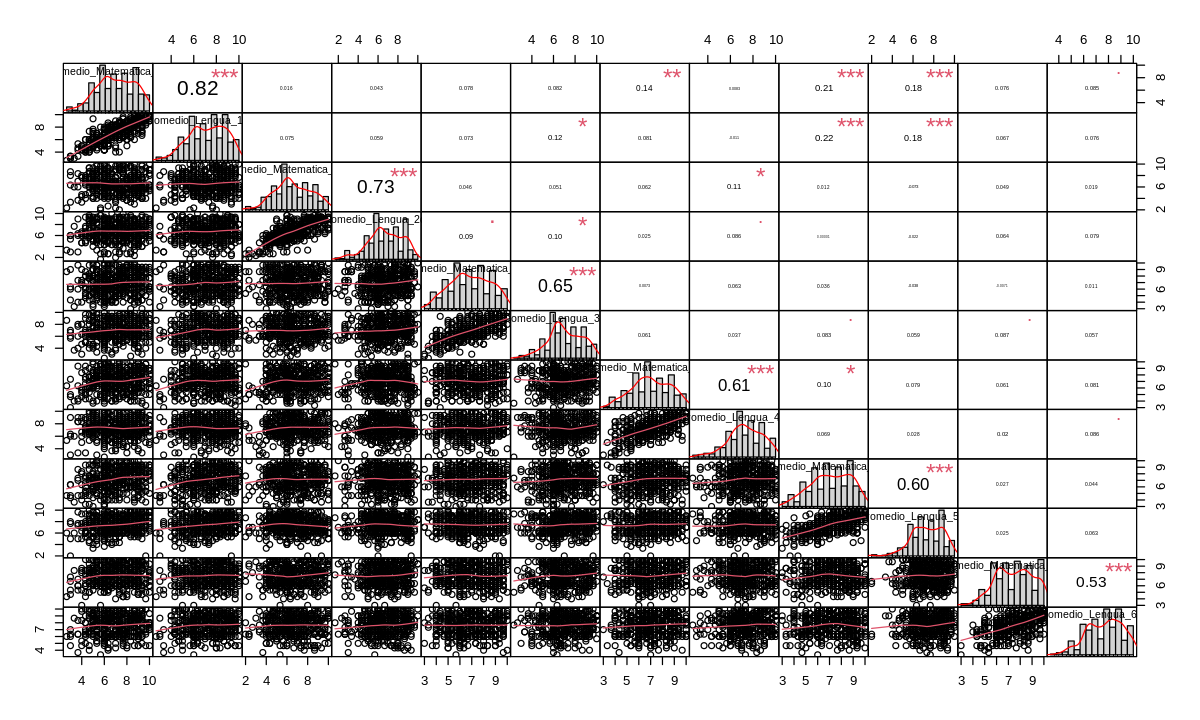

In [ ]:
# Procedemos a graficar las correlaciones:

# Asegúrate de que el dataframe datos_promedios_consolidados_truncado
# ya esté creado y disponible en tu entorno de Colab.

install.packages("PerformanceAnalytics")
library(PerformanceAnalytics)

chart.Correlation(datos_promedios_consolidados_truncado, histogram = TRUE, method = "pearson")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘mnormt’, ‘GPArotation’



Attaching package: ‘psych’


The following objects are masked from ‘package:ggplot2’:

    %+%, alpha




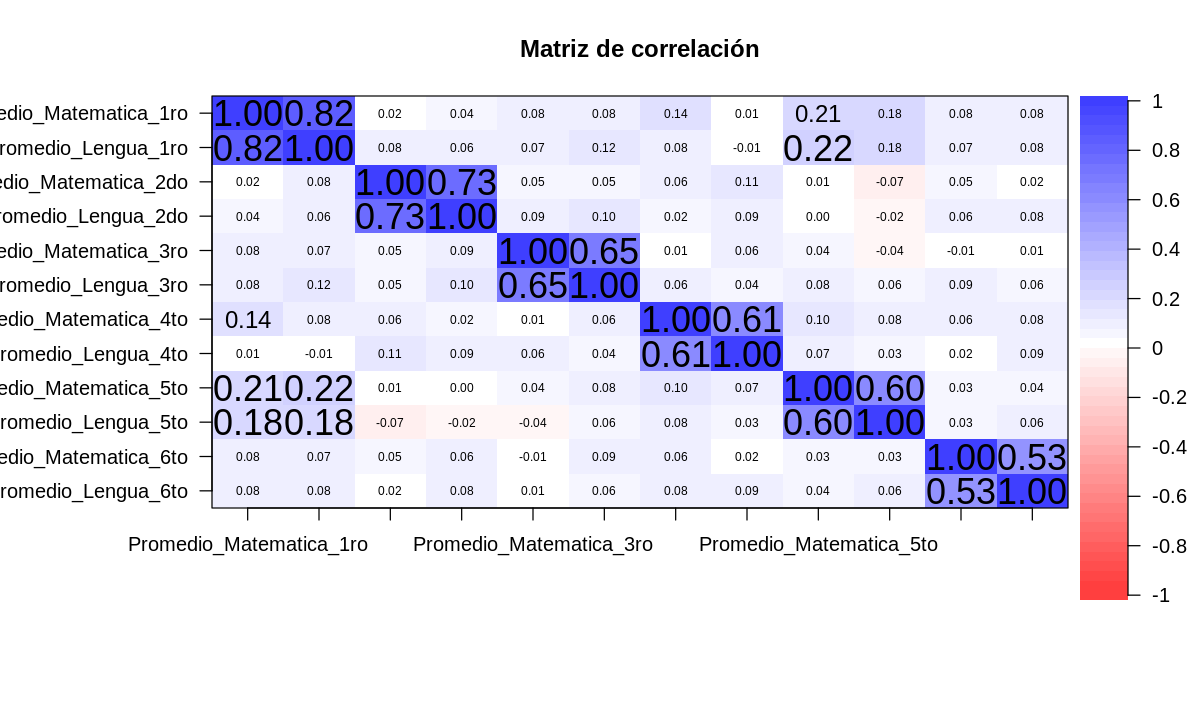

In [ ]:
install.packages("psych")
library(psych)

corPlot(datos_promedios_consolidados_truncado, cex = 1.2, main = "Matriz de correlación")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



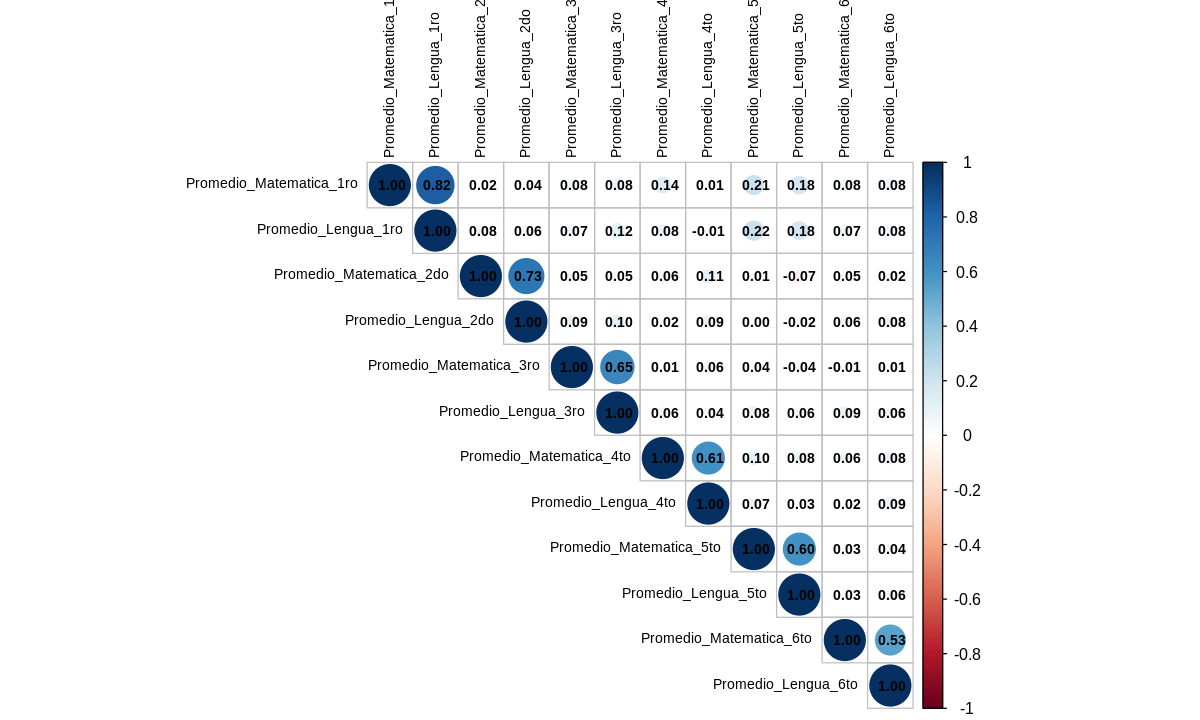

In [ ]:
install.packages("corrplot")
library(corrplot)

corrplot(cor(datos_promedios_consolidados_truncado),
               lower = "circle",
               upper = "circle",
               tl.col = "black",
               addCoef.col = "black",
               tl.pos = "td",
               tl.cex = 0.7,        # Considera reducir el tamaño de las etiquetas si se superponen
               number.cex = 0.7,     # Considera reducir el tamaño de los números si se superponen
               type = "upper")


In [ ]:
# Respondemos una pregunta respecto a la correlacion:

# Filtrar los datos para Matemática y Educación Física
datos_matematica <- datos_secundaria_comun %>% filter(Asignatura == "MATEMATICA")
datos_educacion_fisica <- datos_secundaria_comun %>% filter(Asignatura == "EDUCACION FISICA")

# Combinar los dataframes por la columna "Documento"
datos_combinados_mat_ef <- merge(datos_matematica, datos_educacion_fisica, by = "Documento")

# Calcular la correlación de Spearman
correlacion_mat_ef <- cor(datos_combinados_mat_ef$Promedio.x, datos_combinados_mat_ef$Promedio.y, method = "spearman")

# Imprimir el resultado
print(correlacion_mat_ef)

[1] 0.3444822


`geom_smooth()` using formula = 'y ~ x'


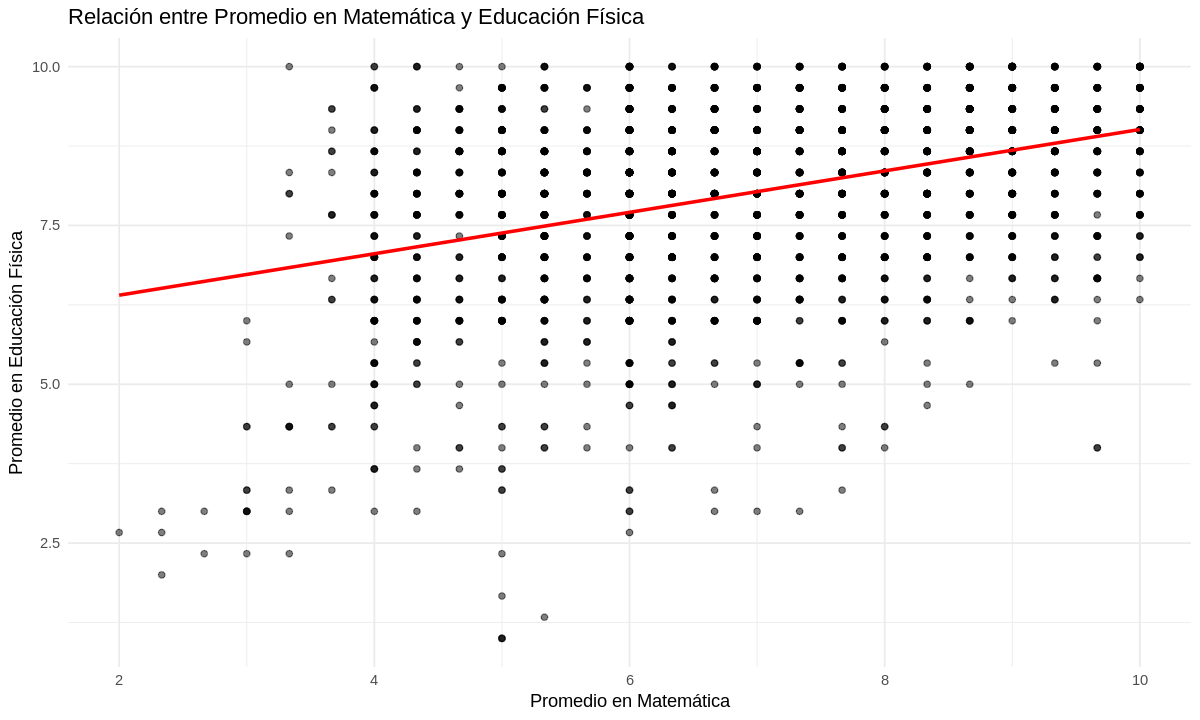

In [ ]:
# Instalar y cargar ggplot2 si aún no lo has hecho
if (!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

# Crear el gráfico de dispersión
ggplot(datos_combinados_mat_ef, aes(x = Promedio.x, y = Promedio.y)) +  # Promedio.x: Matemática, Promedio.y: Educación Física
  geom_point(alpha = 0.5) +  # Ajustar la transparencia de los puntos si es necesario
  labs(title = "Relación entre Promedio en Matemática y Educación Física",
       x = "Promedio en Matemática",
       y = "Promedio en Educación Física") +
  theme_minimal() +
  geom_smooth(method = "lm", se = FALSE, color = "red")  # Agregar una línea de tendencia (opcional)

In [ ]:
# ¿En qué materias piensa que puede ser apropiado al medir la correlación, y tener en cuenta el efecto de otras materias?
# ¿Se te ocurre otros contrastes que se podrían realizar? ¿Cuáles son posibles con los datos del dataset y cuáles no?

# Hacemos correlaciones entre las variables y los promedios

# Combinar divisiones en una nueva columna
datos_historia_1o <- datos_historia %>%
  filter(curso == "1ro Secundaria") %>%
  mutate(division_agrupada = "1er Año")

datos_historia_2o <- datos_historia %>%
  filter(curso == "2do Secundaria") %>%
  mutate(division_agrupada = "2do Año")

datos_historia_3o <- datos_historia %>%
  filter(curso == "3ro Secundaria") %>%
  mutate(division_agrupada = "3er Año")

datos_historia_4o <- datos_historia %>%
  filter(curso == "4to Secundaria") %>%
  mutate(division_agrupada = "4to Año")

datos_historia_5o <- datos_historia %>%
  filter(curso == "5to Secundaria") %>%
  mutate(division_agrupada = "5to Año")

datos_historia_6o <- datos_historia %>%
  filter(curso == "6to Secundaria") %>%
  mutate(division_agrupada = "6to Año")

datos_geografia_1o <- datos_geografia %>%
  filter(curso == "1ro Secundaria") %>%
  mutate(division_agrupada = "1er Año")

datos_geografia_2o <- datos_geografia %>%
  filter(curso == "2do Secundaria") %>%
  mutate(division_agrupada = "2do Año")

datos_geografia_3o <- datos_geografia %>%
  filter(curso == "3ro Secundaria") %>%
  mutate(division_agrupada = "3er Año")

datos_geografia_4o <- datos_geografia %>%
  filter(curso == "4to Secundaria") %>%
  mutate(division_agrupada = "4to Año")

datos_geografia_5o <- datos_geografia %>%
  filter(curso == "5to Secundaria") %>%
  mutate(division_agrupada = "5to Año")

datos_geografia_6o <- datos_geografia %>%
  filter(curso == "6to Secundaria") %>%
  mutate(division_agrupada = "6to Año")

# Fusionar para el 1er año
datos_combinados11 <- datos_matematicas_1o %>%
  full_join(datos_lengua_1o, by = "Documento") %>%
  full_join(datos_geografia_1o, by = "Documento") %>%
  full_join(datos_historia_1o, by = "Documento")

# Fusionar para el 2do año
datos_combinados22 <- datos_matematicas_2o %>%
  full_join(datos_lengua_2o, by = "Documento") %>%
  full_join(datos_geografia_2o, by = "Documento") %>%
  full_join(datos_historia_2o, by = "Documento")

# Fusionar para el 3er año
datos_combinados33 <- datos_matematicas_3o %>%
  full_join(datos_lengua_3o, by = "Documento") %>%
  full_join(datos_geografia_3o, by = "Documento") %>%
  full_join(datos_historia_3o, by = "Documento")

# Fusionar para el 4to año
datos_combinados44 <- datos_matematicas_4o %>%
  full_join(datos_lengua_4o, by = "Documento") %>%
  full_join(datos_geografia_4o, by = "Documento") %>%
  full_join(datos_historia_4o, by = "Documento")

# Fusionar para el 5to año
datos_combinados55 <- datos_matematicas_5o %>%
  full_join(datos_lengua_5o, by = "Documento") %>%
  full_join(datos_geografia_5o, by = "Documento") %>%
  full_join(datos_historia_5o, by = "Documento")

# Fusionar para el 6to año
datos_combinados66 <- datos_matematicas_6o %>%
  full_join(datos_lengua_6o, by = "Documento") %>%
  full_join(datos_geografia_6o, by = "Documento") %>%
  full_join(datos_historia_6o, by = "Documento")


In [ ]:
# Asegúrate de que tus dataframes combinados con 4 materias por año
# (datos_combinados11 a datos_combinados66) ya estén creados y disponibles.

# Lista de tus nuevos dataframes combinados (con 4 materias)
lista_dataframes_combinados_4mat <- list(
  datos_combinados11,
  datos_combinados22,
  datos_combinados33,
  datos_combinados44,
  datos_combinados55,
  datos_combinados66
)

# Obtener el número de filas de cada dataframe
num_filas_4mat <- sapply(lista_dataframes_combinados_4mat, nrow)

# Encontrar el número mínimo de filas entre estos dataframes
min_filas_4mat <- min(num_filas_4mat)

# Truncar cada dataframe para que tenga el número mínimo de filas
dataframes_4mat_truncados <- lapply(lista_dataframes_combinados_4mat, function(df) {
  # Seleccionar las primeras min_filas
  df_truncado <- df[1:min_filas_4mat, ]
  return(df_truncado)
})

# Opcional: Asignar los dataframes truncados de nuevo a variables individuales si lo necesitas
# datos_combinados11_truncado <- dataframes_4mat_truncados[[1]]
# datos_combinados22_truncado <- dataframes_4mat_truncados[[2]]
# ...

# --- Extraer las columnas de promedio de los dataframes truncados ---
# Identifica los nombres correctos de las columnas de promedio en tus dataframes combinados.
# Dado que fusionaste 4 dataframes, los nombres de las columnas de promedio
# probablemente tendrán sufijos como .x, .y, .x.x, .y.y, etc.
# Debes verificar los nombres exactos en uno de tus dataframes combinados, por ejemplo:
# colnames(datos_combinados11)

# Por ejemplo, si los nombres fueran (esto es un ejemplo, verifica los reales):
# "Promedio.x" (Matemática del 1er merge)
# "Promedio.y" (Lengua del 1er merge)
# "Promedio.x.x" (Geografía del 2do merge)
# "Promedio.y.y" (Historia del 2do merge)

# **IMPORTANTE:** Ajusta estos nombres de columnas según lo que veas en colnames(datos_combinadosXX)
columnas_promedios_11 <- dataframes_4mat_truncados[[1]][, c("Promedio.x", "Promedio.y", "Promedio.x.x", "Promedio.y.y")] # Ajusta los nombres reales
columnas_promedios_22 <- dataframes_4mat_truncados[[2]][, c("Promedio.x", "Promedio.y", "Promedio.x.x", "Promedio.y.y")] # Ajusta los nombres reales
columnas_promedios_33 <- dataframes_4mat_truncados[[3]][, c("Promedio.x", "Promedio.y", "Promedio.x.x", "Promedio.y.y")] # Ajusta los nombres reales
columnas_promedios_44 <- dataframes_4mat_truncados[[4]][, c("Promedio.x", "Promedio.y", "Promedio.x.x", "Promedio.y.y")] # Ajusta los nombres reales
columnas_promedios_55 <- dataframes_4mat_truncados[[5]][, c("Promedio.x", "Promedio.y", "Promedio.x.x", "Promedio.y.y")] # Ajusta los nombres reales
columnas_promedios_66 <- dataframes_4mat_truncados[[6]][, c("Promedio.x", "Promedio.y", "Promedio.x.x", "Promedio.y.y")] # Ajusta los nombres reales

# --- Combinar todas las columnas de promedios truncados en un nuevo dataframe consolidado ---
datos_promedios_consolidados_4mat_truncado <- cbind(
  columnas_promedios_11,
  columnas_promedios_22,
  columnas_promedios_33,
  columnas_promedios_44,
  columnas_promedios_55,
  columnas_promedios_66
)

# Opcional: Cambiar los nombres de las columnas para que sean más descriptivos
# Esto es crucial para entender qué columna corresponde a qué materia y año.
# Debes asignar 24 nombres de columnas (4 materias * 6 años).
colnames(datos_promedios_consolidados_4mat_truncado) <- c(
  "Mate_1ro", "Lengua_1ro", "Geo_1ro", "Historia_1ro",
  "Mate_2do", "Lengua_2do", "Geo_2do", "Historia_2do",
  "Mate_3ro", "Lengua_3ro", "Geo_3ro", "Historia_3ro",
  "Mate_4to", "Lengua_4to", "Geo_4to", "Historia_4to",
  "Mate_5to", "Lengua_5to", "Geo_5to", "Historia_5to",
  "Mate_6to", "Lengua_6to", "Geo_6to", "Historia_6to"
)


# Para ver las primeras filas del nuevo dataframe consolidado y truncado
head(datos_promedios_consolidados_4mat_truncado)

# Para ver el número de filas del resultado
nrow(datos_promedios_consolidados_4mat_truncado)

# Para ver la estructura y los nombres de las columnas
#str(datos_promedios_consolidados_4mat_truncado)

,Mate_1ro,Lengua_1ro,Geo_1ro,Historia_1ro,Mate_2do,Lengua_2do,Geo_2do,Historia_2do,Mate_3ro,Lengua_3ro,⋯,Geo_4to,Historia_4to,Mate_5to,Lengua_5to,Geo_5to,Historia_5to,Mate_6to,Lengua_6to,Geo_6to,Historia_6to
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,9.666667,9.333333,7.666667,8.000000,3.000000,2.333333,2.333333,3.333333,5.000000,6.000000,⋯,7.333333,5.666667,6.333333,8.000000,8.666667,7.666667,6.000000,6.666667,7.666667,6.000000
2,10.000000,9.666667,8.666667,8.666667,3.333333,2.666667,4.333333,2.666667,5.666667,6.000000,⋯,7.000000,6.000000,4.000000,3.666667,4.333333,3.666667,8.000000,7.333333,8.333333,7.000000
3,9.333333,9.000000,7.666667,8.000000,10.000000,8.000000,8.666667,7.333333,5.000000,6.000000,⋯,6.333333,4.666667,9.000000,7.666667,9.000000,7.666667,6.000000,6.000000,6.000000,6.000000
4,10.000000,9.666667,8.000000,9.000000,4.000000,3.000000,3.000000,3.000000,6.000000,6.000000,⋯,5.666667,4.666667,9.000000,7.666667,8.333333,7.666667,6.666667,6.333333,9.000000,6.000000
5,7.666667,8.000000,5.666667,7.000000,8.000000,7.000000,9.000000,7.333333,7.333333,8.000000,⋯,6.000000,5.666667,7.666667,8.000000,7.000000,6.333333,6.000000,6.666667,8.666667,6.333333
6,8.333333,9.333333,7.666667,9.000000,3.333333,3.000000,2.666667,2.333333,8.666667,8.333333,⋯,6.000000,6.000000,9.333333,8.000000,6.666667,6.333333,6.000000,5.000000,7.000000,6.000000


[1] 409

In [ ]:
install.packages("ppcor")
library(ppcor)

# Asegúrate de que tu dataframe datos_promedios_consolidados_4mat_truncado esté disponible

# 1. Definir las variables X, Y y Z
X <- datos_promedios_consolidados_4mat_truncado$Mate_1ro
Y <- datos_promedios_consolidados_4mat_truncado$Mate_6to
Z <- datos_promedios_consolidados_4mat_truncado$Lengua_1ro

# Crear un dataframe temporal con solo las variables de interés para manejar NA juntos
temp_data <- data.frame(X, Y, Z)

# Eliminar filas con NA en cualquiera de estas tres variables
temp_data_cleaned <- na.omit(temp_data)

# Si después de na.omit no quedan datos, el resultado seguirá siendo NA o un error.
if (nrow(temp_data_cleaned) == 0) {
  print("No hay observaciones completas después de eliminar los NA. No se puede calcular la correlación.")
} else {
  # Extraer las variables limpias
  X_clean <- temp_data_cleaned$X
  Y_clean <- temp_data_cleaned$Y
  Z_clean <- temp_data_cleaned$Z

  # 2. Calcular las correlaciones de Pearson simple en los datos limpios
  correlacion_xy <- cor(X_clean, Y_clean, method = "pearson")
  correlacion_xz <- cor(X_clean, Z_clean, method = "pearson")
  correlacion_yz <- cor(Y_clean, Z_clean, method = "pearson")

  # 3. Calcular la correlación parcial
  # Es importante verificar que los denominadores no se hagan cero si hay correlaciones muy altas
  denominador <- sqrt((1 - correlacion_xz^2) * (1 - correlacion_yz^2))

  if (denominador == 0) {
    print("El denominador de la correlación parcial es cero. Posiblemente, la correlación entre X y Z, o Y y Z, es perfectamente lineal (1 o -1), lo que impide el cálculo parcial.")
  } else {
    correlacion_xy_parcialz <- (correlacion_xy - correlacion_xz * correlacion_yz) / denominador

    print("La correlación entre el promedio de Matemáticas de 1er grado y Matemáticas de 6to grado, neutralizando el promedio de Lengua de 1er grado, es:")
    print(round(correlacion_xy_parcialz, 2))
  }
}

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "La correlación entre el promedio de Matemáticas de 1er grado y Matemáticas de 6to grado, neutralizando el promedio de Lengua de 1er grado, es:"
[1] -0.08


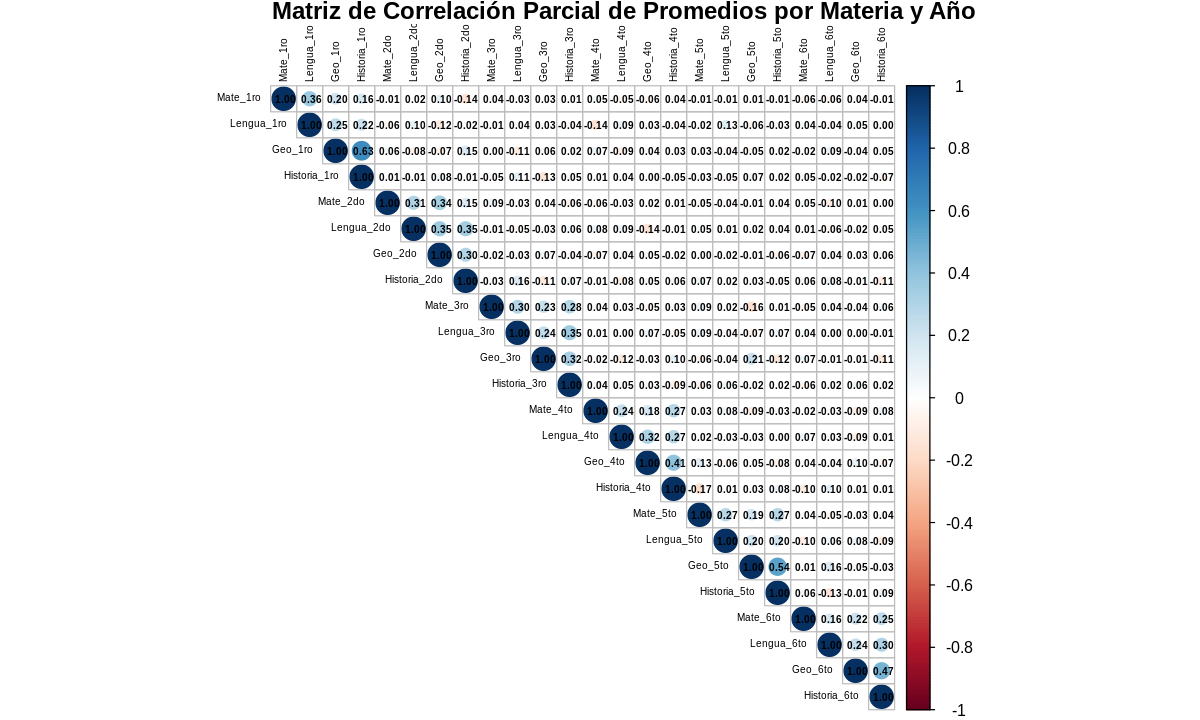

In [ ]:
# Instalar el paquete ppcor si no lo tienes (solo una vez)
# install.packages("ppcor")
# install.packages("corrplot") # Instalar corrplot si no lo tienes

library(ppcor)
library(corrplot)

# --- Preparación de los datos ---
# Asegúrate de que 'datos_promedios_consolidados_4mat_truncado' esté cargado y sea accesible.
# Es fundamental que no haya NAs en las columnas que vas a usar,
# o que los manejes previamente. La función pcor() de ppcor por defecto
# usará "pairwise.complete.obs" o "complete.obs" dependiendo de cómo se le pase el data.frame.
# Para asegurar que corrplot funcione bien, es mejor limpiarlos antes si es posible.

# Opcional: Eliminar filas con NA en cualquier columna antes de calcular la matriz de correlación parcial
# Esto es una buena práctica para asegurar que el cálculo se hace sobre el mismo conjunto de datos
# para todas las correlaciones, y evita posibles NAs en la matriz resultante.
datos_limpios <- na.omit(datos_promedios_consolidados_4mat_truncado)

# --- Calcular la matriz de correlación parcial ---
# La función pcor() del paquete ppcor calcula la matriz de correlación parcial.
# Por defecto, controla todas las demás variables en el dataframe.
# El resultado es un objeto que contiene la matriz de correlaciones parciales (y p-values).

# Si quieres que controle TODAS las otras variables:
matriz_cor_parcial <- pcor(datos_limpios, method = "pearson")$estimate

# Si solo quieres controlar un subconjunto específico de variables, la cosa se complica un poco
# porque pcor() no tiene un argumento 'control'. Para eso, tendrías que calcular
# cada correlación parcial de dos variables, controlando la(s) misma(s) tercera(s) variable(s)
# y luego ensamblar manualmente la matriz.
# Para el propósito de un corrplot, generalmente se usa la correlación parcial de todas con todas,
# controlando todas las demás.

# --- Visualizar la matriz de correlación parcial con corrplot ---
# Puedes usar los mismos argumentos que usaste para la correlación regular.
# Sin embargo, con 24 columnas, es probable que las etiquetas y números se superpongan.
# Ajusta 'tl.cex' y 'number.cex' para que sea legible.

corrplot(matriz_cor_parcial,
         lower = "circle",       # Puedes usar "number", "square", etc.
         upper = "circle",       # Puedes usar "number", "square", etc.
         tl.col = "black",       # Color de las etiquetas (nombres de las variables)
         addCoef.col = "black",  # Color de los coeficientes de correlación
         tl.pos = "td",          # Posición de las etiquetas (top-diagonal)
         tl.cex = 0.5,           # Tamaño de las etiquetas (¡muy importante para 24 columnas!)
         number.cex = 0.5,       # Tamaño de los números de correlación
         type = "upper",         # Mostrar solo la parte superior de la matriz
         diag = TRUE,            # Mostrar la diagonal (correlación de una variable consigo misma, que será 1)
         # addrect = 2,           # Opcional: añade rectángulos para agrupar variables
         # order = "hclust"       # Opcional: reordena las variables por clusterización
         # col = COL2("RdBu", 20) # Opcional: esquema de colores
         mar = c(0,0,1,0)        # Ajusta los márgenes para que las etiquetas quepan
)

# Puedes añadir un título para mayor claridad
title("Matriz de Correlación Parcial de Promedios por Materia y Año", line = 3.3)